# Computation of the best model for the question

## Stats

We choose to compute the mean of the rating, taking out the grade 2, 4 and 7 that are link to specific case.

2, 4, 7 are compute indepently with graph

## How did we proceed

First, we count all the annotation mark we put in the files.

Second we compute the mean of those annotation, removing the score 2, 4, 7 from the calculus.

Third we order the result, and pick the one with the highest mean.

Other ideas, completion:

Take into account the number of empty question

take into account the number of 2, 4, 7

In [117]:
import pandas as pd 
import matplotlib.pyplot as plt
import os

# Files paths

Need to change it if you want to run the code of the notebook

In [118]:
MD = "Mario/deepseek"
MG = "Mario/gemma"
ML = "Mario/llama"
MM = "Mario/mistral"
MN = "Mario/nemotron"
MQ = "Mario/qwen"

chemin_M = [MD, MG, ML, MM, MN, MQ]

AD = "Axel/deepseek"
AG = "Axel/gemma"
AL = "Axel/llama"
AM = "Axel/mistral"
AN = "Axel/nemotron"
AQ = "Axel/qwen"

chemin_A = [AD, AG, AL, AM, AN, AQ]

HD = "Hao/deepseek"
HG = "Hao/gemma"
HL = "Hao/llama"
HM = "Hao/mistral"
HN = "Hao/nemotron"
HQ = "Hao/qwen"

chemin_H = [HD, HG, HL, HM, HN, HQ]

file_path_mario = [os.path.join(chemin, element) for chemin in chemin_M for element in os.listdir(chemin)]
file_path_axel = [os.path.join(chemin, element) for chemin in chemin_A for element in os.listdir(chemin)]
file_path_hao = [os.path.join(chemin, element) for chemin in chemin_H for element in os.listdir(chemin)]

file_path_axel.sort()
file_path_mario.sort()
file_path_hao.sort()

# Functions for the computation

In [119]:
def count_annotations(file_path, annotator):
    dict_count = {}
    rating = [0, 1, 2, 3, 4, 5, 6, 7, 8]
    df = pd.read_csv(file_path)
    for value in df["rating"].dropna():
        if value in dict_count:
            dict_count[value] += 1
        else:
            dict_count[value] = 1
    for i in range (0, 9, 1):
        if i not in dict_count:
            dict_count[float(i)] = 0
    dict_count = {clef: dict_count[clef] for clef in rating}
    return annotator, dict_count

def bar_plot_function(x, y, xlabel, ylabel, title):
    fig, ax = plt.subplots()
    ax.bar(x, y, width=1, edgecolor="white", linewidth=0.7)
    ax.set(ylim=(0, max(y)+1), xlabel=xlabel, ylabel=ylabel, title=title)
    ax.tick_params(axis='x')
    plt.grid()
    plt.show()

def count_empty_ratings(file_path):
    df = pd.read_csv(file_path)
    i = 0
    for rate, comment in zip(df["rating"], df["comment"]):
        if pd.isna(rate):
            if comment == comment:
                i+=1
    return i

def rank_model(liste):
    rank_model = []
    for mean, file in liste:
        if "qwen" in file:
            rank_model.append(("qwen"))
        elif "nemotron" in file:
            rank_model.append(("nemotron"))
        elif "mistral" in file:
            rank_model.append(("mistral"))
        elif "llama" in file:
            rank_model.append(("llama"))
        elif "gemma" in file:
            rank_model.append(("gemma"))
        elif "deepseek" in file:
            rank_model.append(("deepseek"))
    return rank_model
  
#Function to check the 10 first model base on the rank.
def score_model(liste):
    score = {}
    for i in range(0, 10, 1):
        if liste[i] in score:
            score[liste[i]] += 1
        else:
            score[liste[i]] = 1
    return score


# Mean Score

In [120]:
result_a = []
result_m = []
result_h = []
for file_a, file_m, file_h, in zip(file_path_axel, file_path_mario, file_path_hao):
    annotator_a, count_a = count_annotations(file_a, "Axel")
    del count_a[2]
    del count_a[4]
    del count_a[7]
    mean_a = sum([key*value for key, value in count_a.items()])/sum(count_a.values())
    print(f"Mean for Axel: {mean_a:.2f}, for file: {file_a}")

    annotator_m, count_m = count_annotations(file_m, "Mario")
    del count_m[2]
    del count_m[4]
    del count_m[7]
    mean_m = sum([key*value for key, value in count_m.items()])/sum(count_m.values())
    print(f"Mean for Mario: {mean_m:.2f}, for file: {file_m}")

    annotator_h, count_h = count_annotations(file_h, "Hao")
    del count_h[2]
    del count_h[4]
    del count_h[7]
    mean_h = sum([key*value for key, value in count_h.items()])/sum(count_h.values())
    print(f"Mean for Hao: {mean_h:.2f}, for file: {file_h}")
    result_a.append((mean_a, file_a))
    result_m.append((mean_m, file_m))
    result_h.append((mean_h, file_h))

Mean for Axel: 0.96, for file: Axel/deepseek/sheet_10_annotations_FELTEN.csv
Mean for Mario: 2.17, for file: Mario/deepseek/sheet_10_annotations_JAKIMOSKI.csv
Mean for Hao: 3.97, for file: Hao/deepseek/sheet_10_annotations_Hao_Deepseek.csv
Mean for Axel: 2.00, for file: Axel/deepseek/sheet_13_annotations_FELTEN.csv
Mean for Mario: 2.58, for file: Mario/deepseek/sheet_13_annotations_JAKIMOSKI.csv
Mean for Hao: 3.53, for file: Hao/deepseek/sheet_13_annotations_Hao_Deepseek.csv
Mean for Axel: 4.10, for file: Axel/deepseek/sheet_19_annotations_FELTEN.csv
Mean for Mario: 3.64, for file: Mario/deepseek/sheet_19_annotations_JAKIMOSKI.csv
Mean for Hao: 3.97, for file: Hao/deepseek/sheet_19_annotations_Hao_Deepseek.csv
Mean for Axel: 5.53, for file: Axel/deepseek/sheet_30_annotations_FELTEN.csv
Mean for Mario: 3.10, for file: Mario/deepseek/sheet_30_annotations_JAKIMOSKI.csv
Mean for Hao: 4.38, for file: Hao/deepseek/sheet_30_annotations_Hao_Deepseek.csv
Mean for Axel: 3.54, for file: Axel/deep

# Conclusion

Number of models apparition, for each member of the project, for the 10 first models.

In [121]:
result_a.sort(reverse=True)
result_m.sort(reverse=True)
result_h.sort(reverse=True)

#Order the result by the mean, start from the top model to the worst one, 
# and then check the 10 first model for each annotator to see which model is the best.

rank_model_a = rank_model(result_a)
rank_model_m = rank_model(result_m)
rank_model_h = rank_model(result_h)

score_a = score_model(rank_model_a)
score_m = score_model(rank_model_m)
score_h = score_model(rank_model_h)

print("Top models for Axel:", score_a)
print("Top models for Mario:", score_m)
print("Top models for Hao:", score_h)

Top models for Axel: {'qwen': 4, 'mistral': 4, 'gemma': 1, 'nemotron': 1}
Top models for Mario: {'mistral': 4, 'qwen': 3, 'gemma': 2, 'nemotron': 1}
Top models for Hao: {'mistral': 4, 'gemma': 4, 'qwen': 2}


# Check the empty questions for each files
Then, we write the result in a CSV file.

In [122]:
with open('empty_ratings.csv', 'w') as f:
    f.write("Annotator,File,Empty_Ratings\n")
    for files_a in file_path_axel:
        empty_ratings = count_empty_ratings(files_a)
        f.write(f"Axel,{files_a},{empty_ratings}\n")

    for files_m in file_path_mario:
        empty_ratings = count_empty_ratings(files_m)
        f.write(f"Mario,{files_m},{empty_ratings}\n")

    for files_h in file_path_hao:
        empty_ratings = count_empty_ratings(files_h)
        f.write(f"Hao,{files_h},{empty_ratings}\n")

# Check the number of 2, 4 and 7 for each files

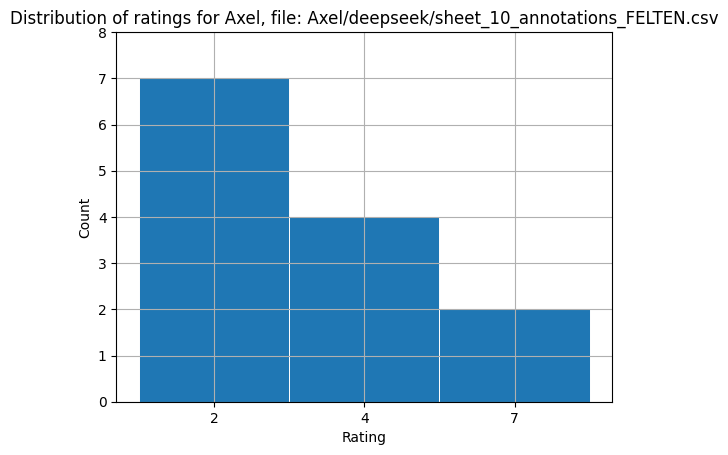

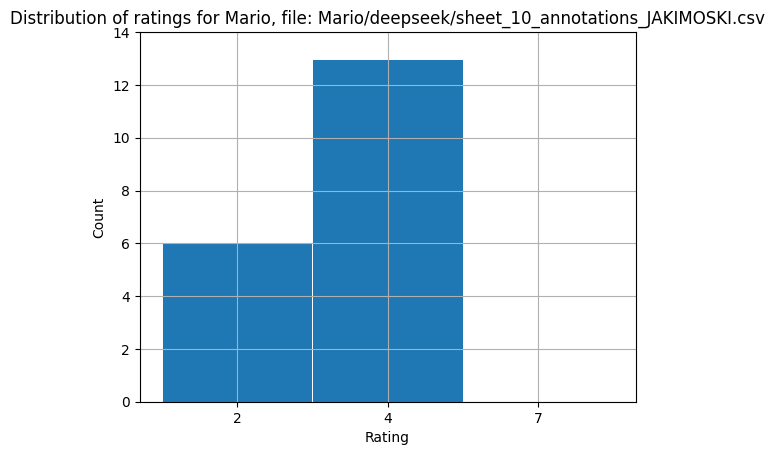

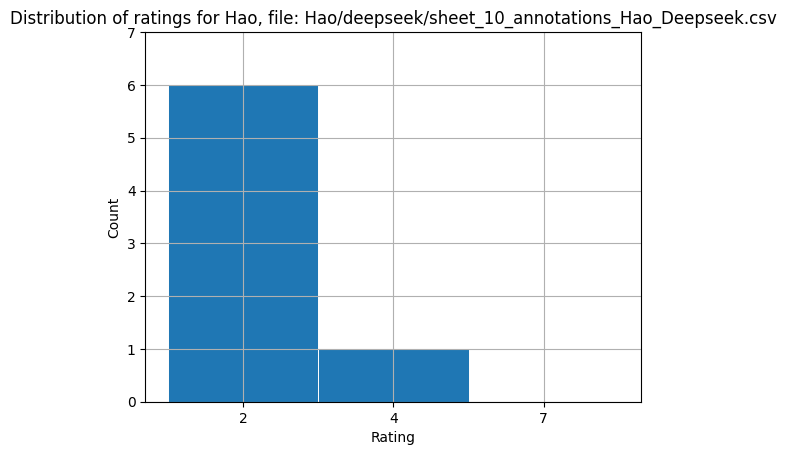

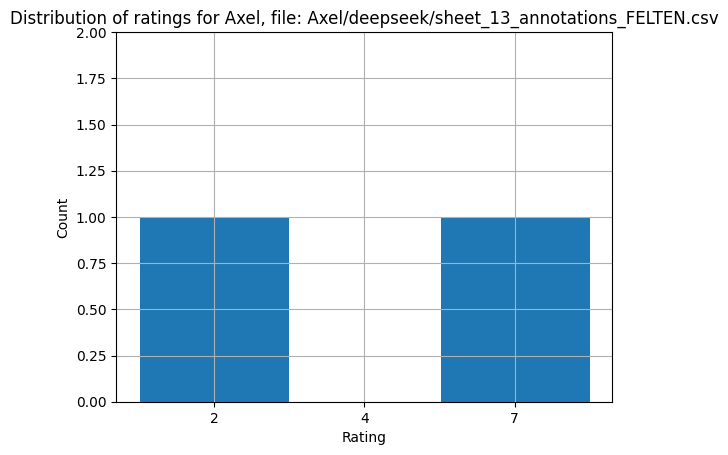

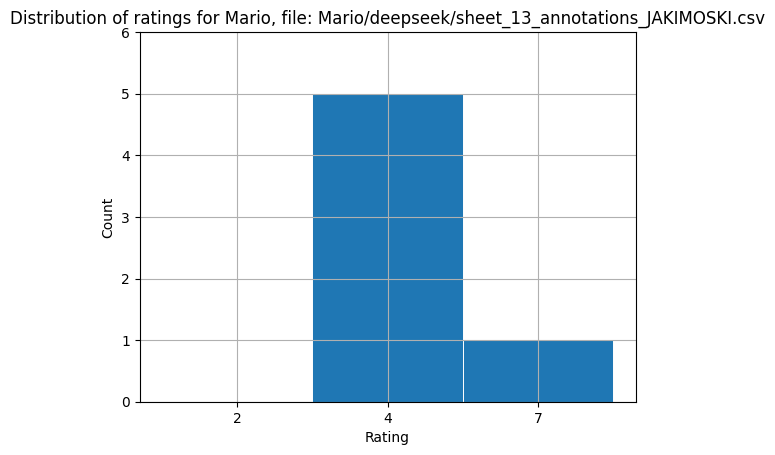

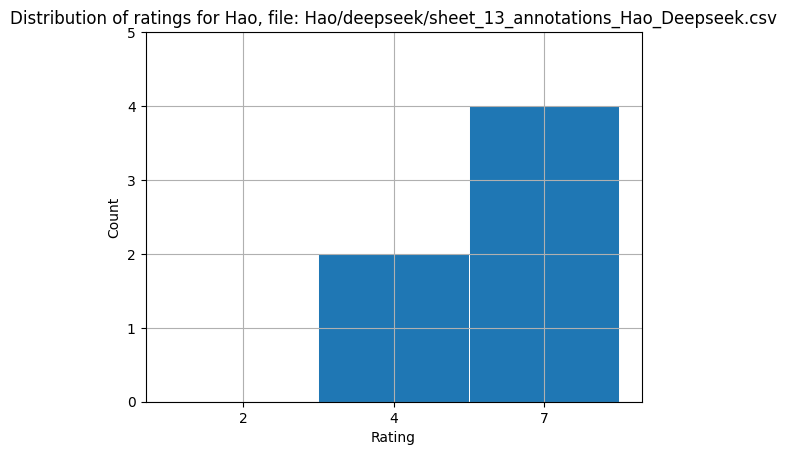

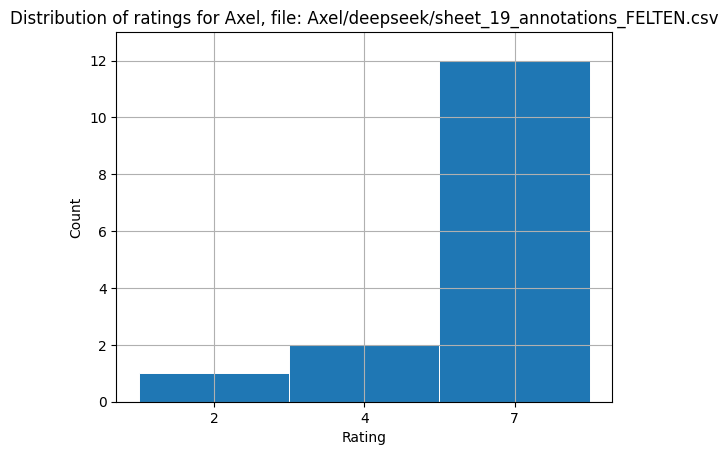

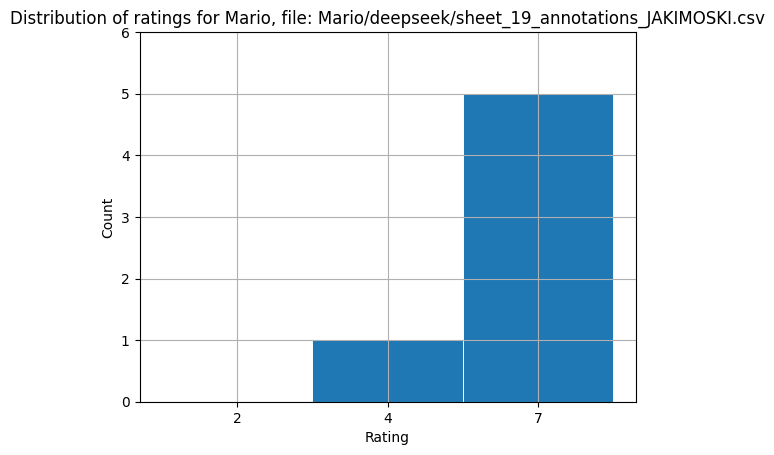

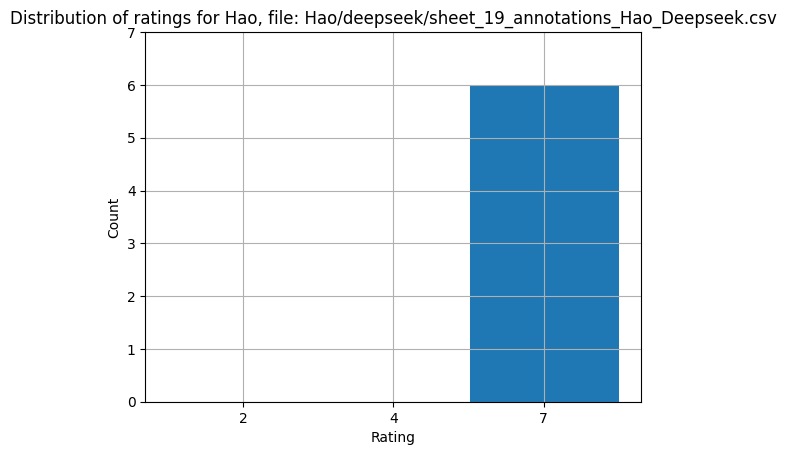

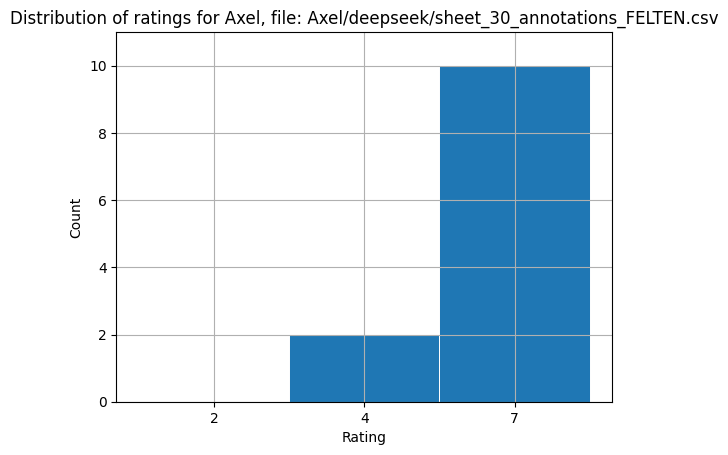

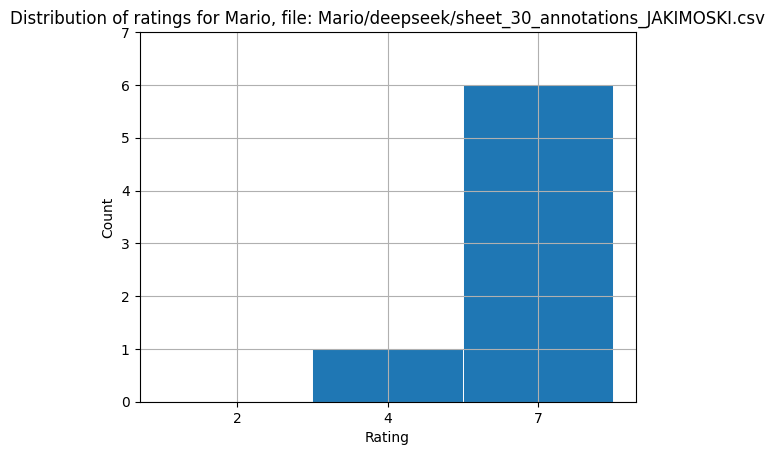

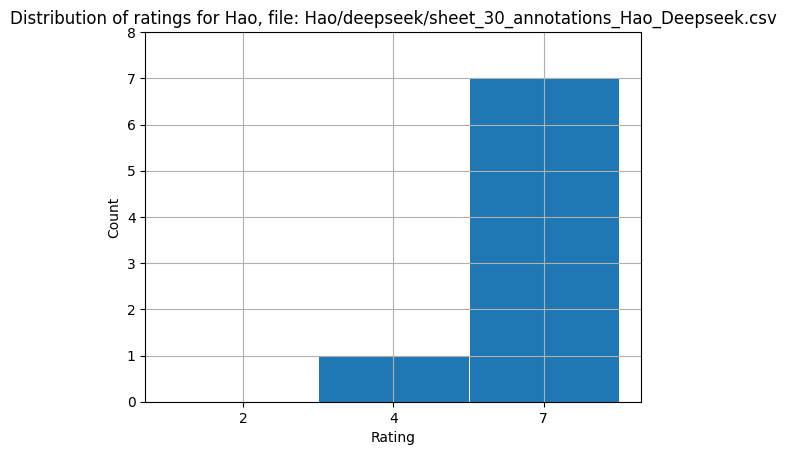

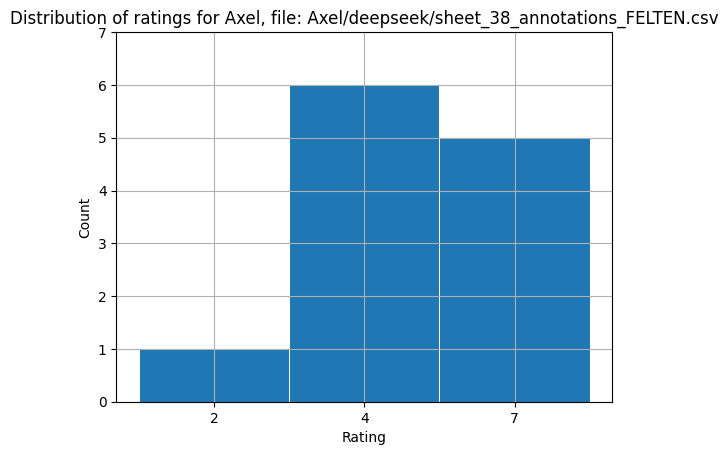

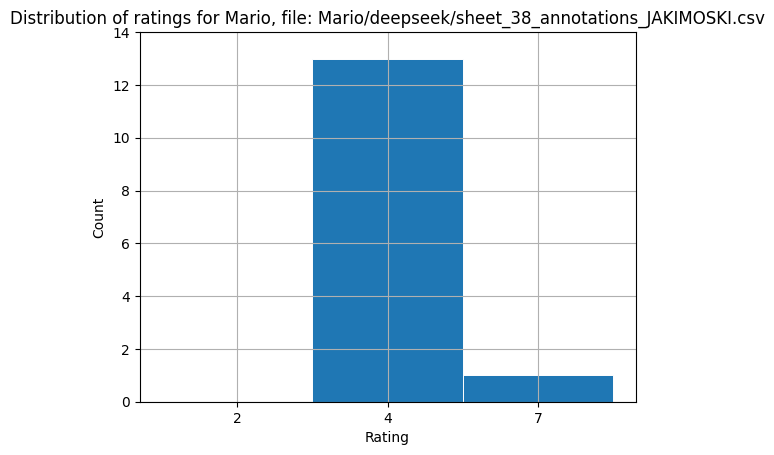

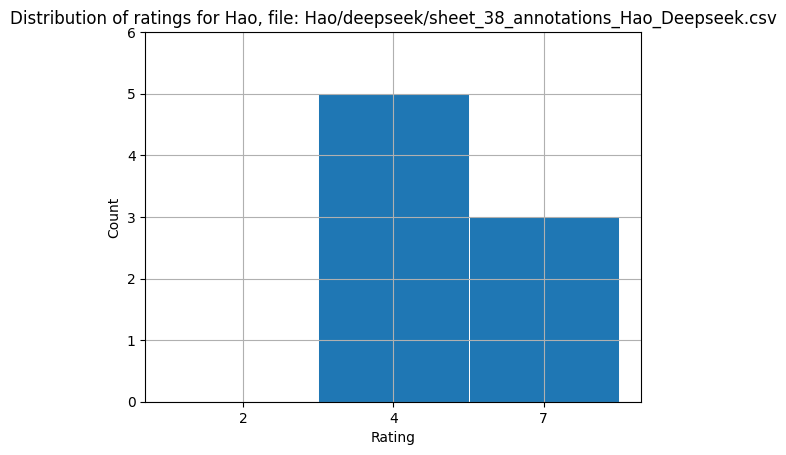

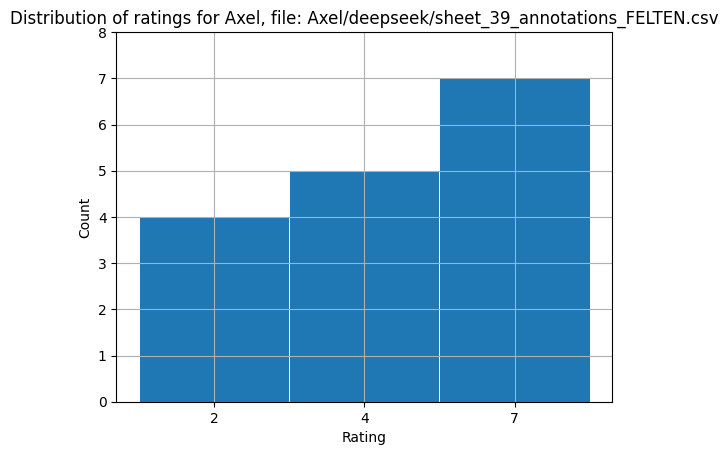

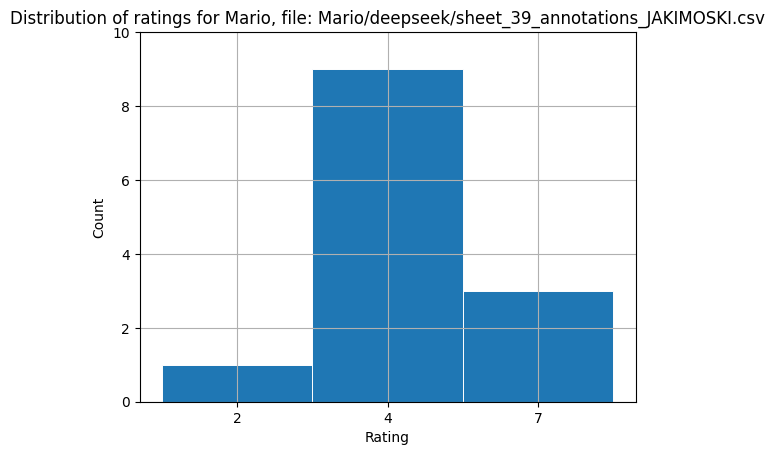

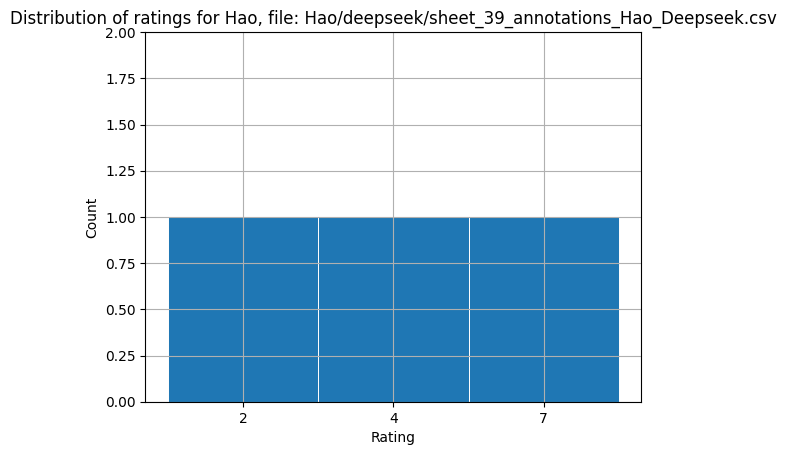

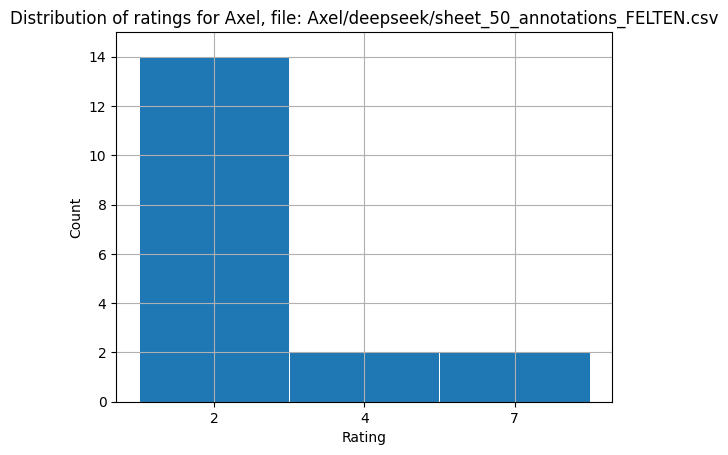

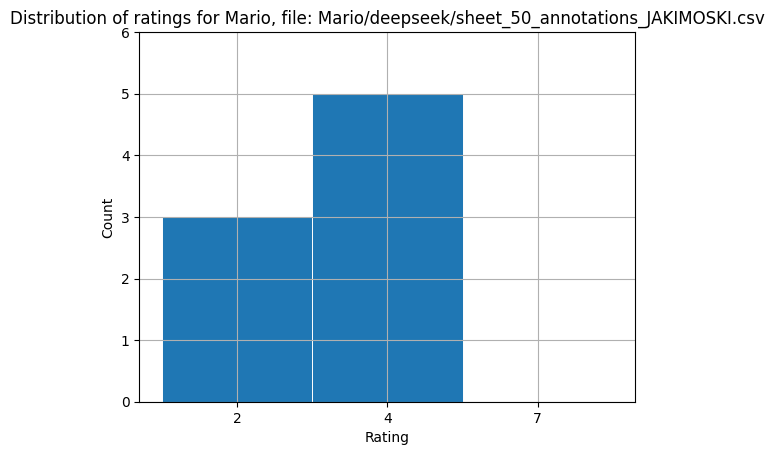

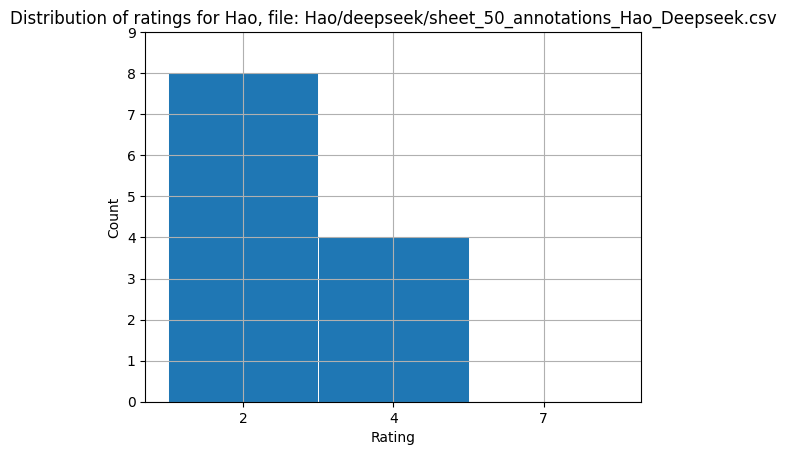

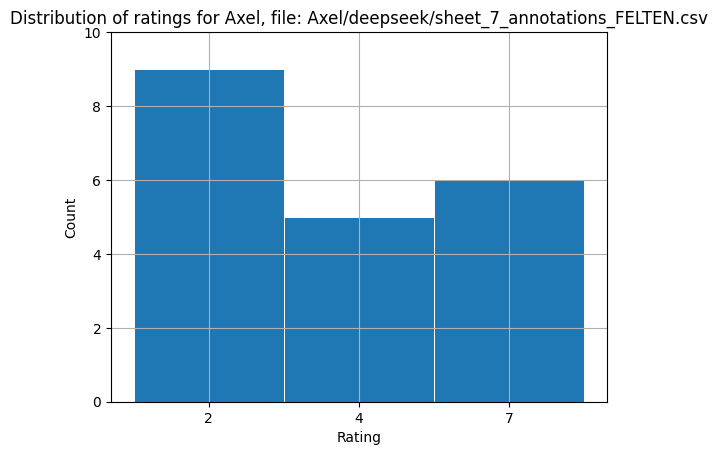

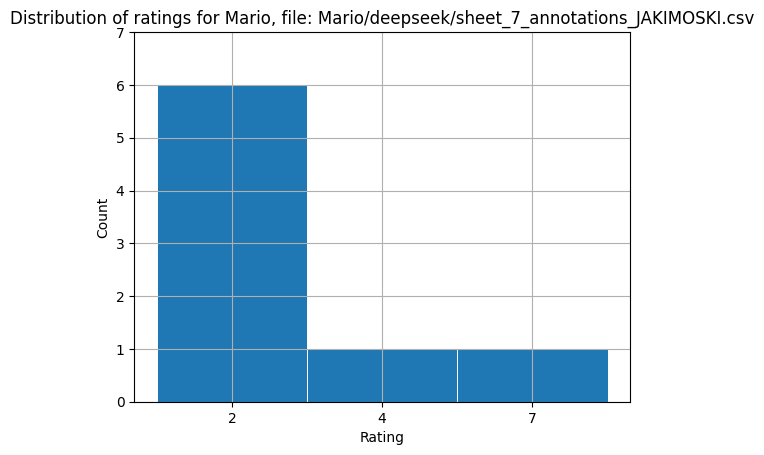

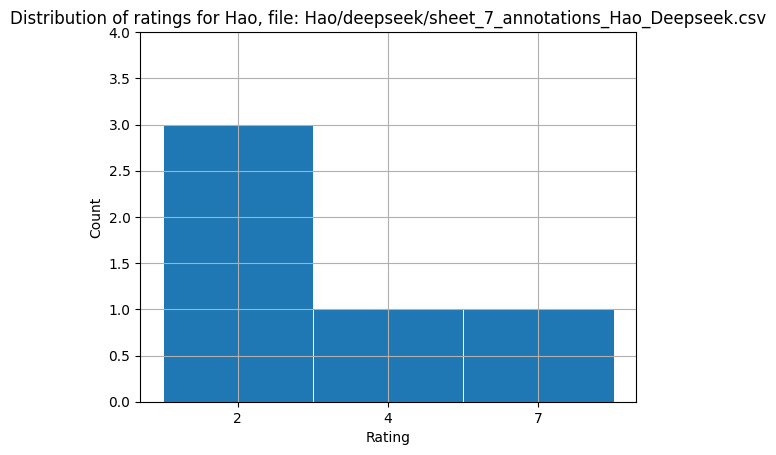

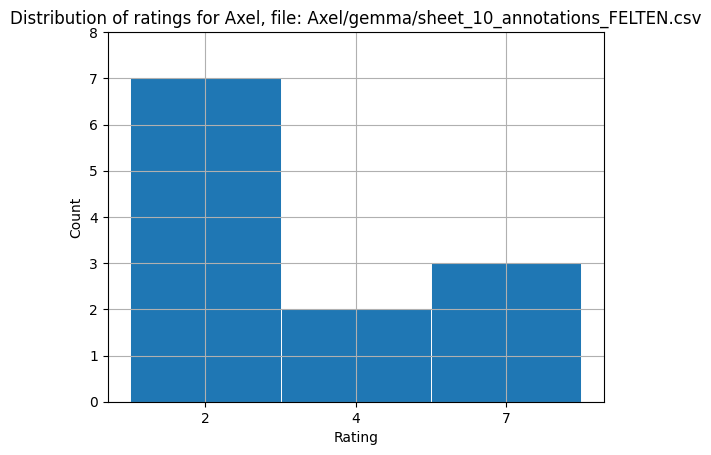

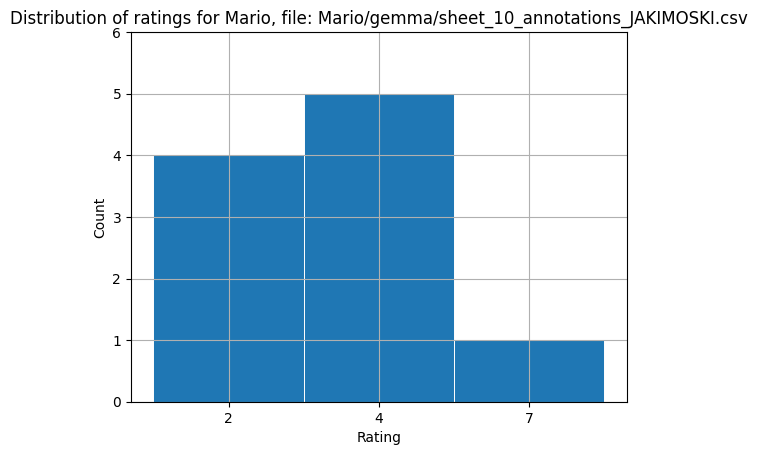

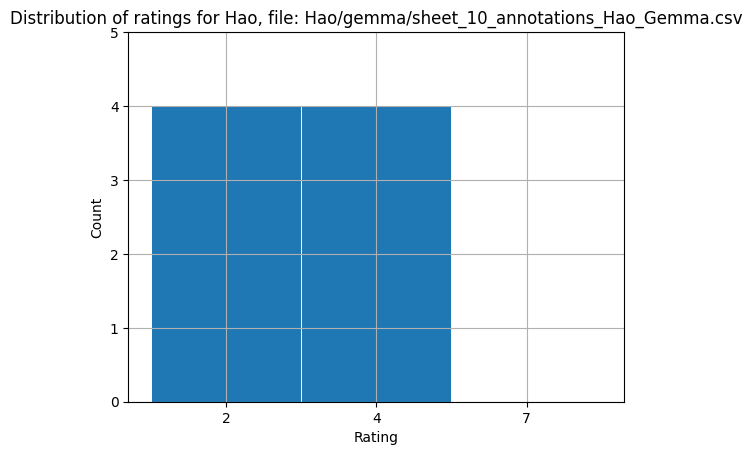

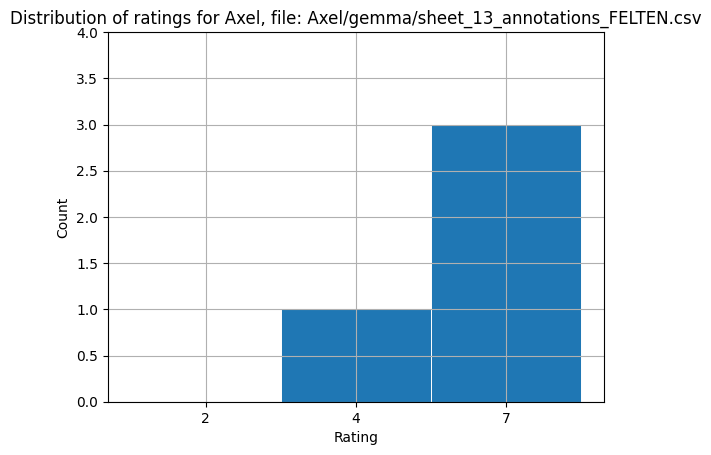

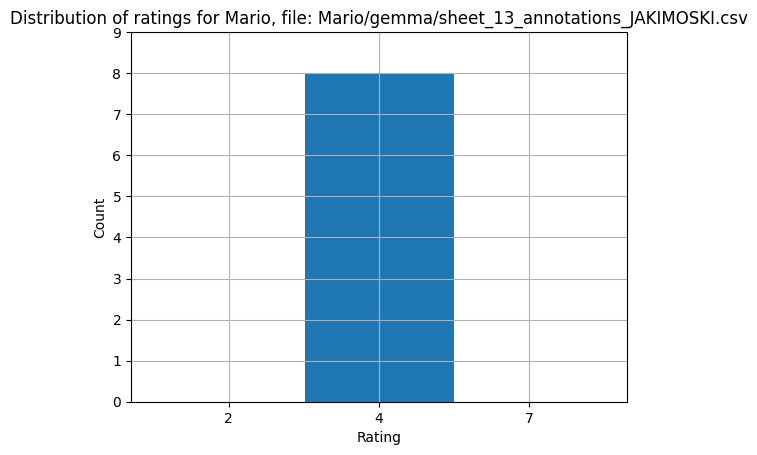

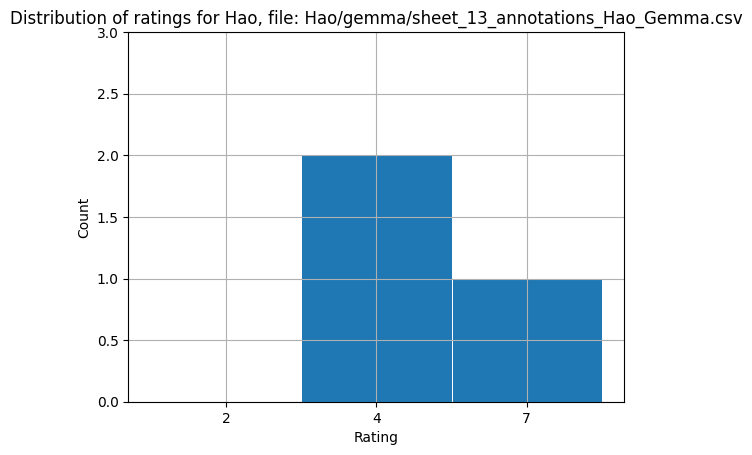

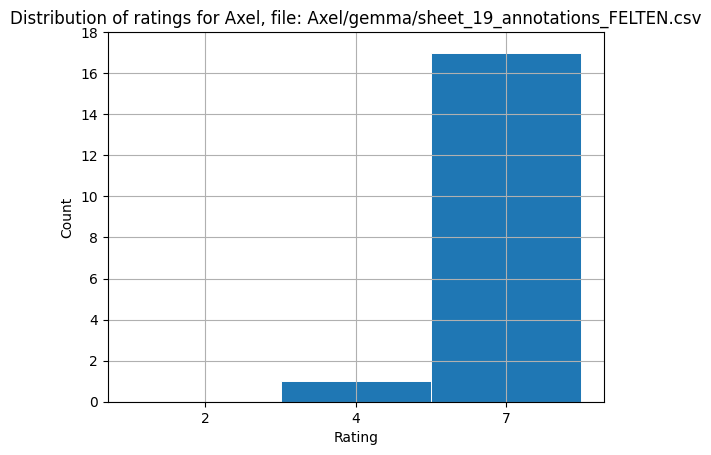

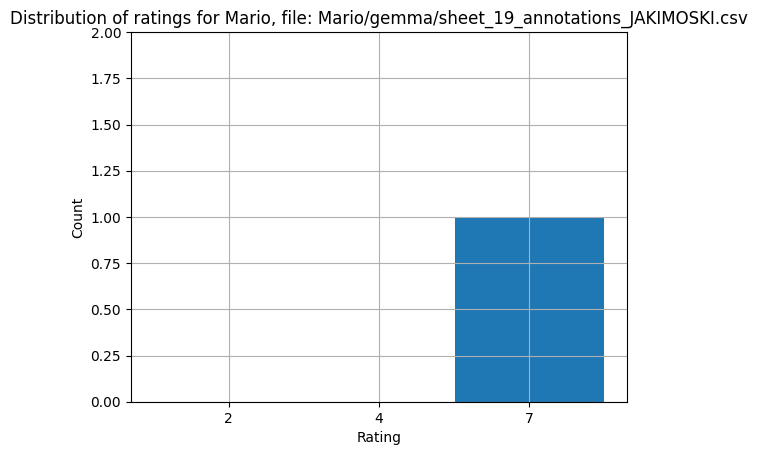

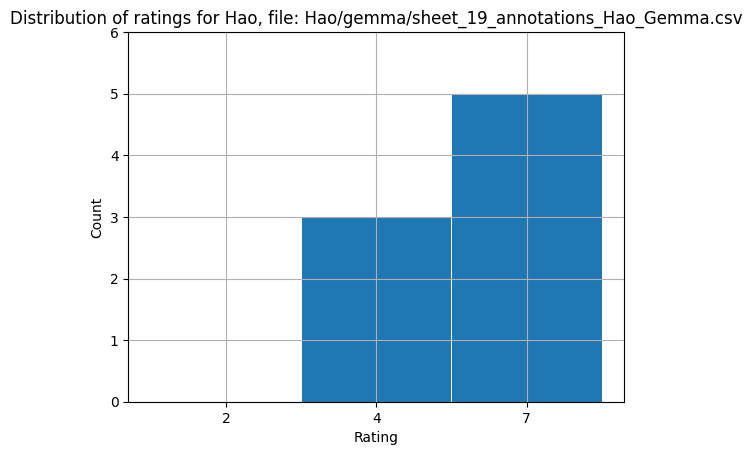

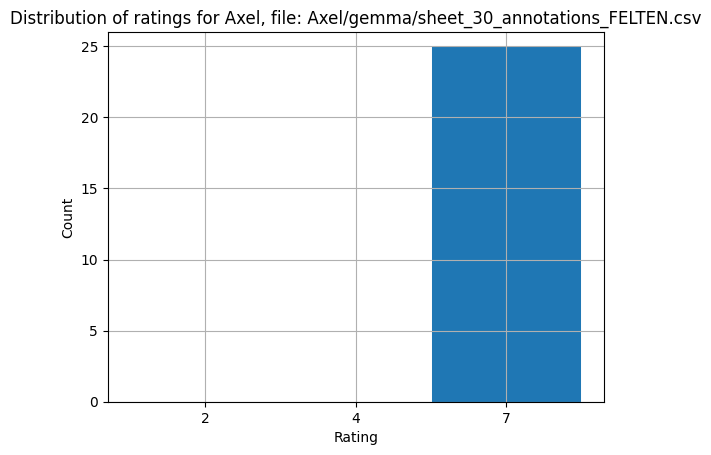

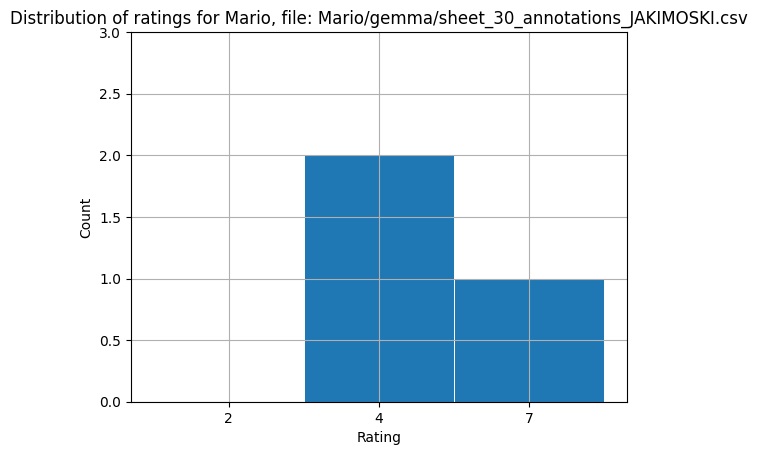

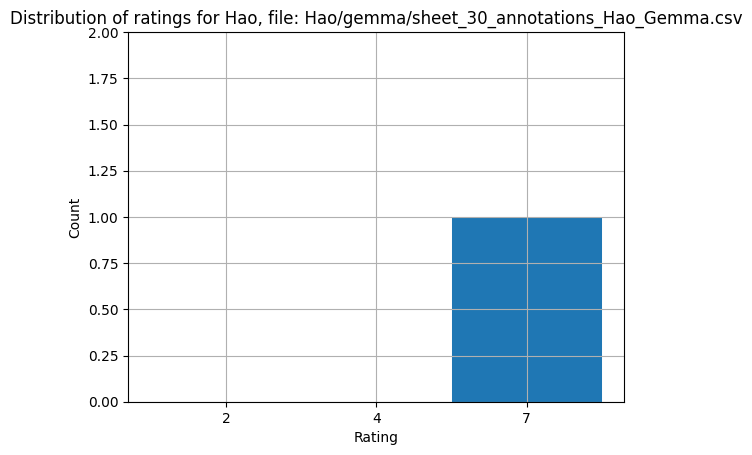

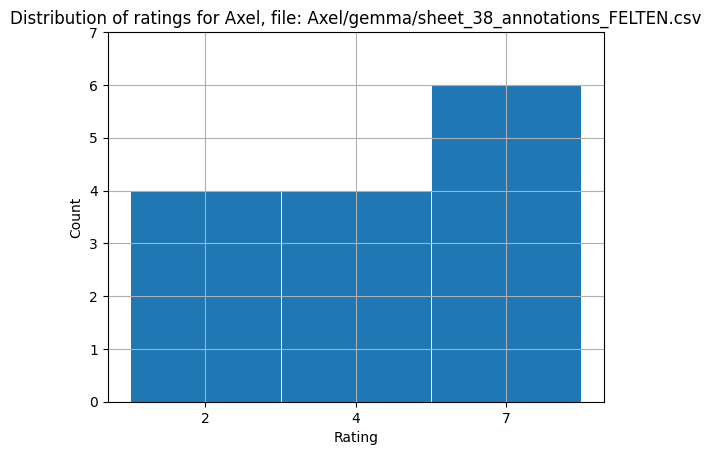

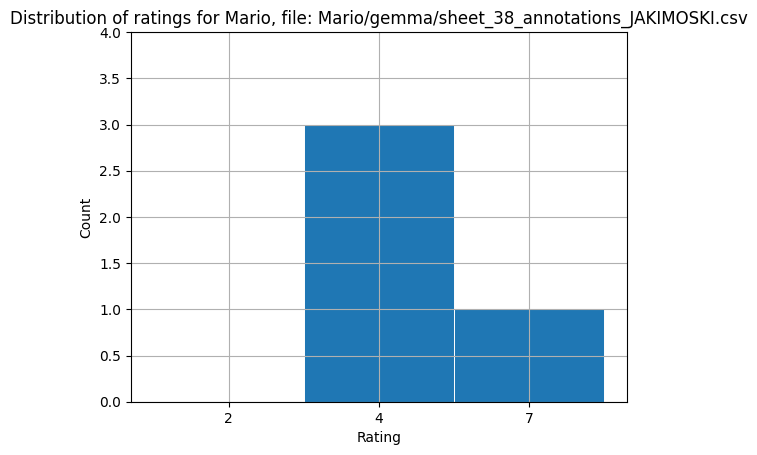

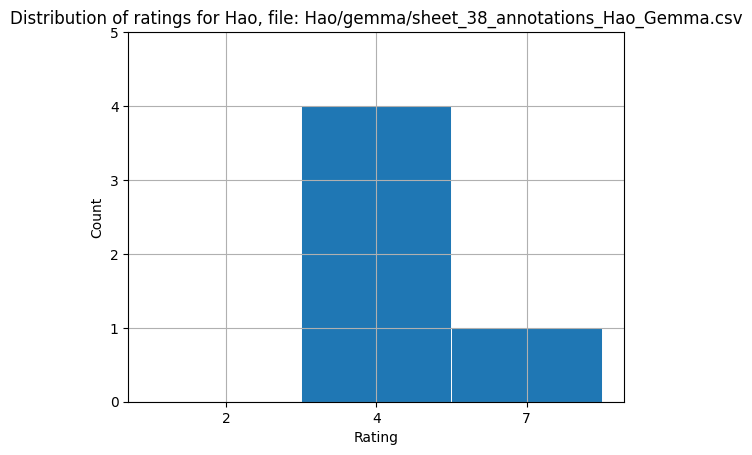

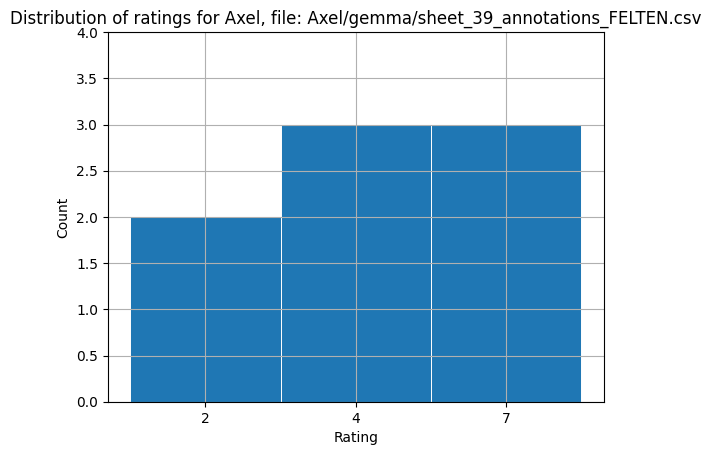

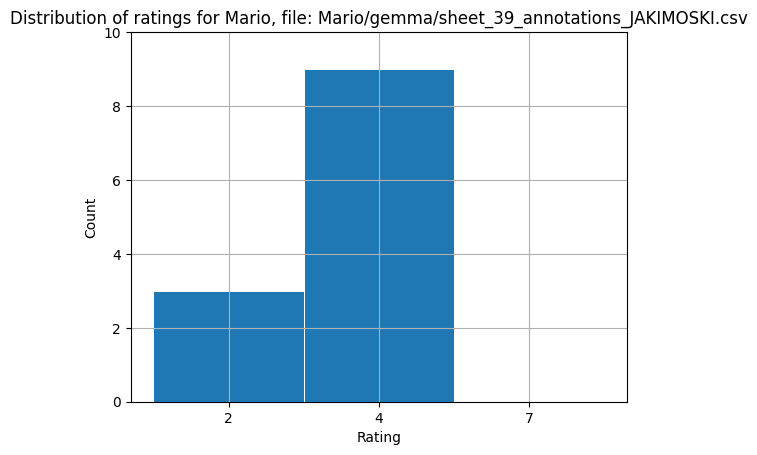

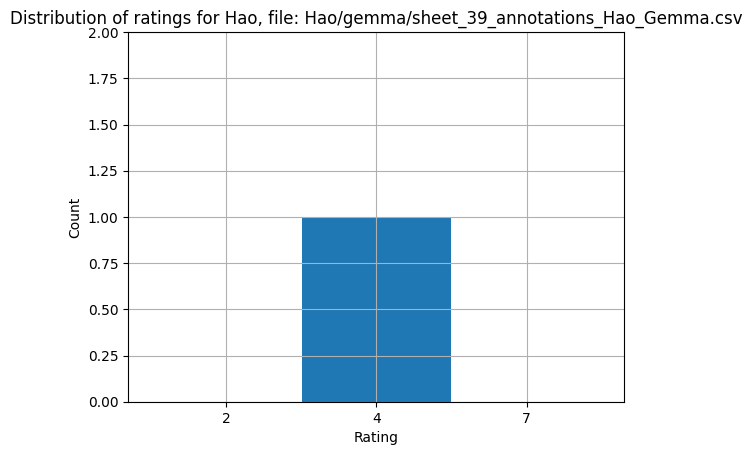

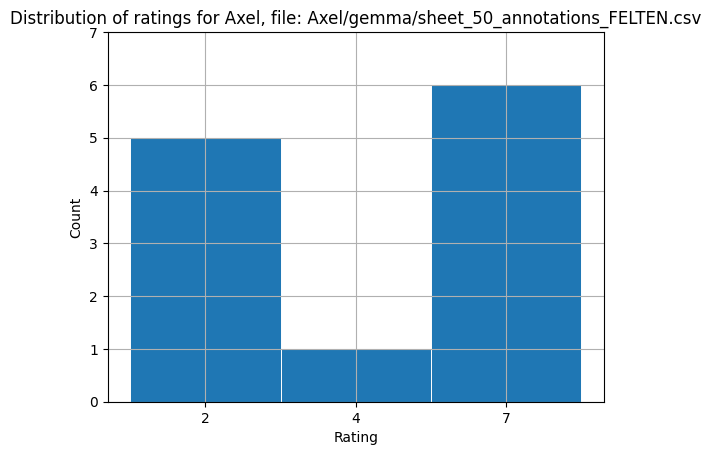

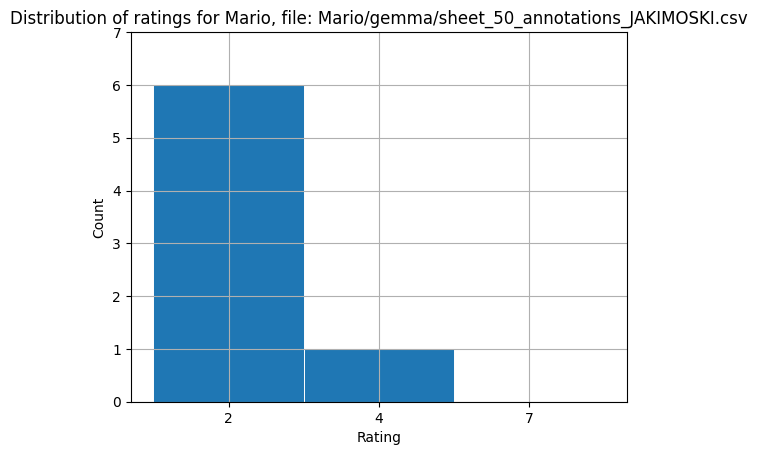

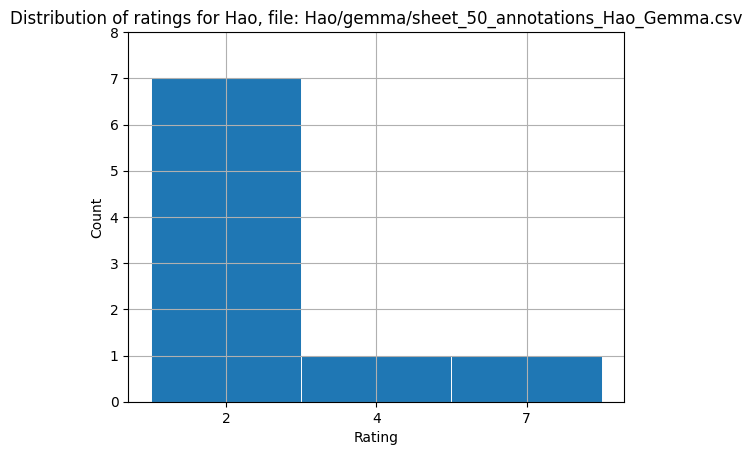

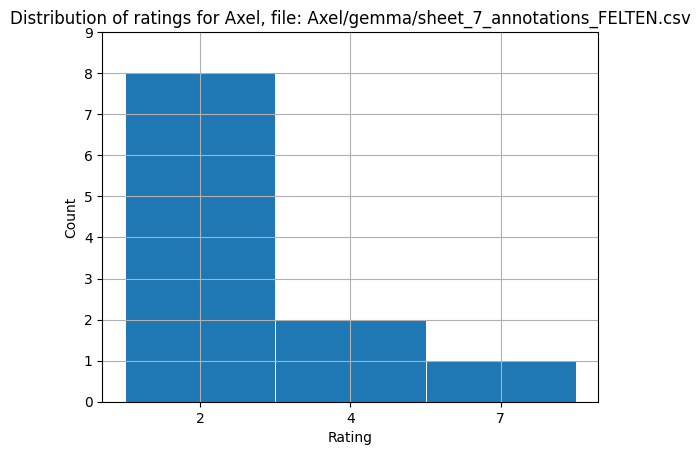

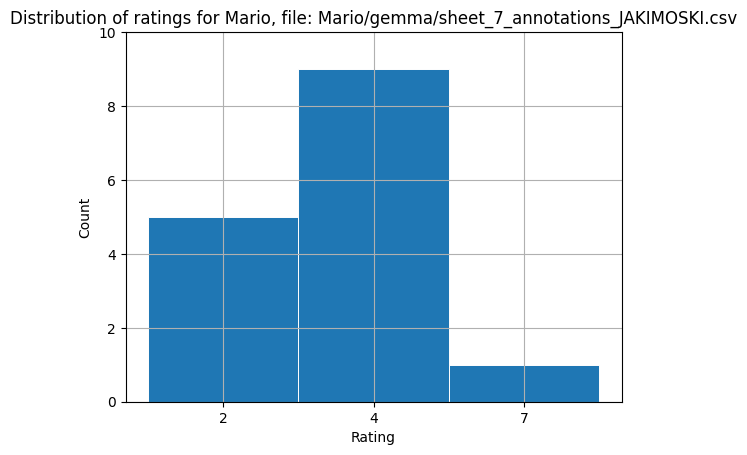

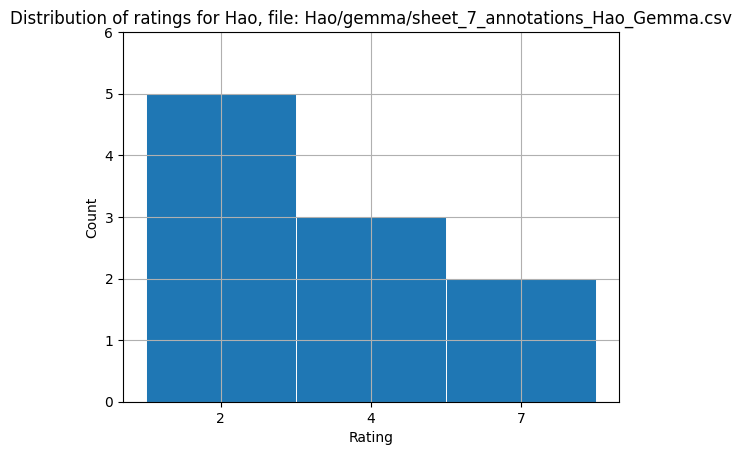

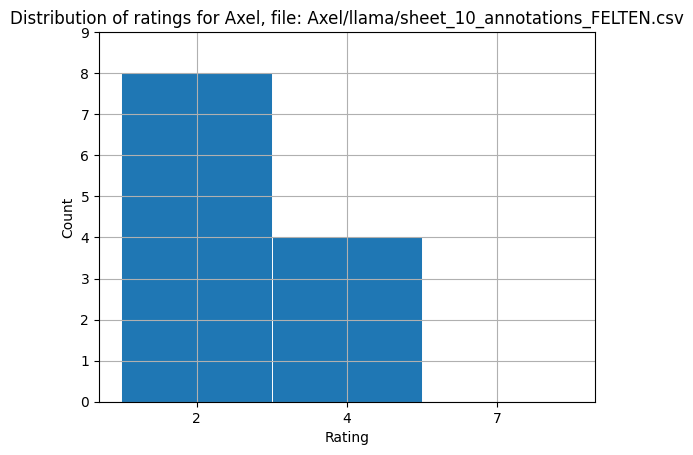

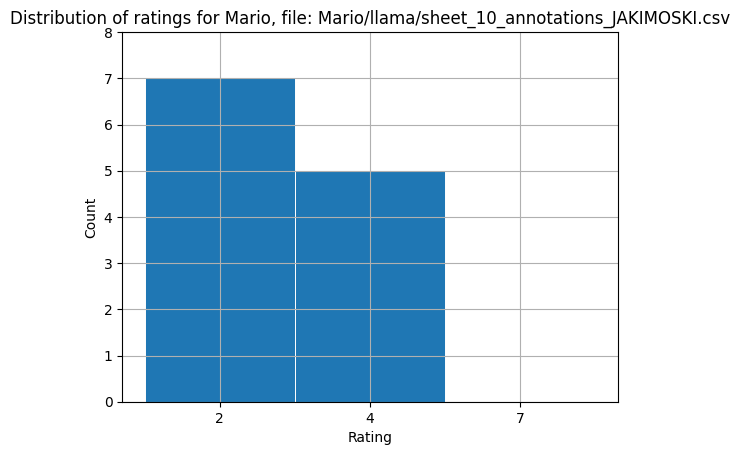

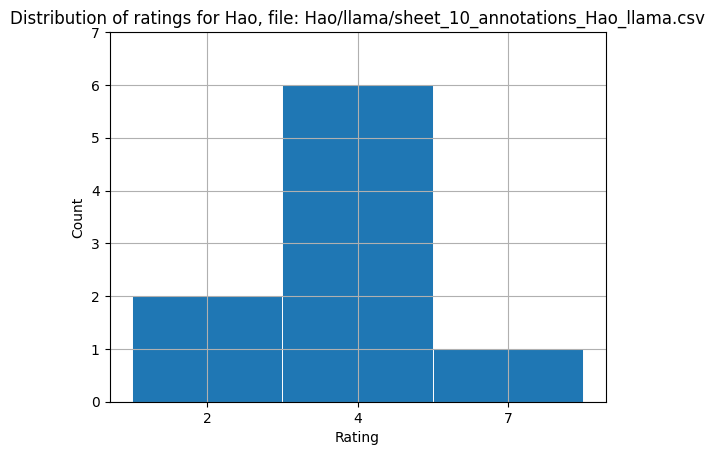

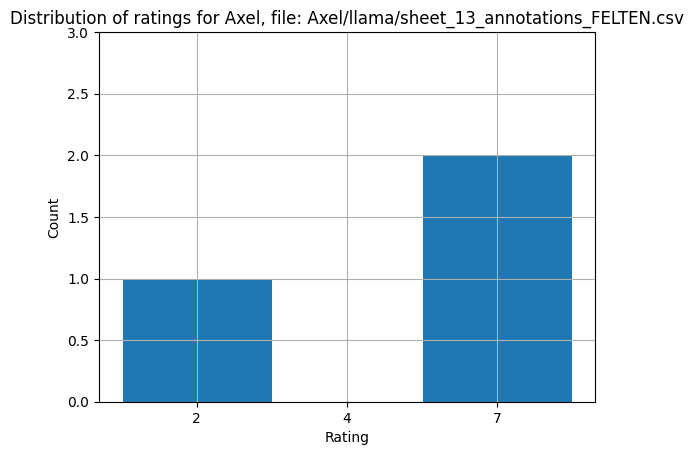

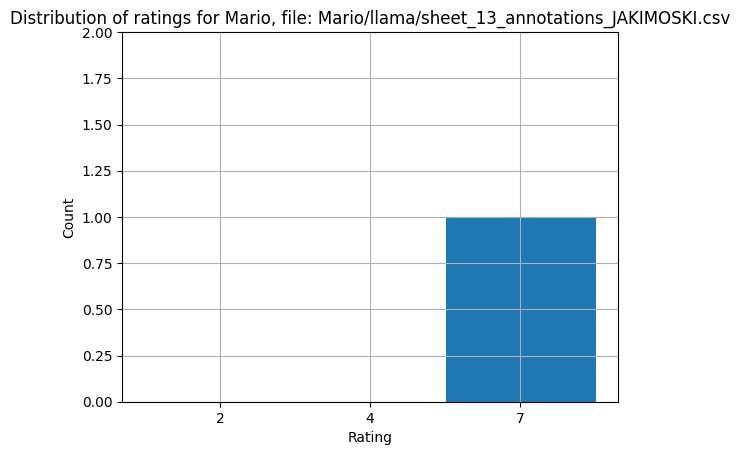

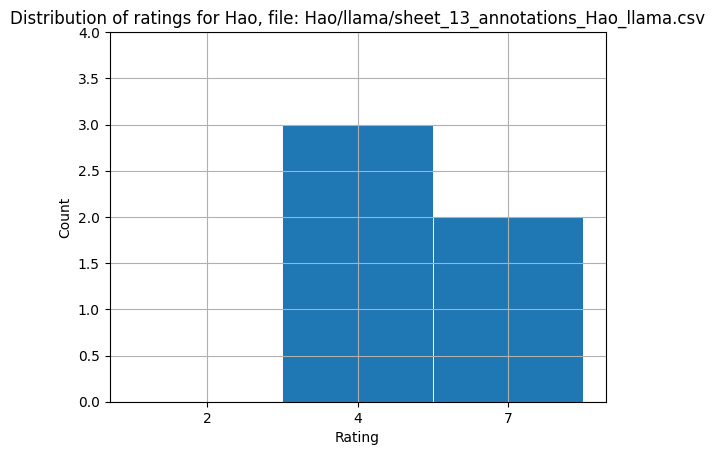

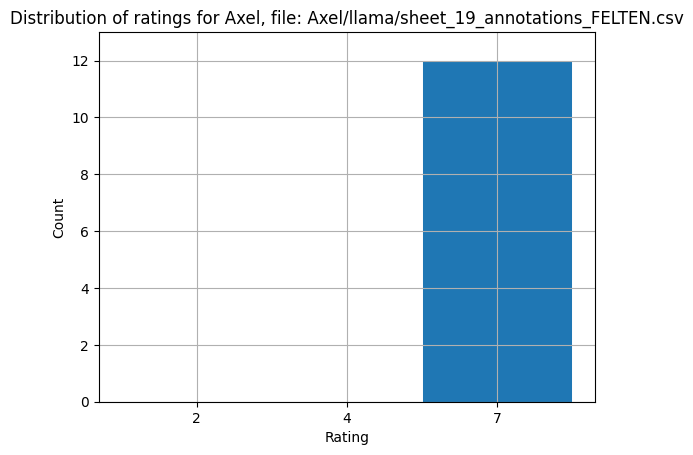

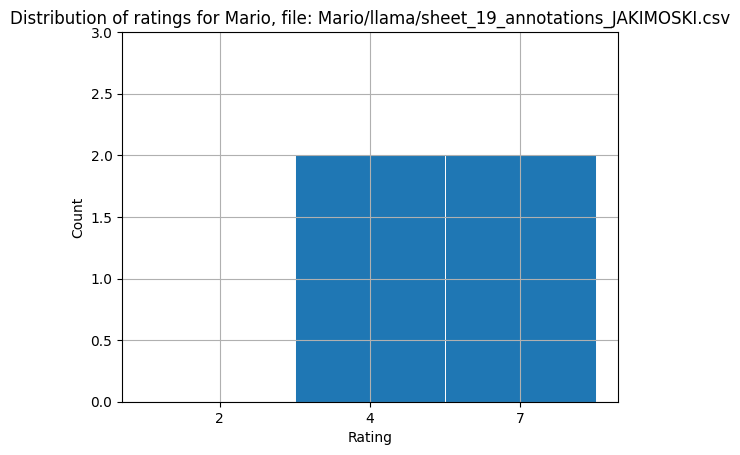

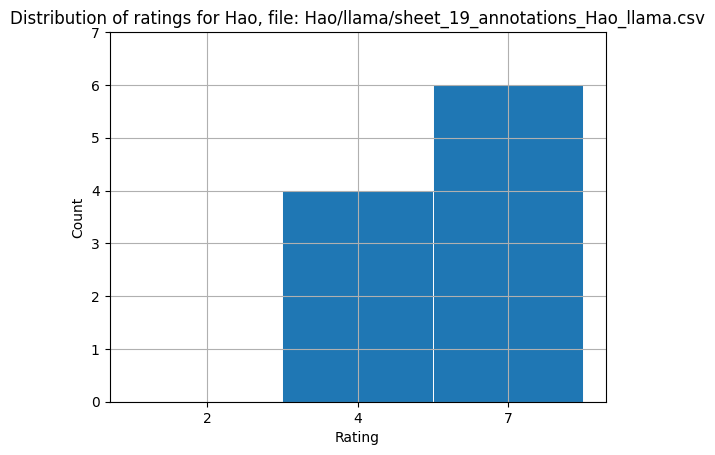

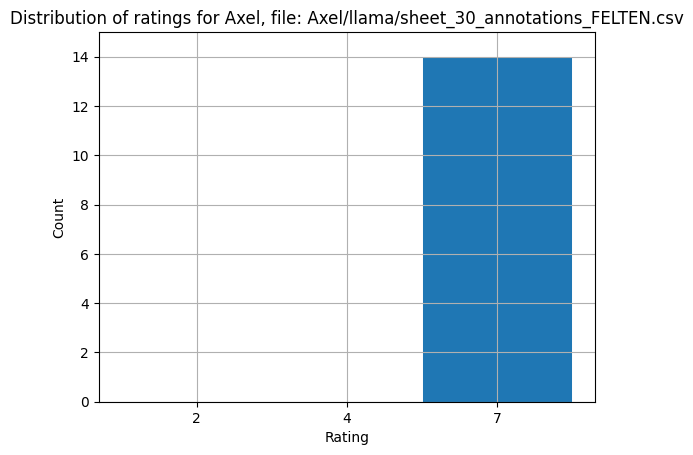

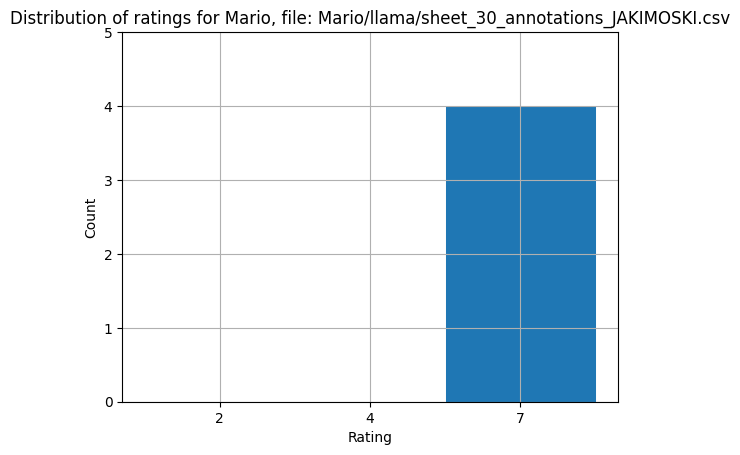

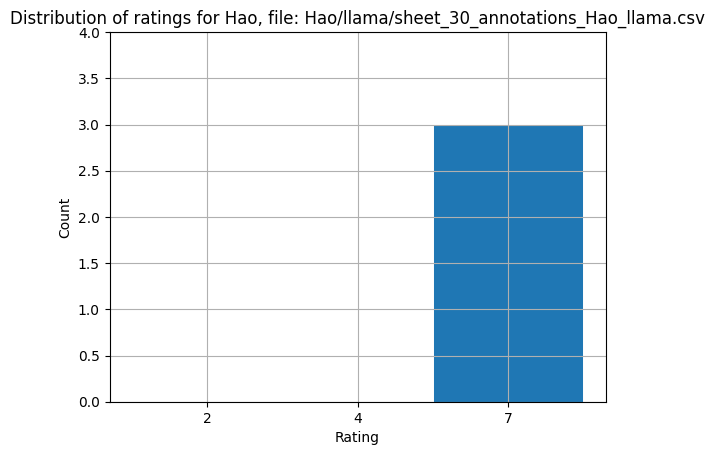

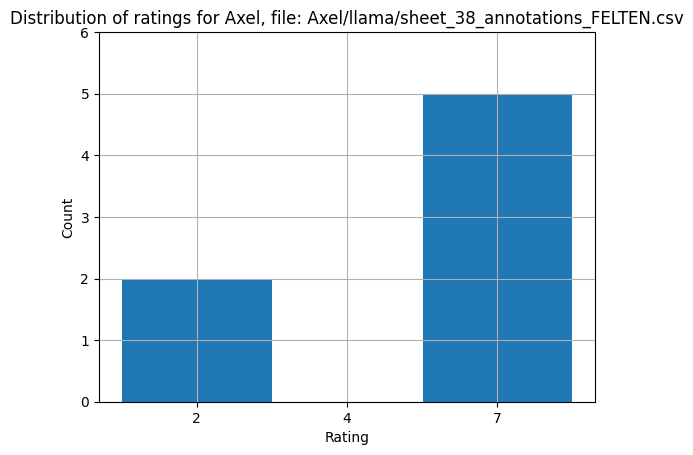

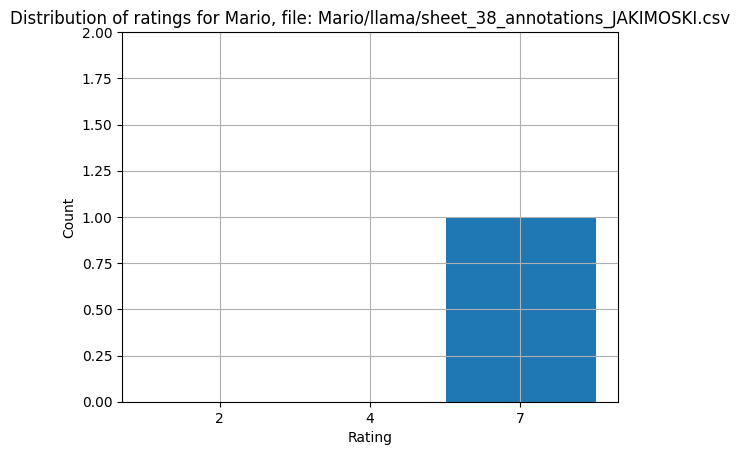

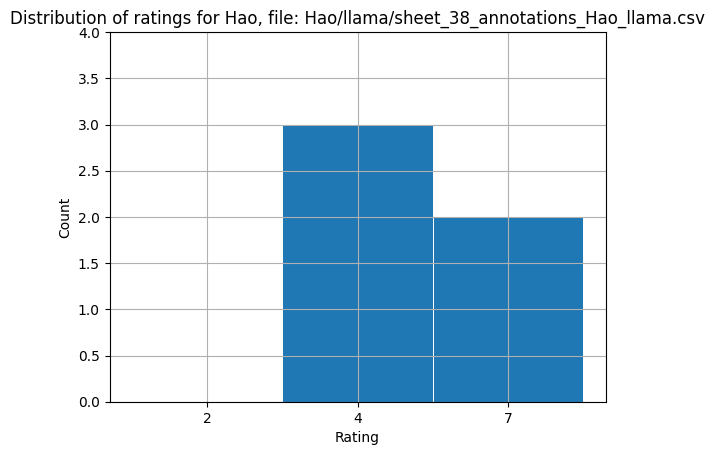

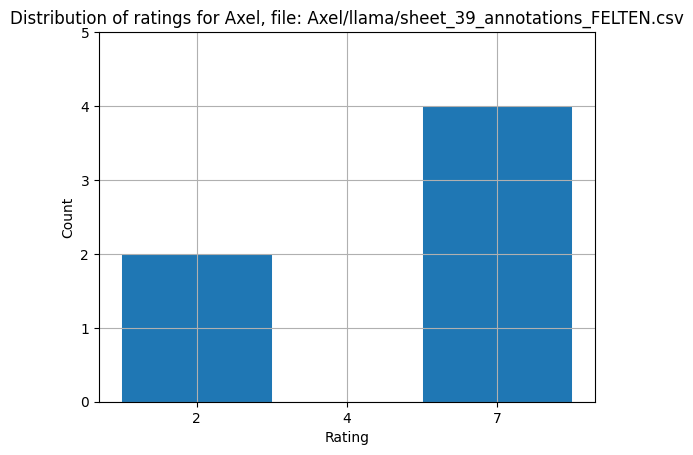

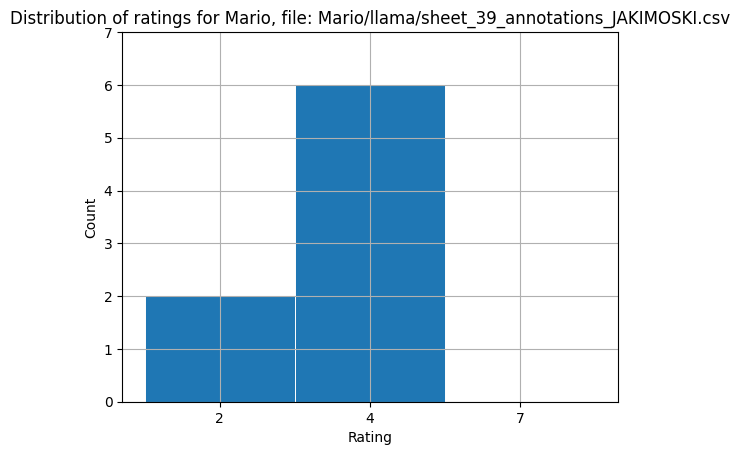

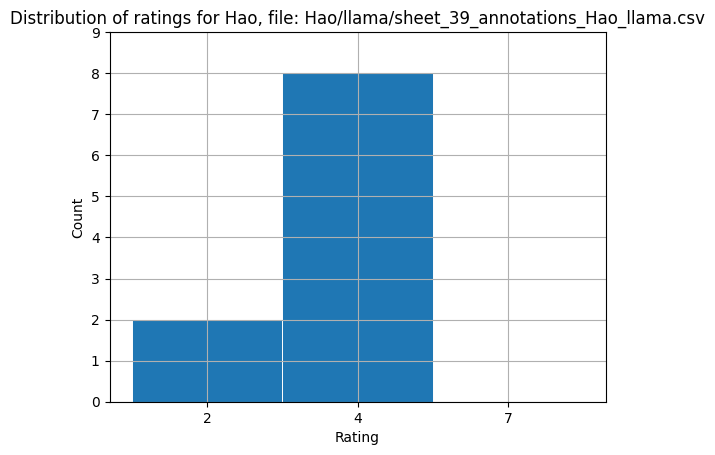

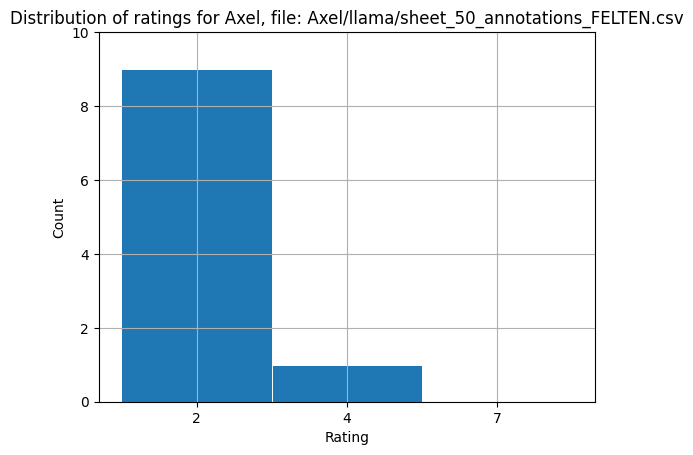

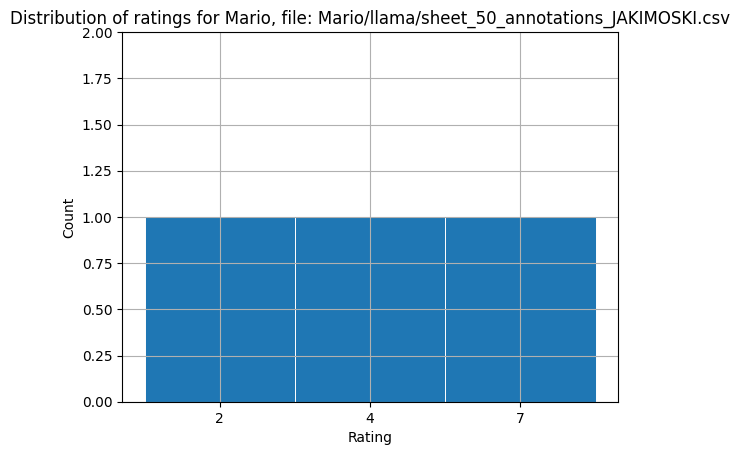

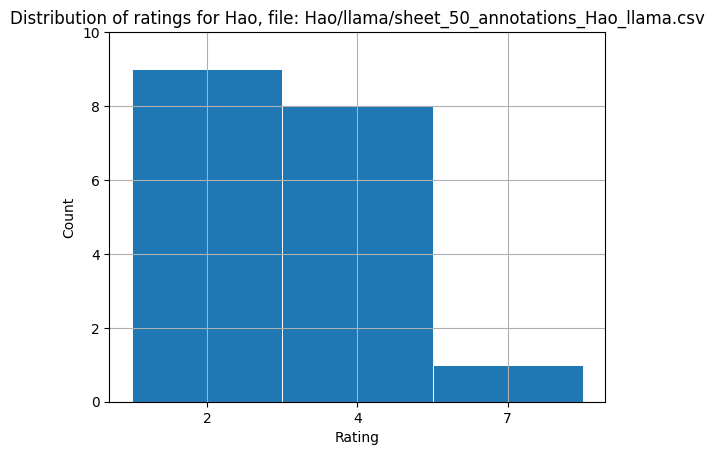

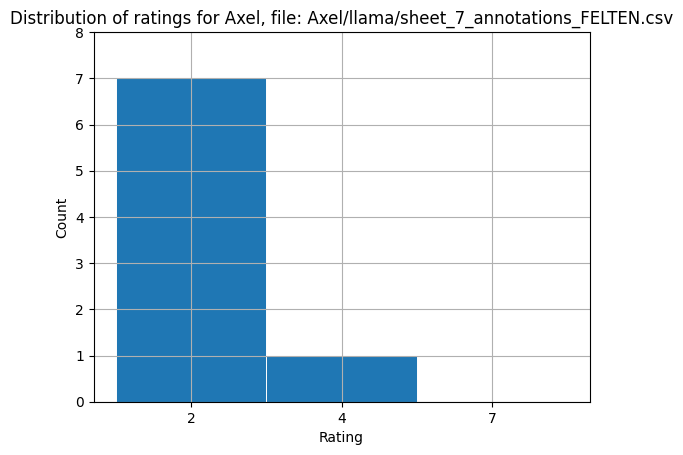

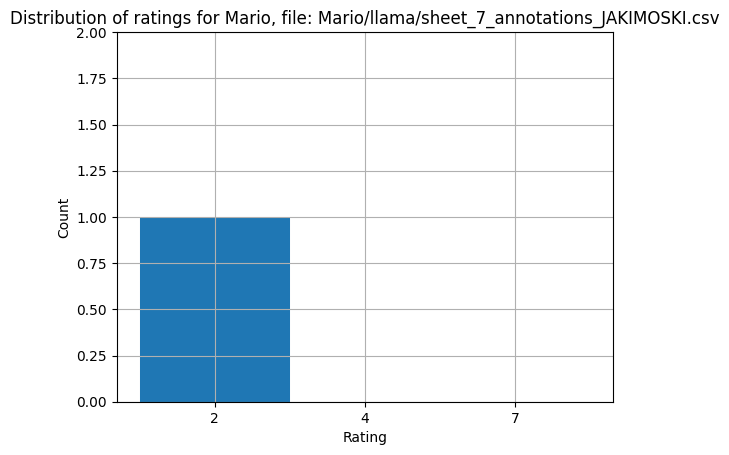

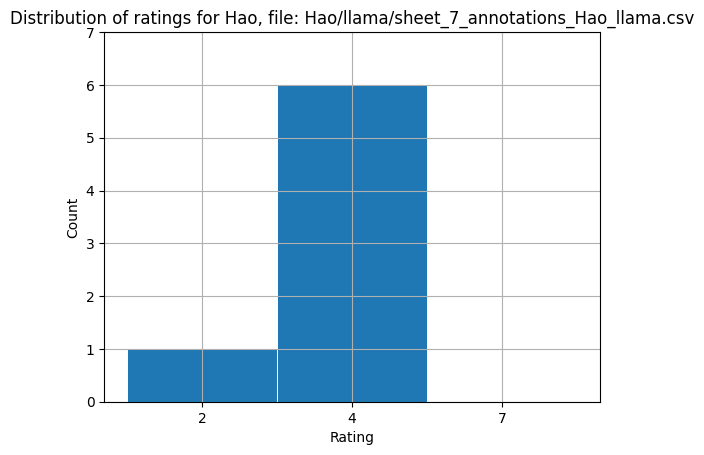

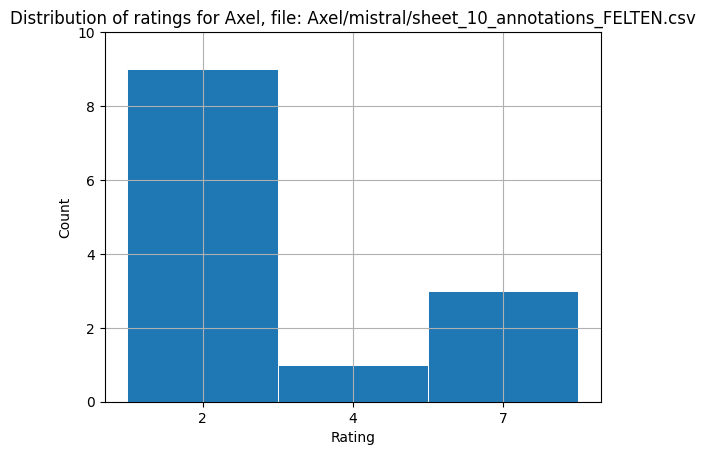

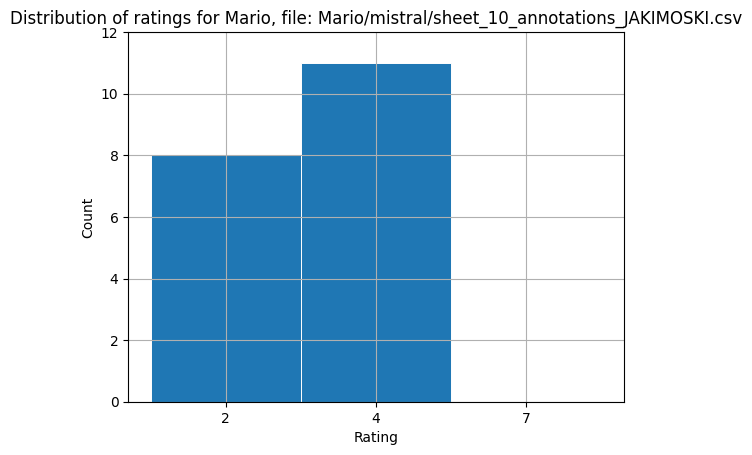

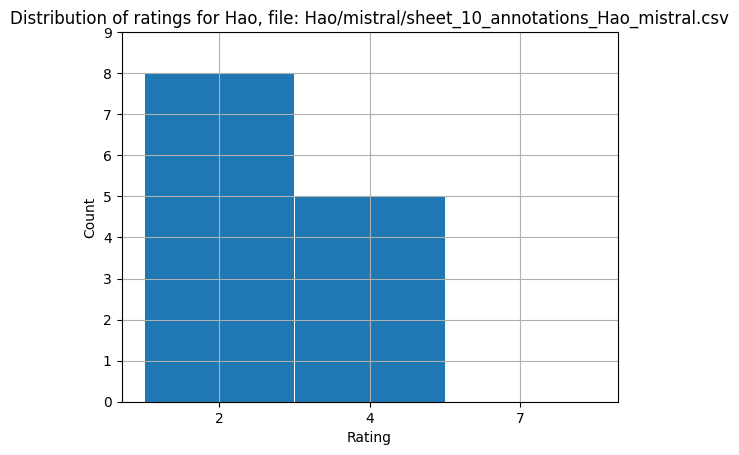

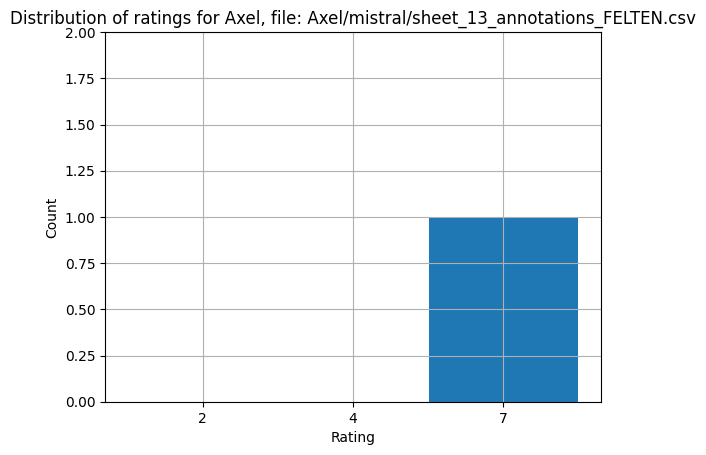

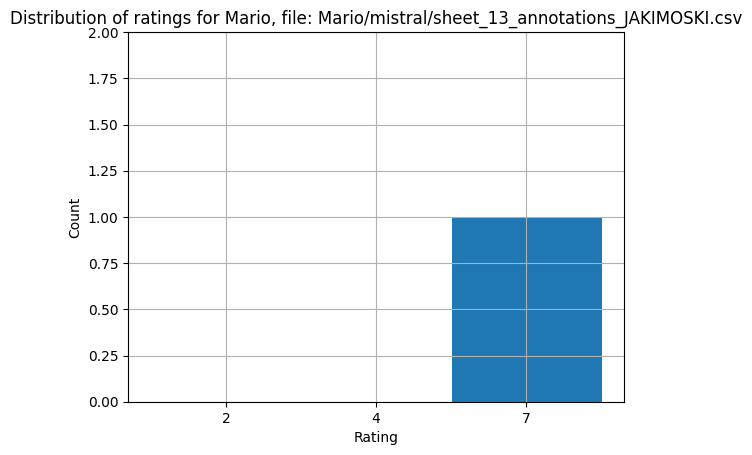

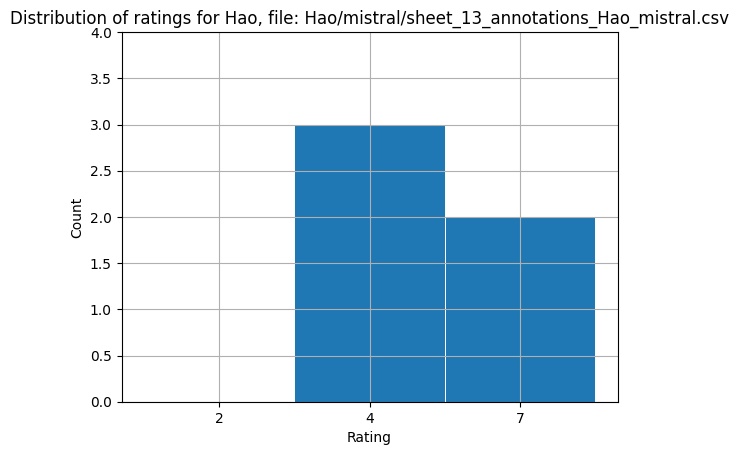

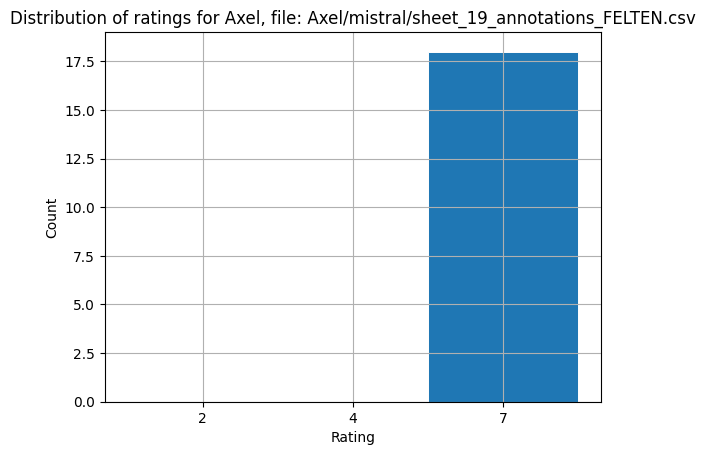

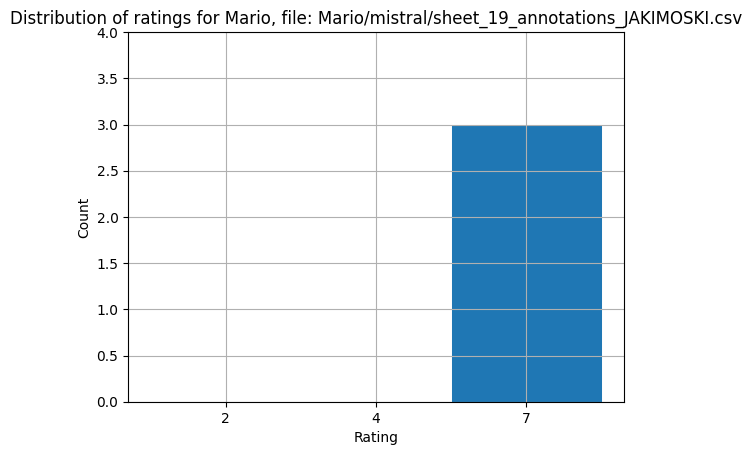

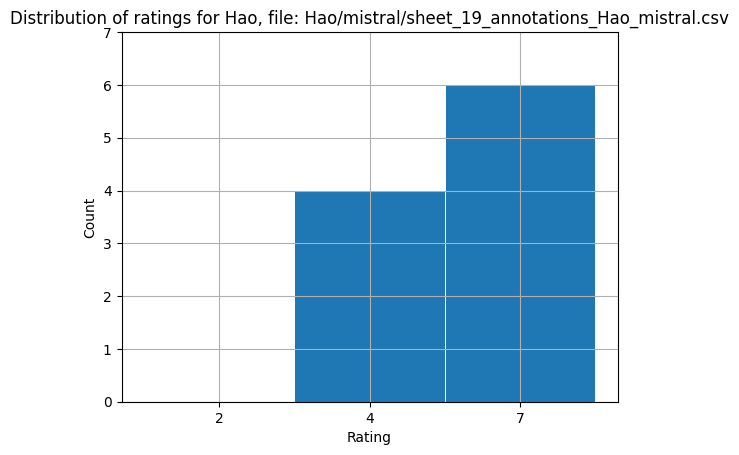

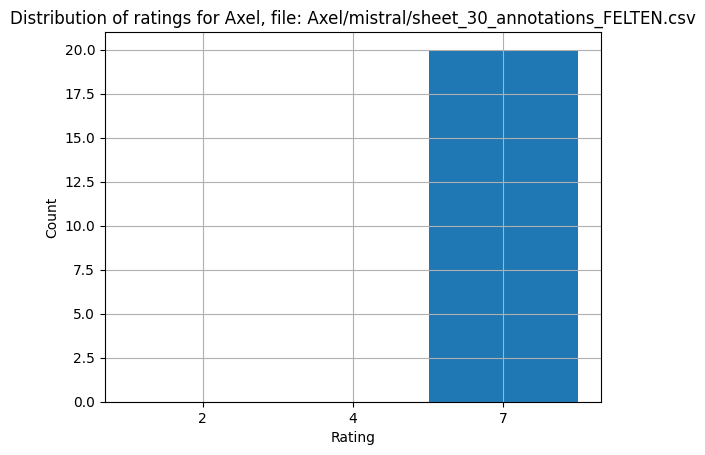

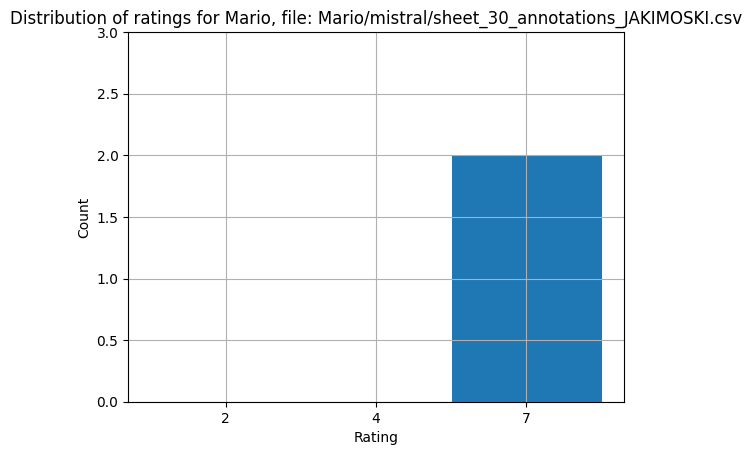

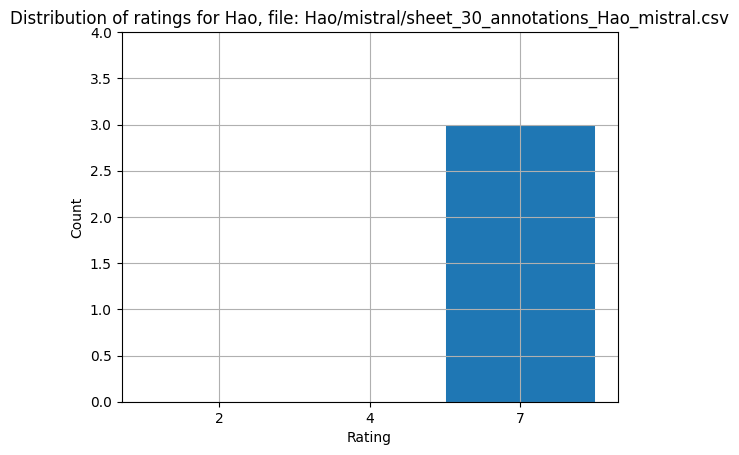

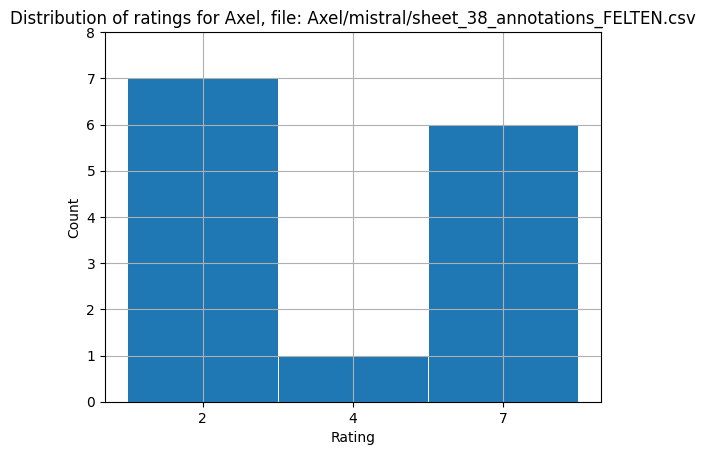

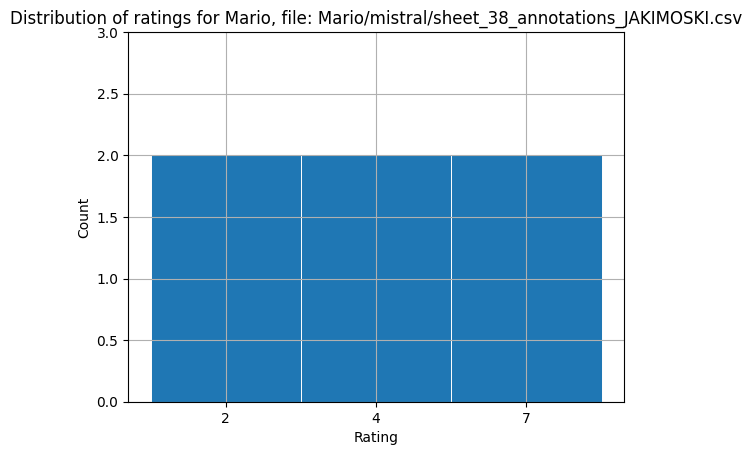

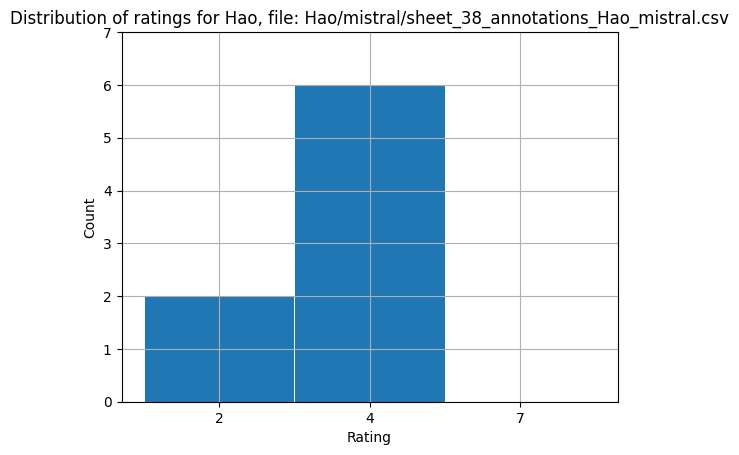

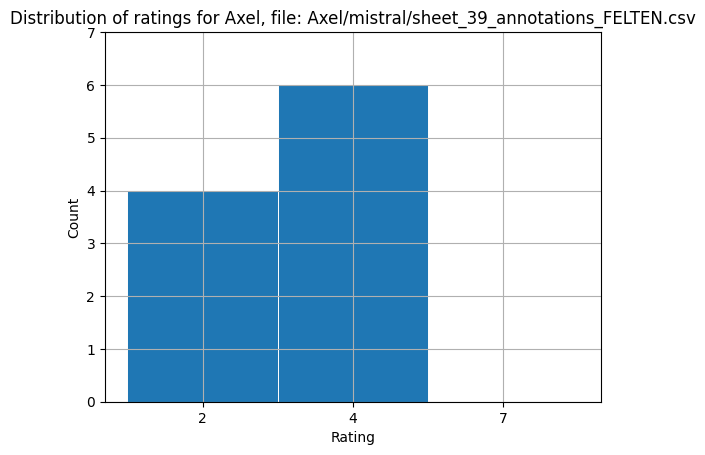

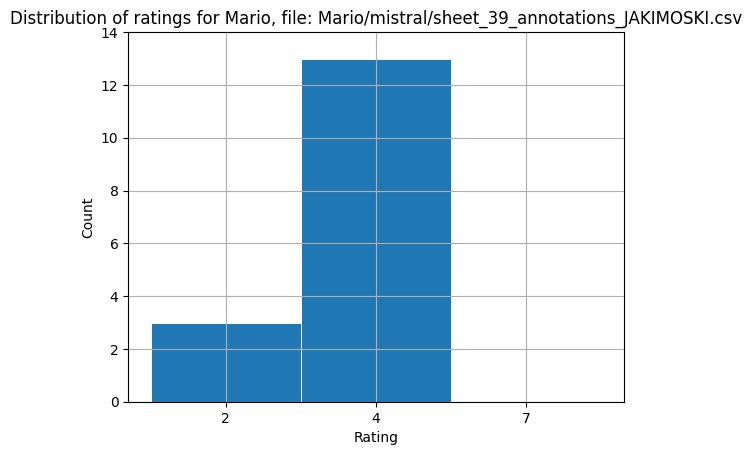

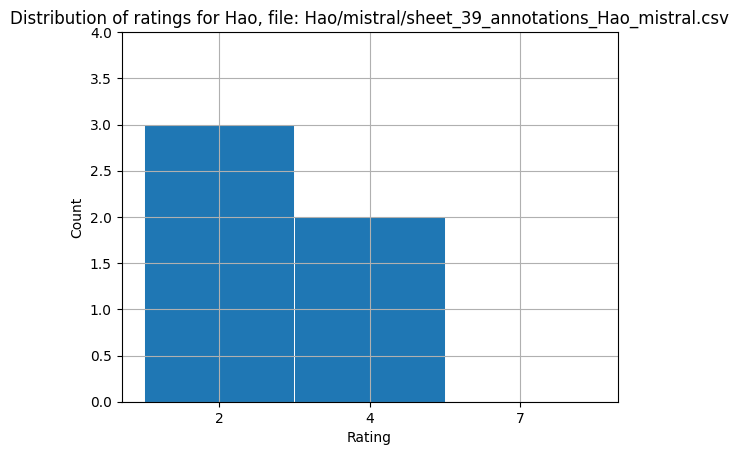

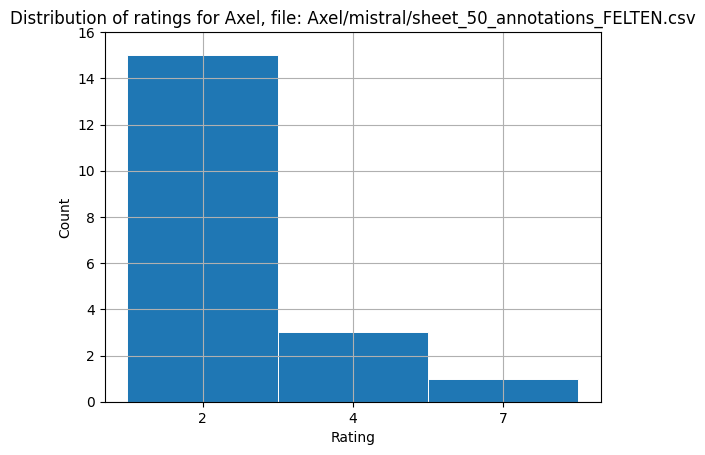

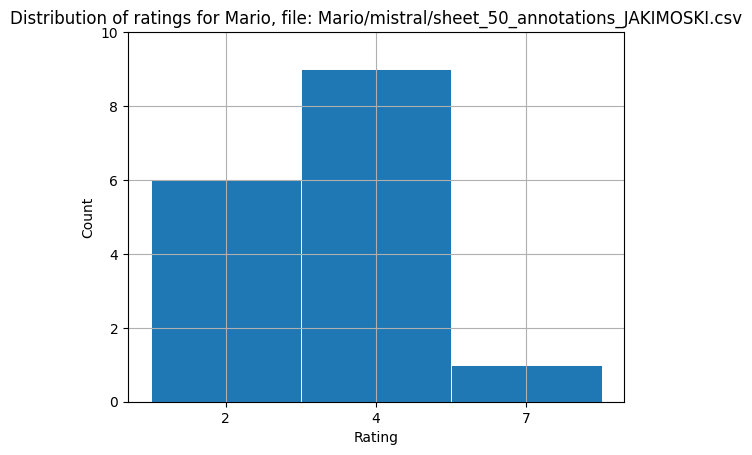

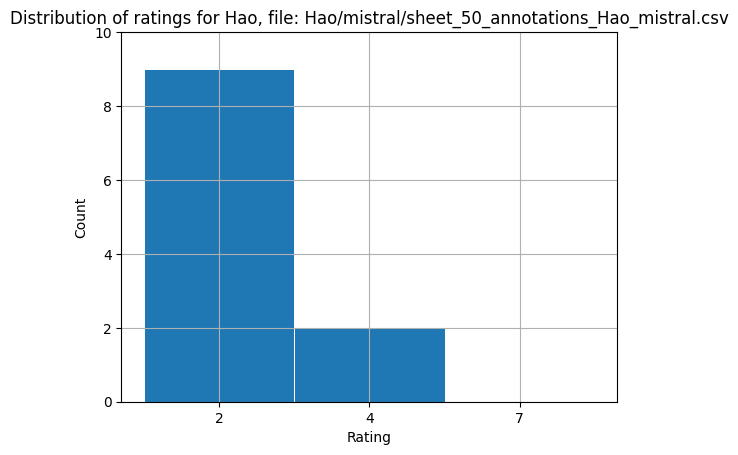

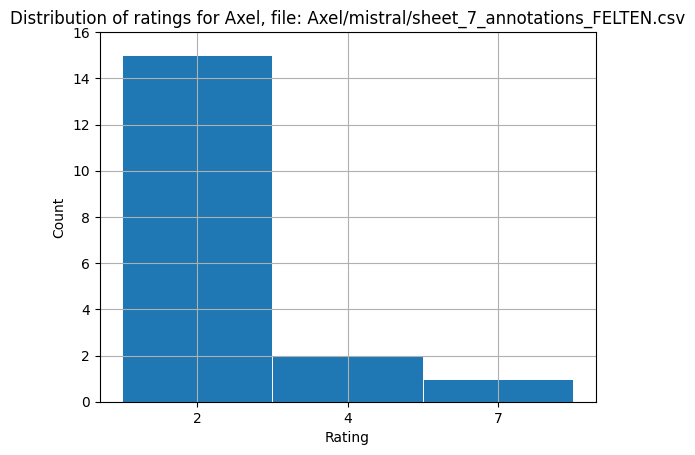

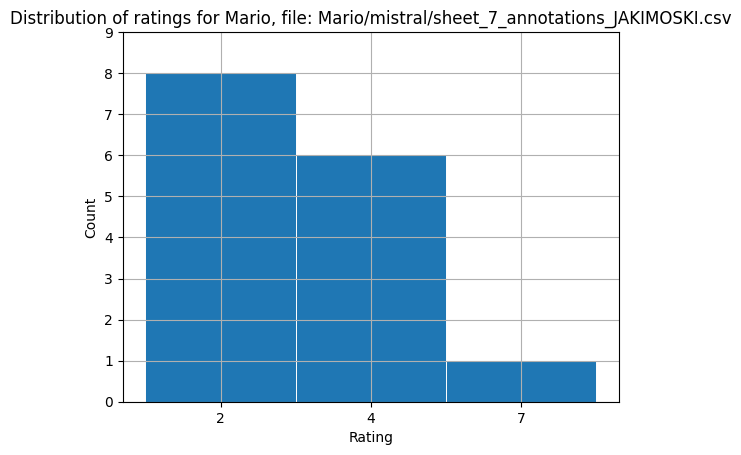

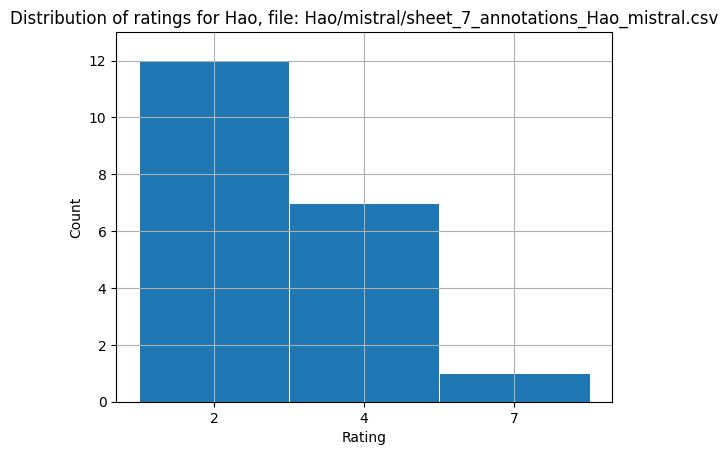

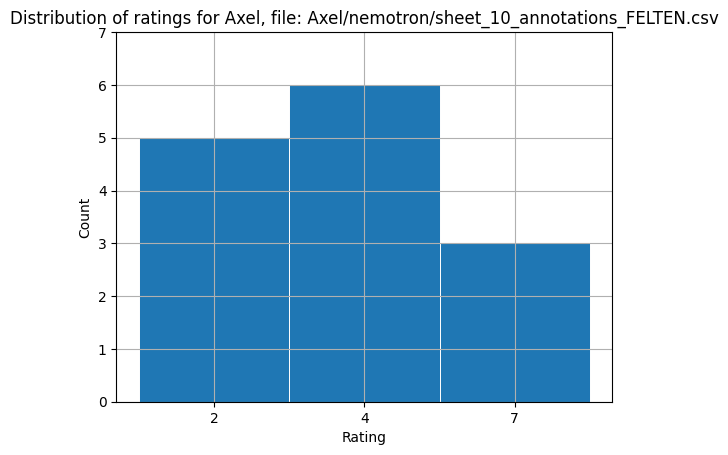

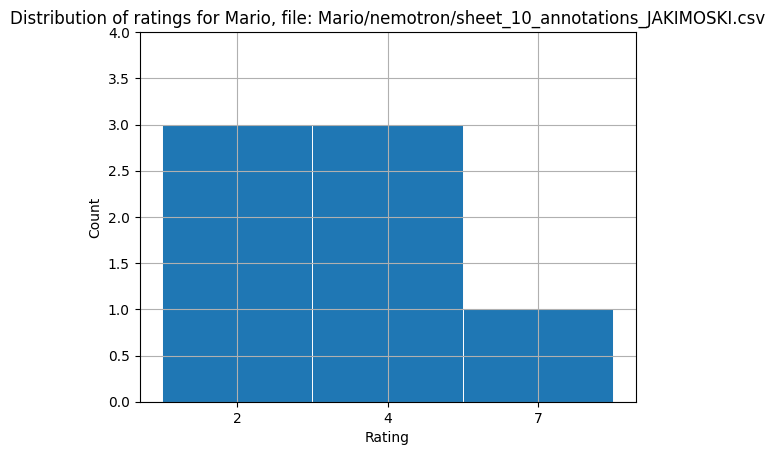

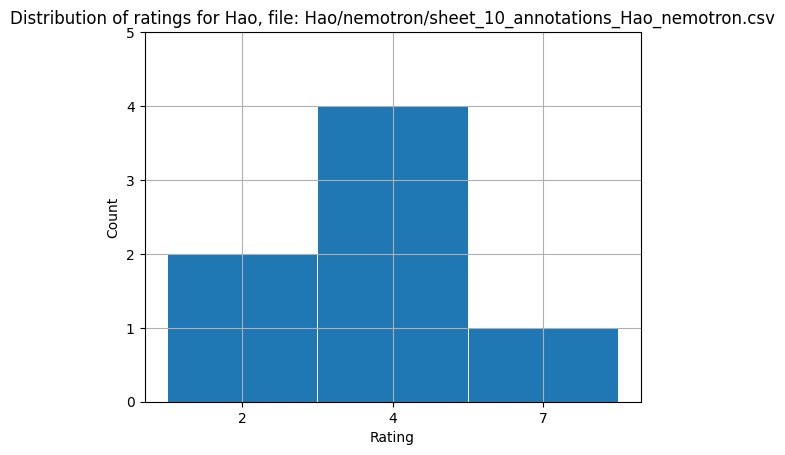

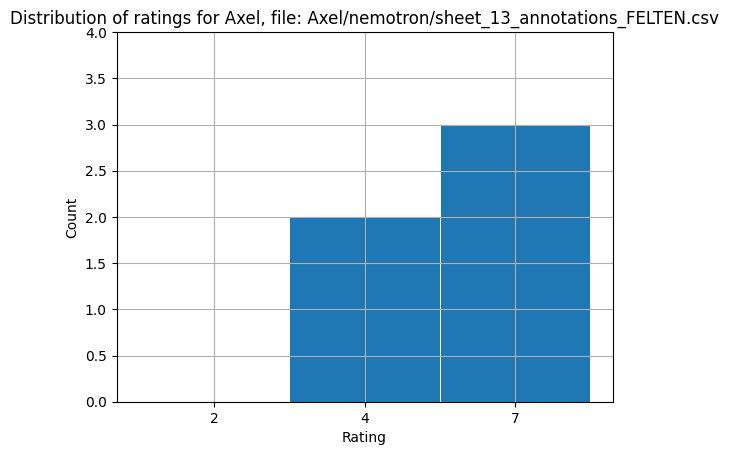

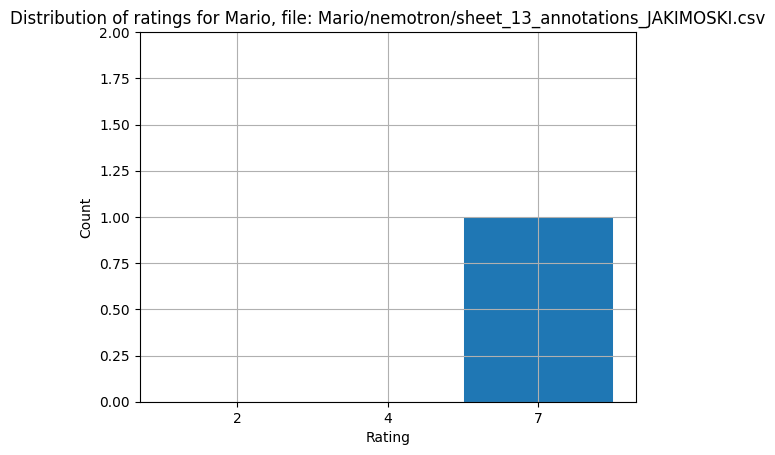

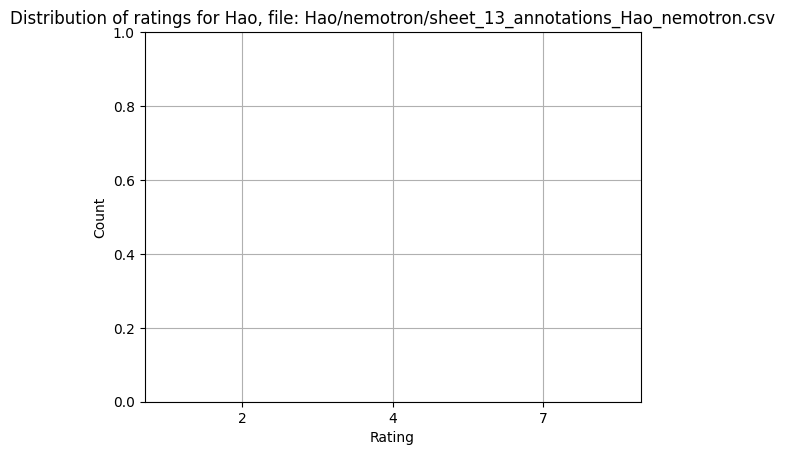

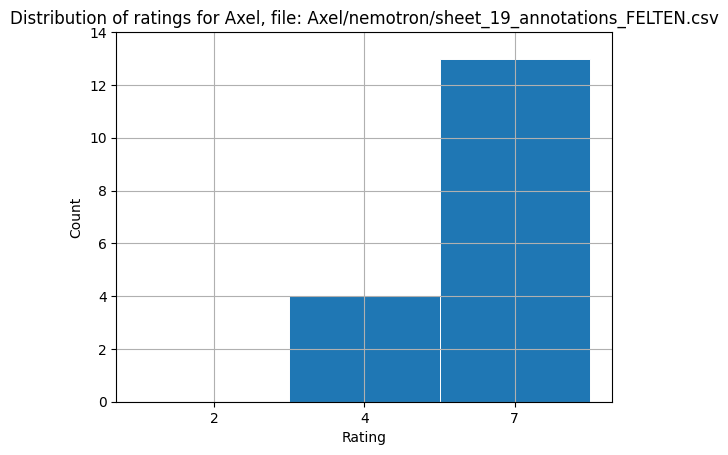

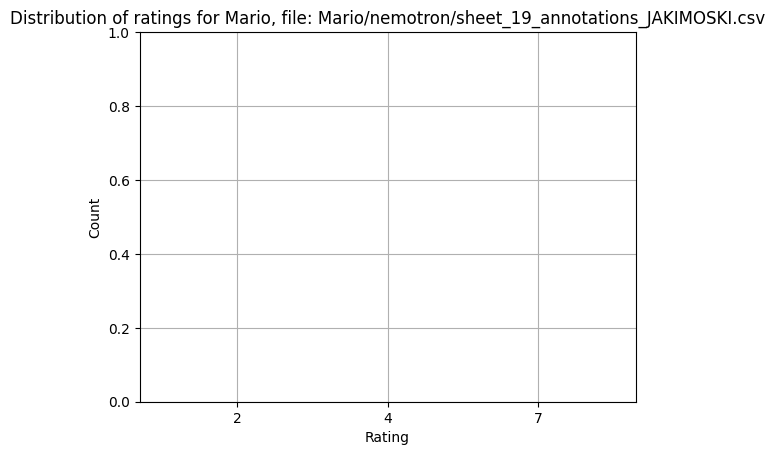

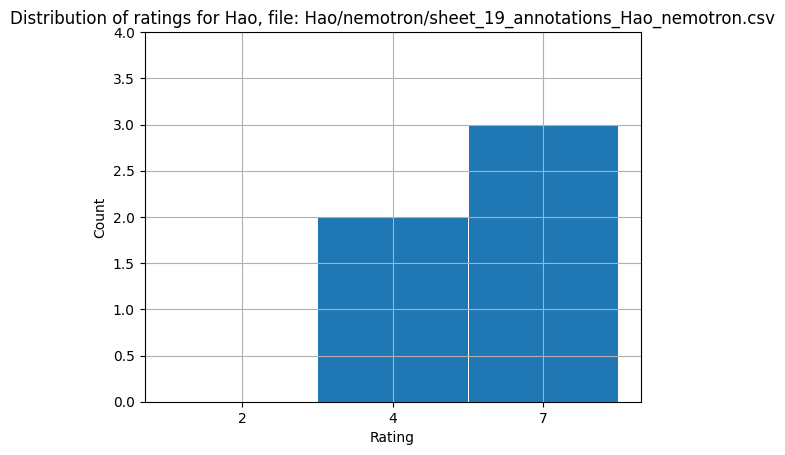

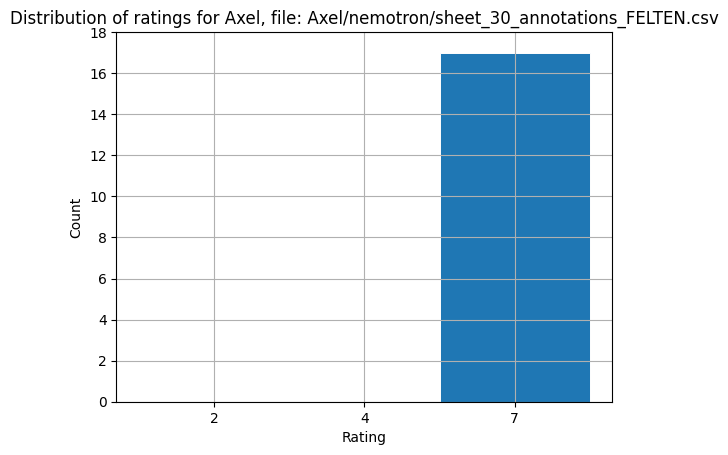

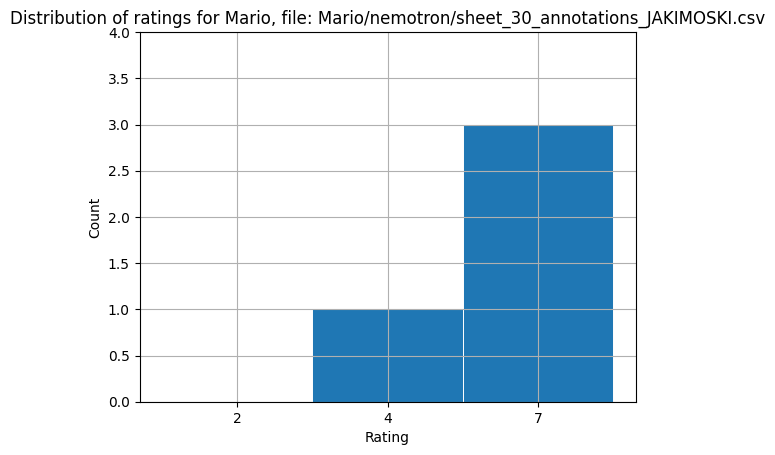

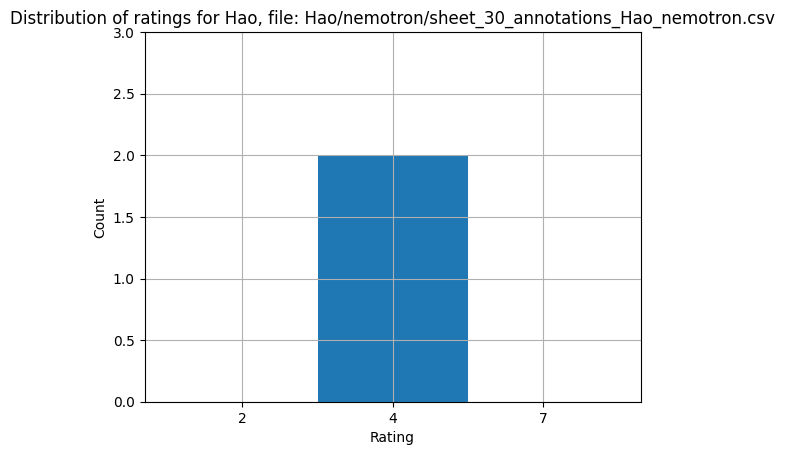

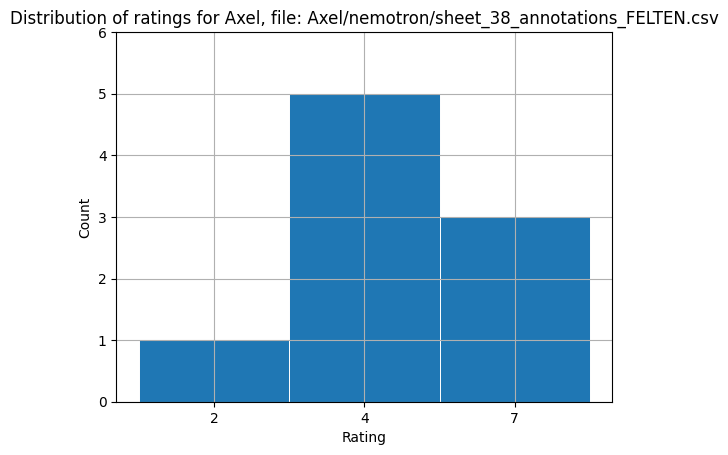

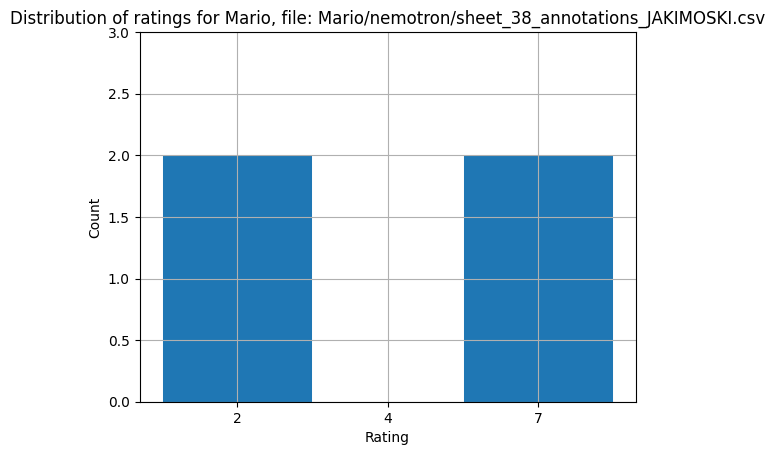

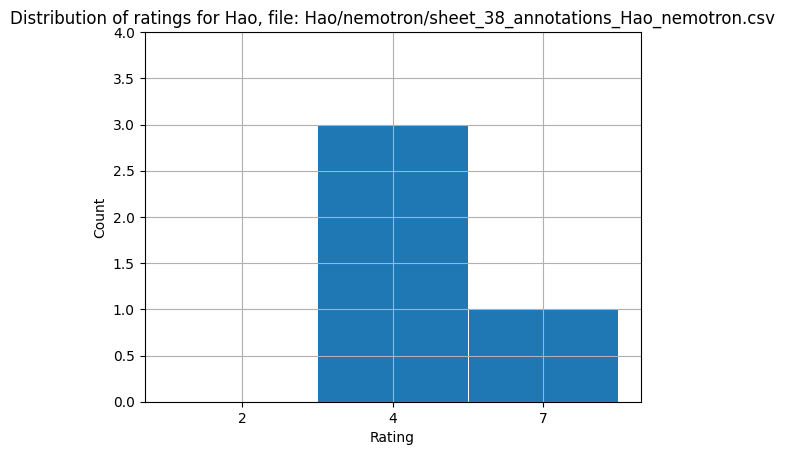

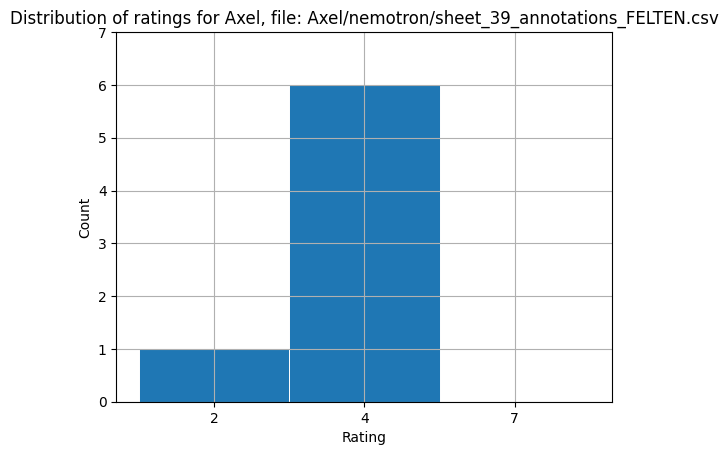

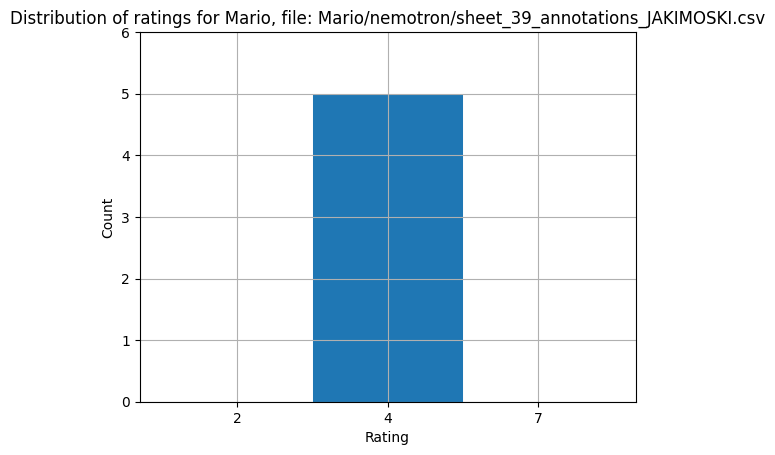

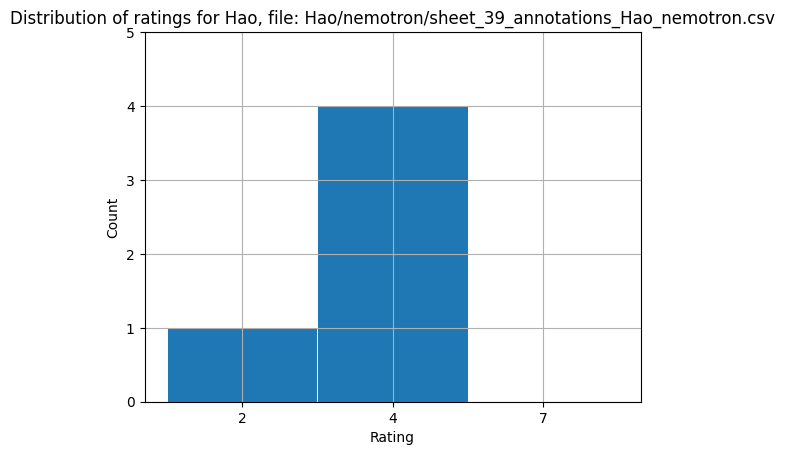

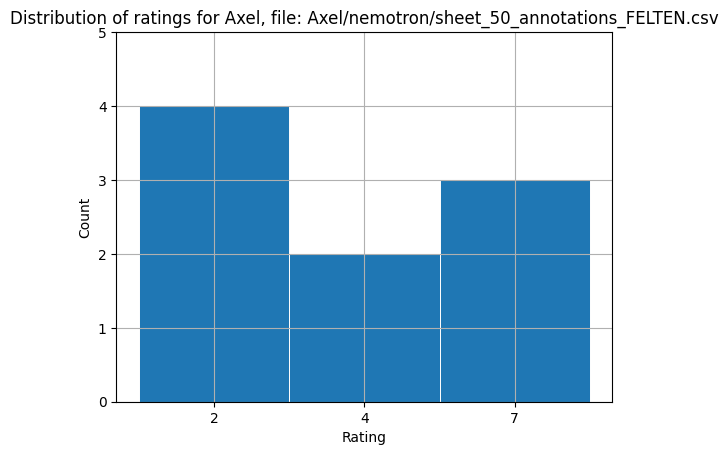

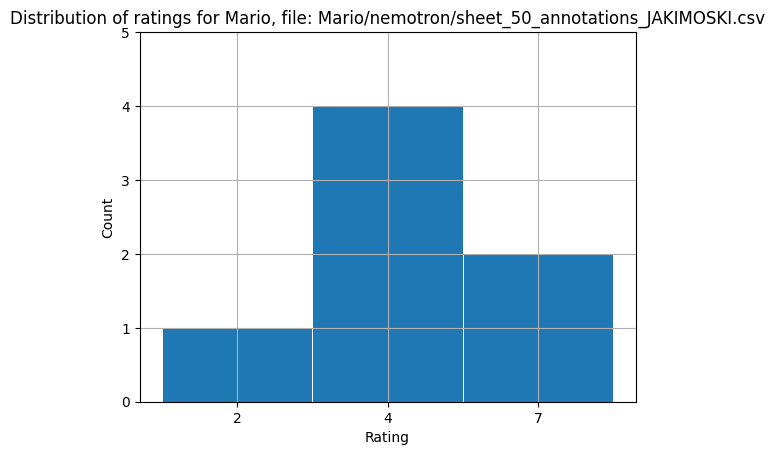

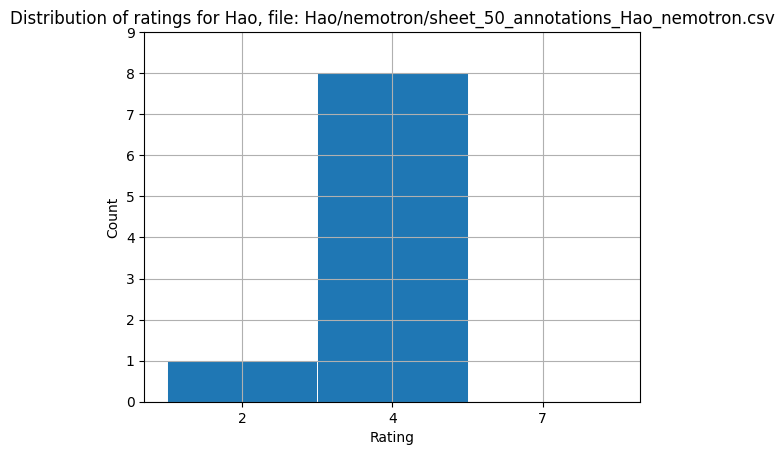

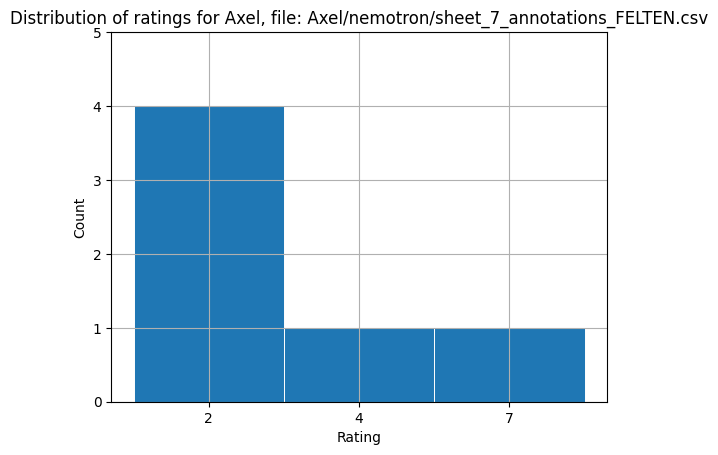

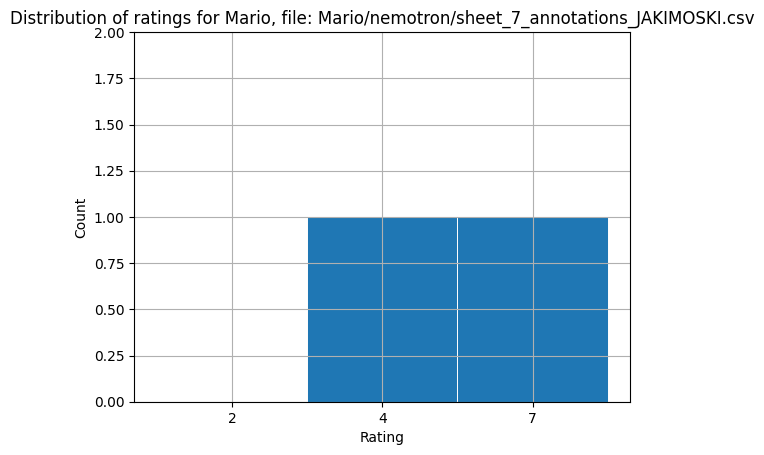

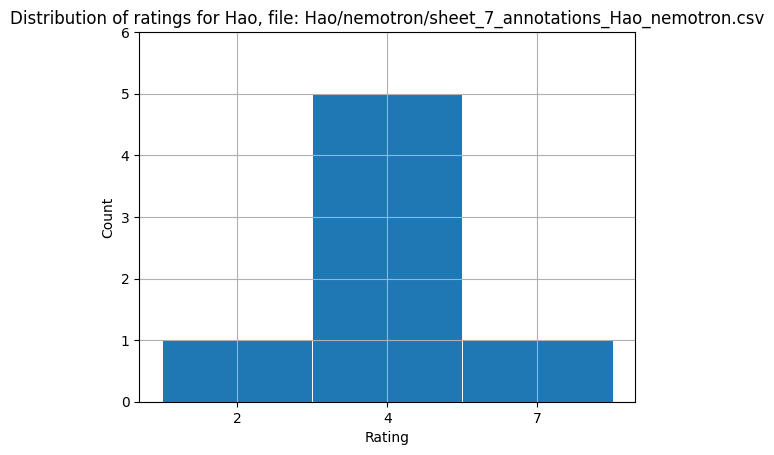

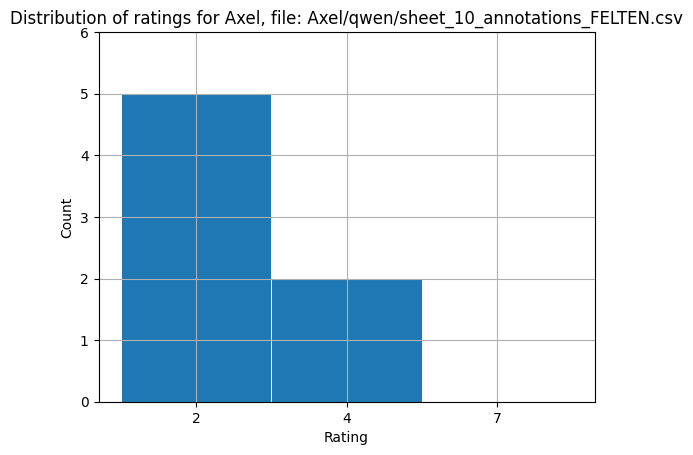

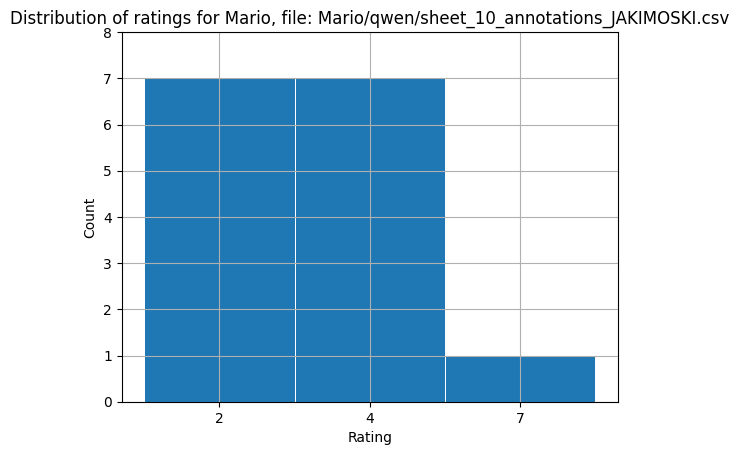

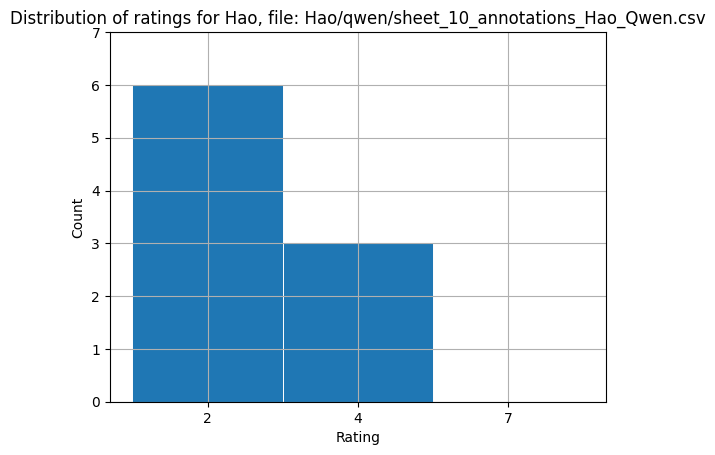

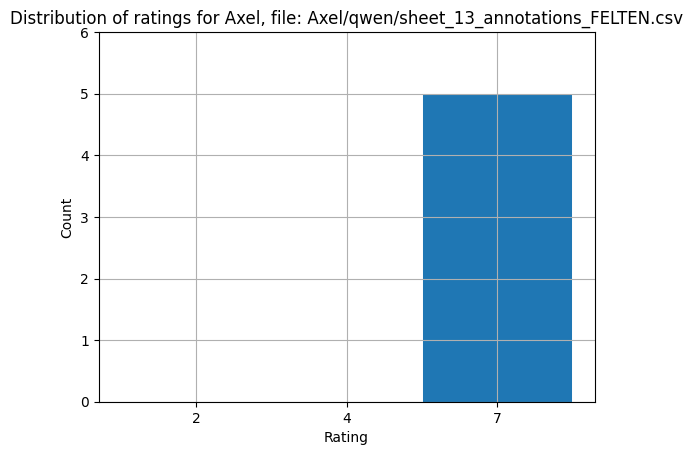

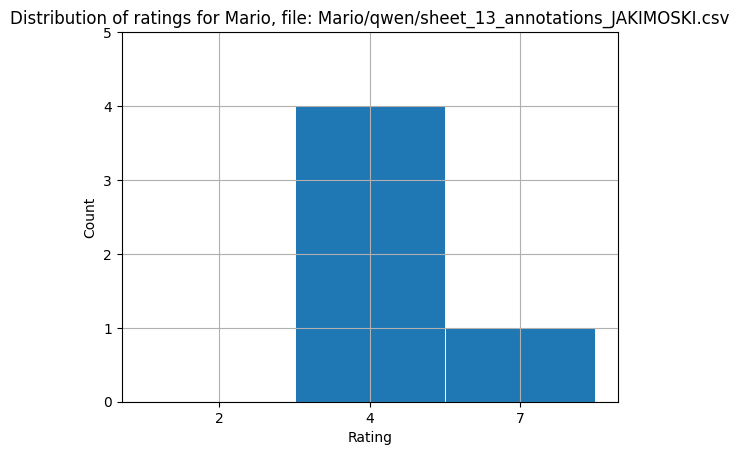

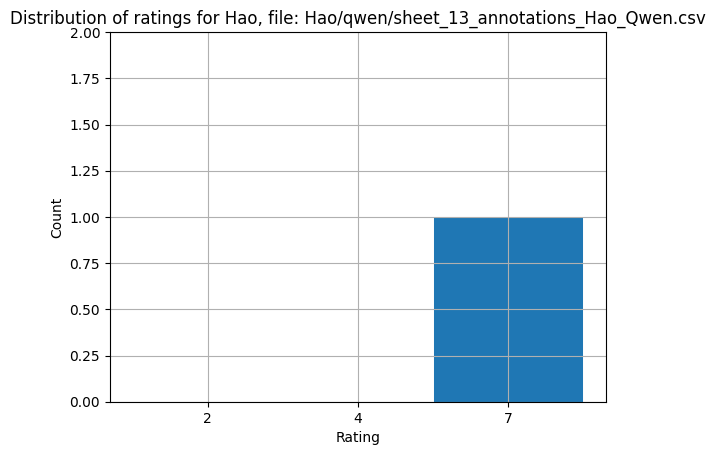

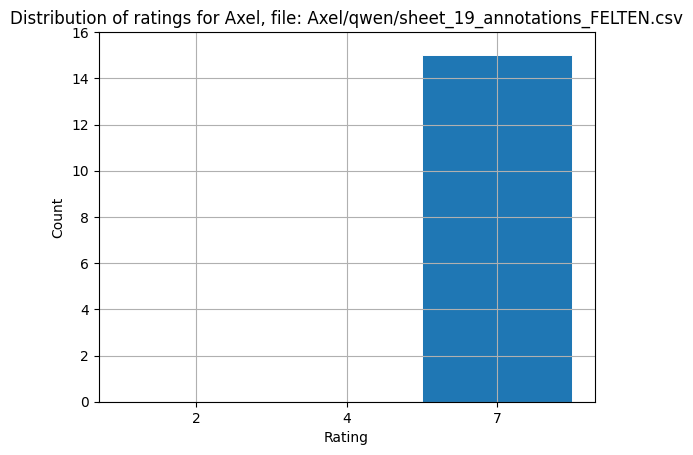

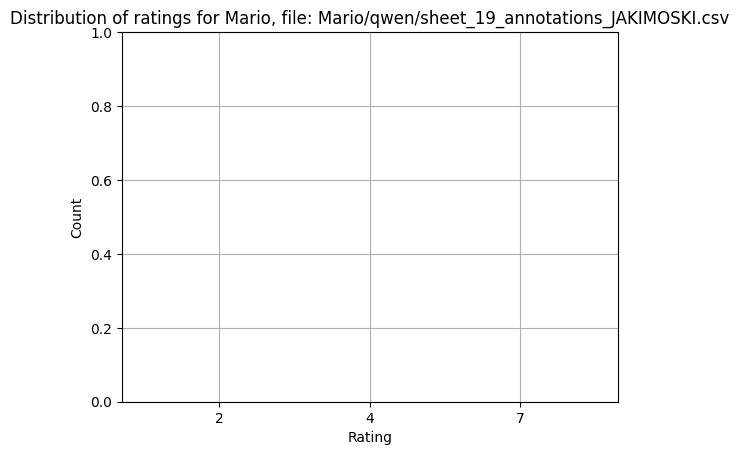

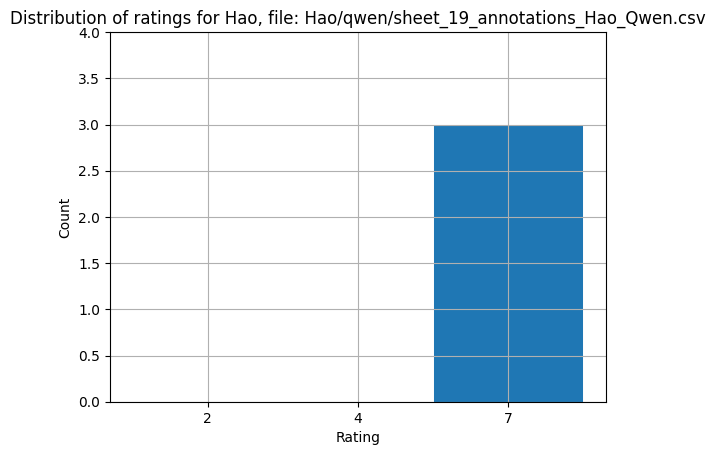

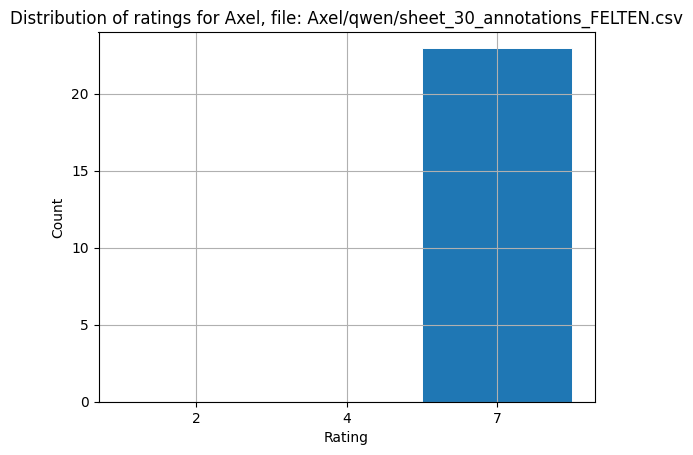

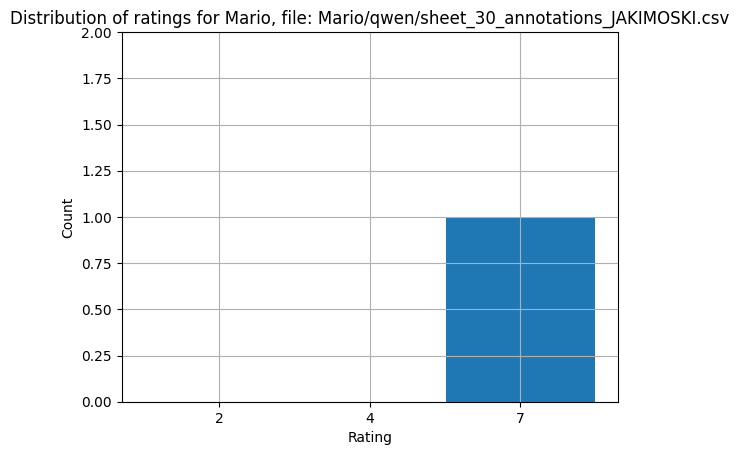

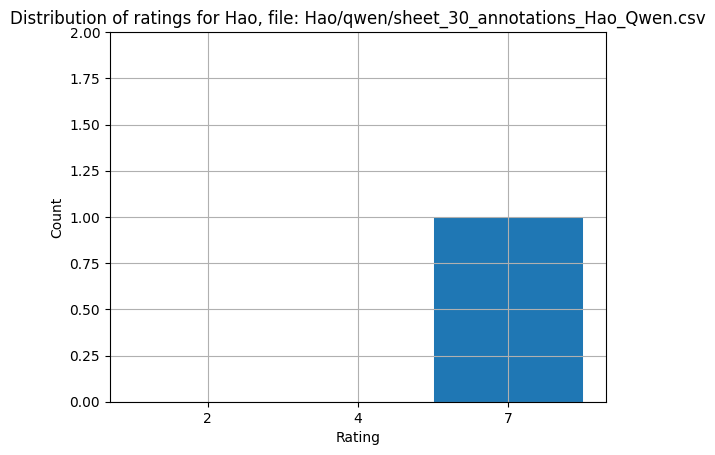

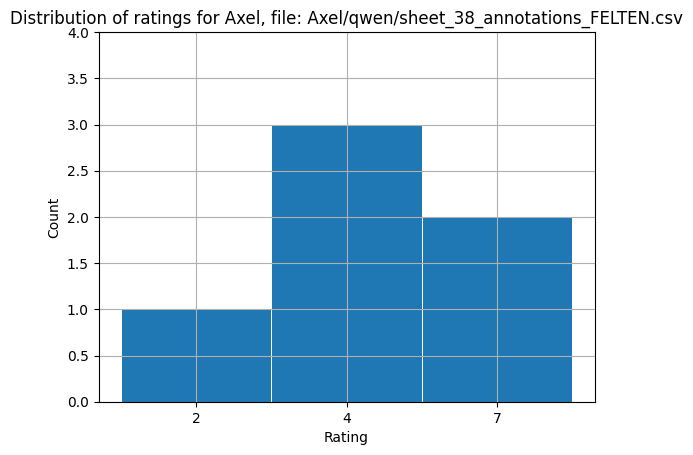

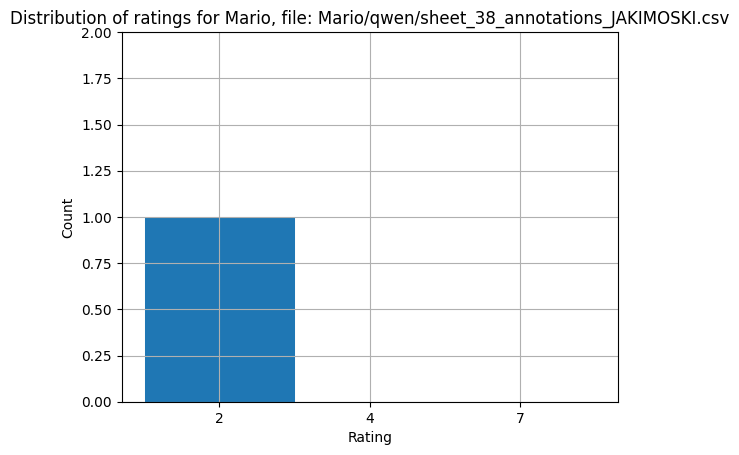

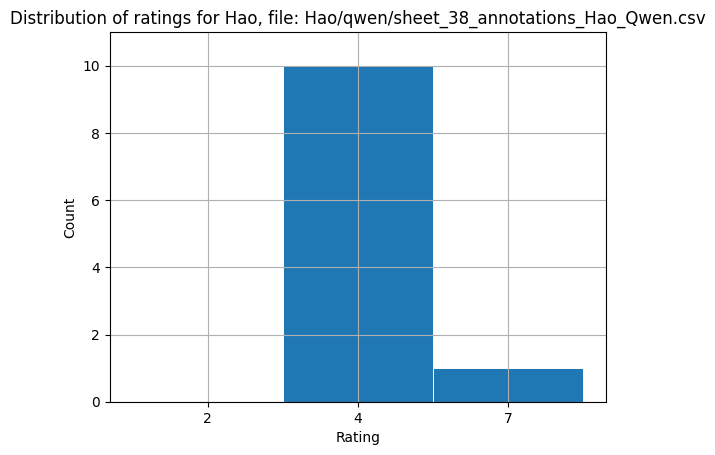

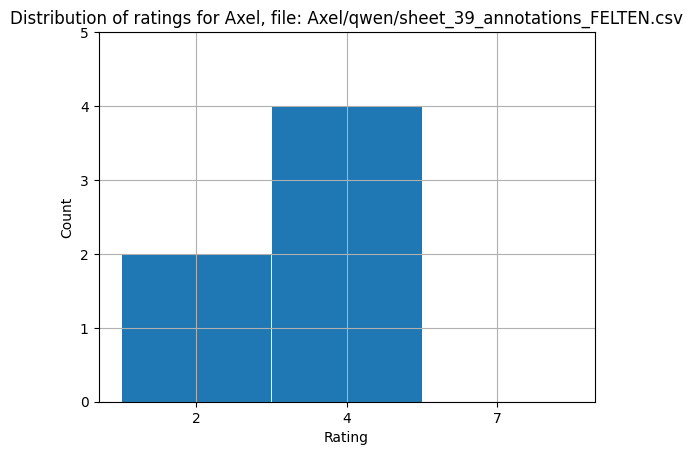

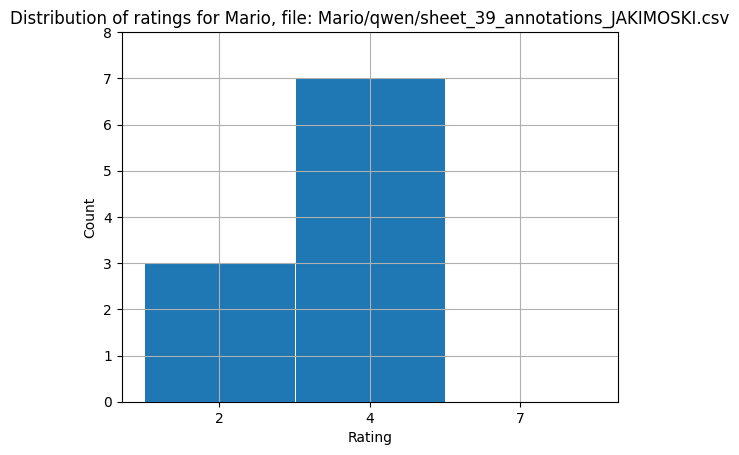

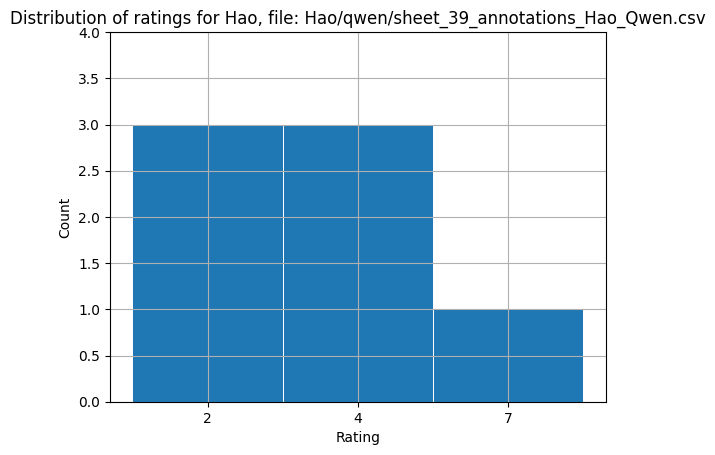

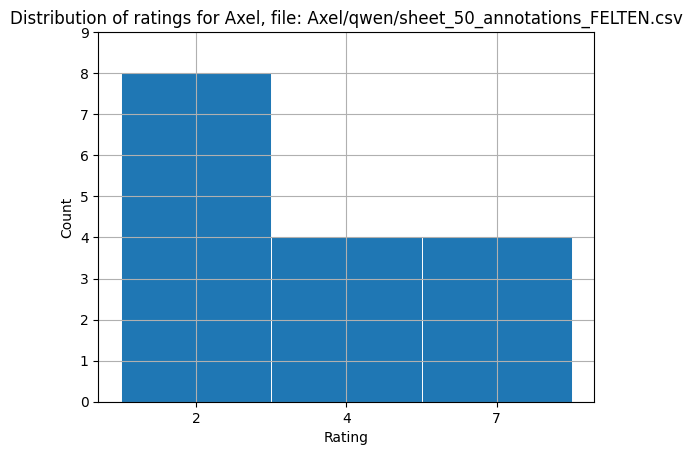

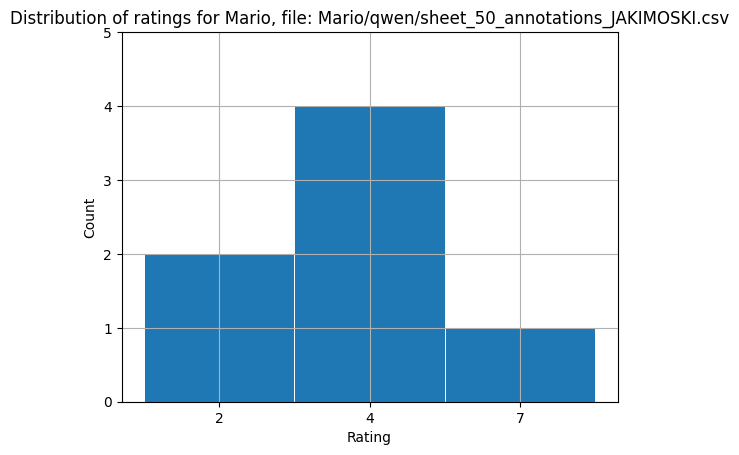

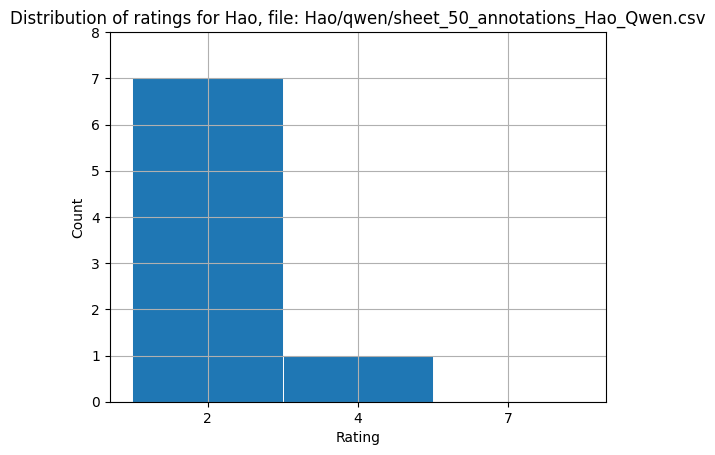

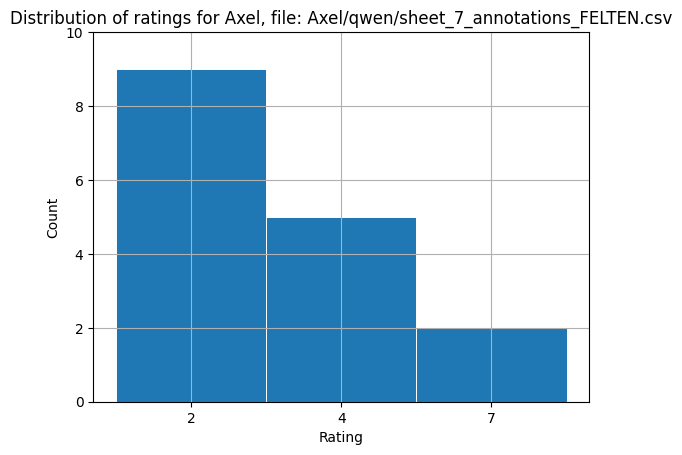

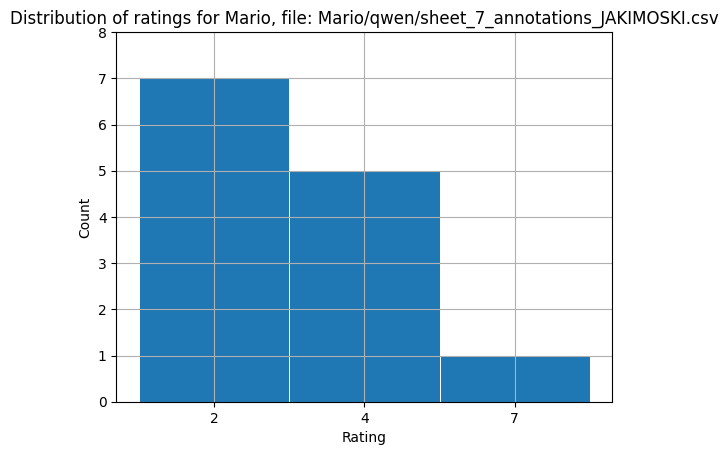

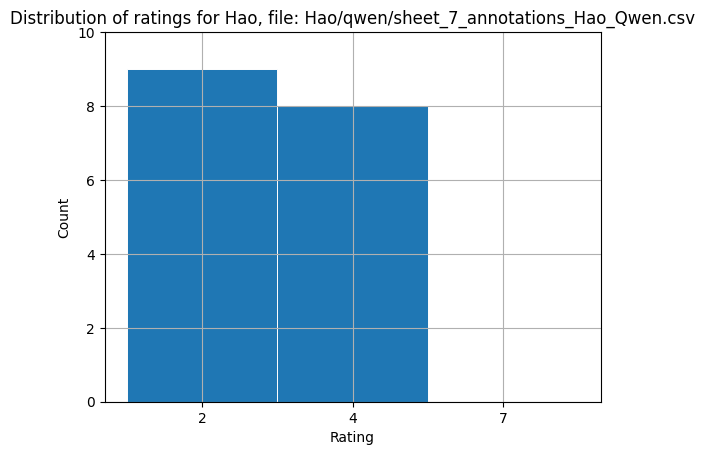

In [123]:
for file_a, file_m, file_h, in zip(file_path_axel, file_path_mario, file_path_hao):
    annotator_a, count_a = count_annotations(file_a, "Axel")
    DQS_A = {"2": count_a[2], "4": count_a[4], "7": count_a[7]}
    annotator_m, count_m = count_annotations(file_m, "Mario")
    DQS_M = {"2": count_m[2], "4": count_m[4], "7": count_m[7]}
    annotator_h, count_h = count_annotations(file_h, "Hao")
    DQS_H = {"2": count_h[2], "4": count_h[4], "7": count_h[7]}

    bar_plot_function(list(DQS_A.keys()), list(DQS_A.values()), "Rating", "Count", f"Distribution of ratings for Axel, file: {file_a}")
    bar_plot_function(list(DQS_M.keys()), list(DQS_M.values()), "Rating", "Count", f"Distribution of ratings for Mario, file: {file_m}")
    bar_plot_function(list(DQS_H.keys()), list(DQS_H.values()), "Rating", "Count", f"Distribution of ratings for Hao, file: {file_h}")

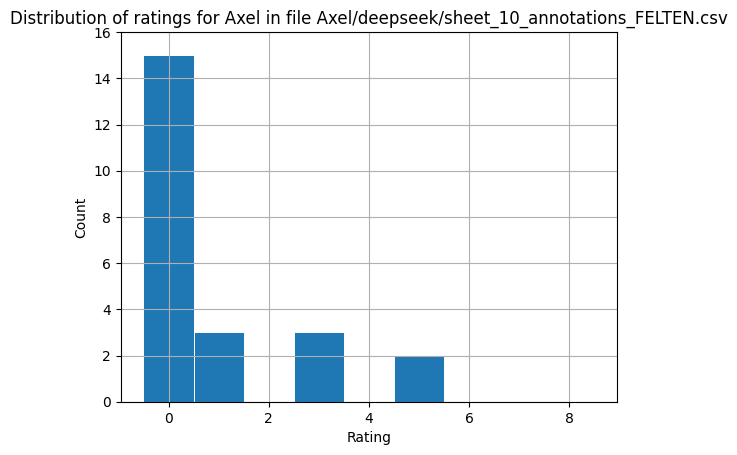

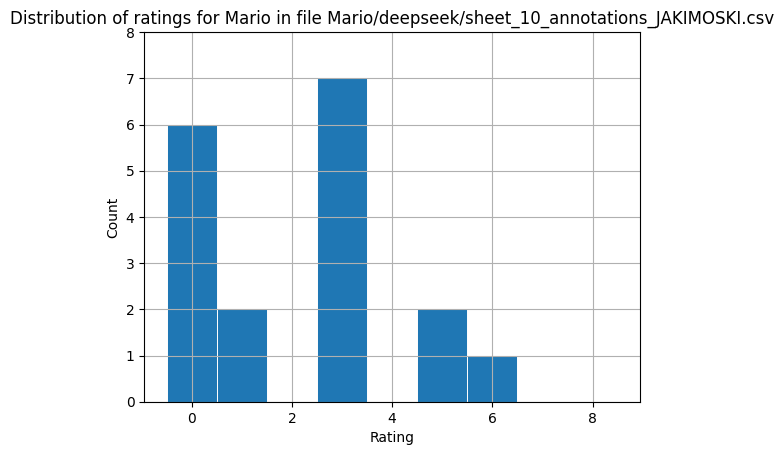

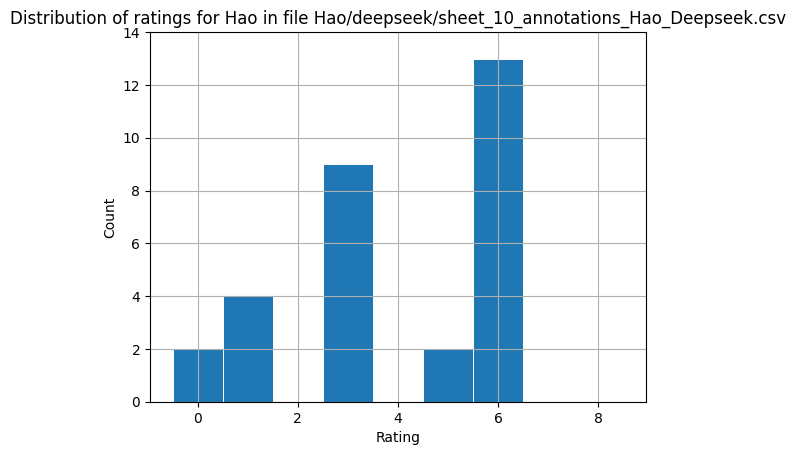

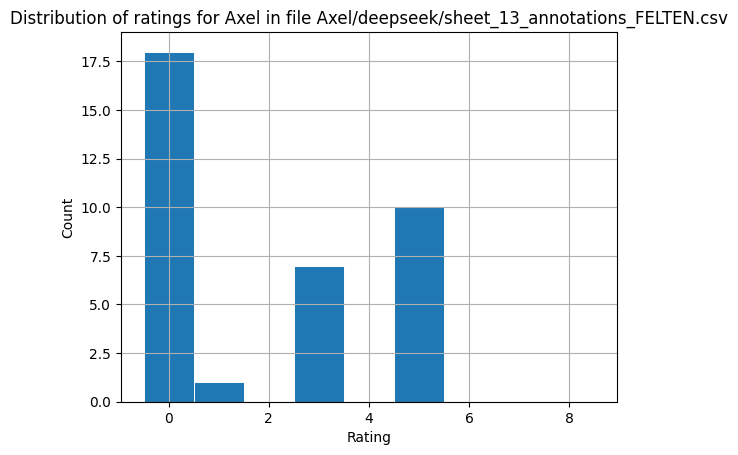

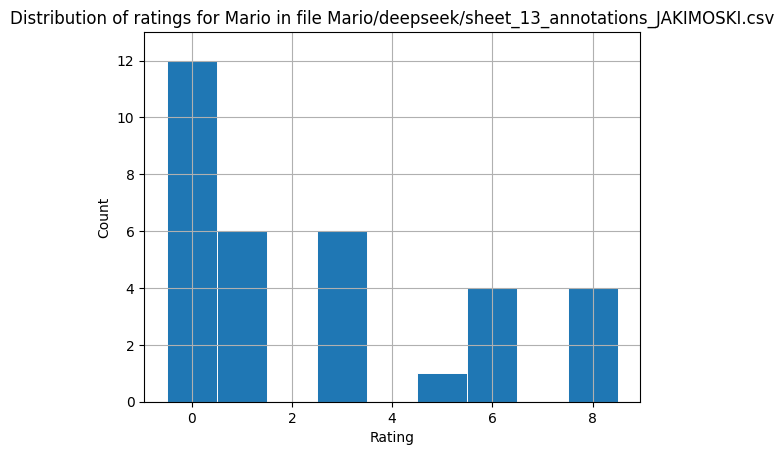

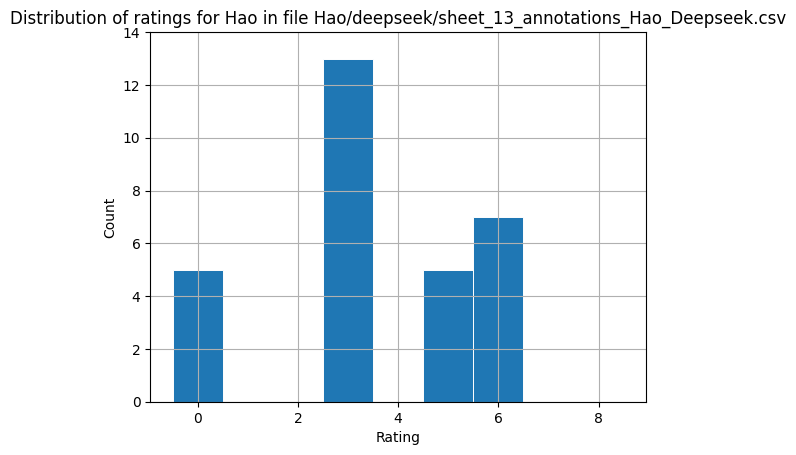

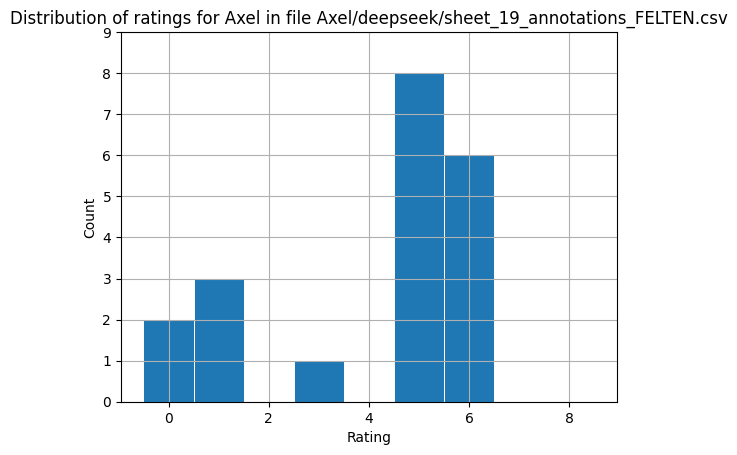

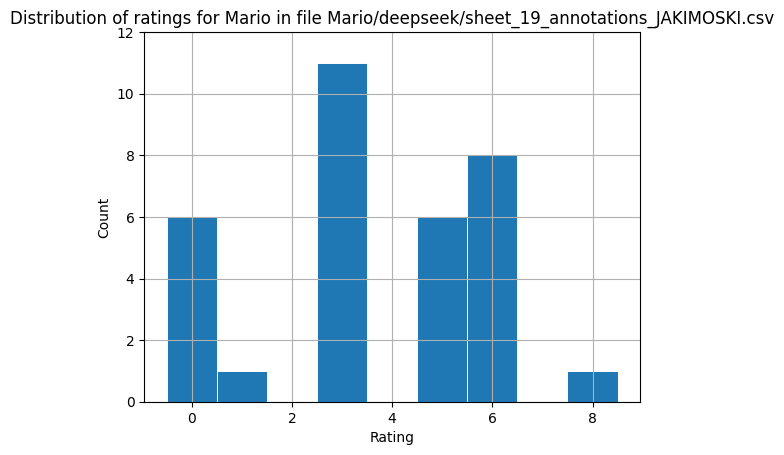

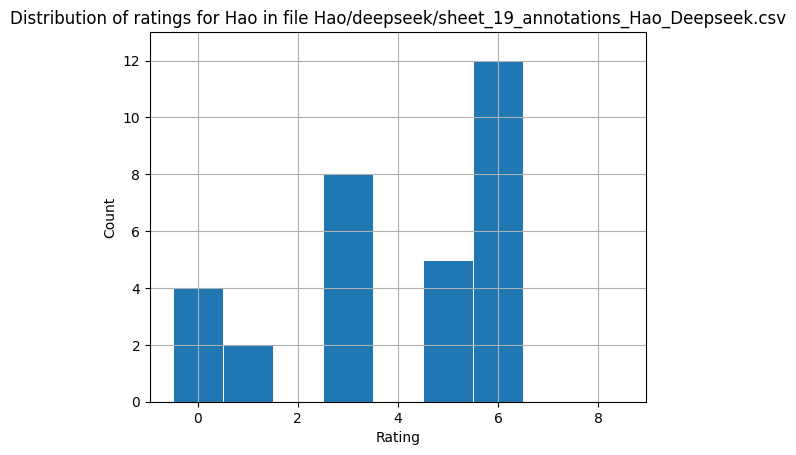

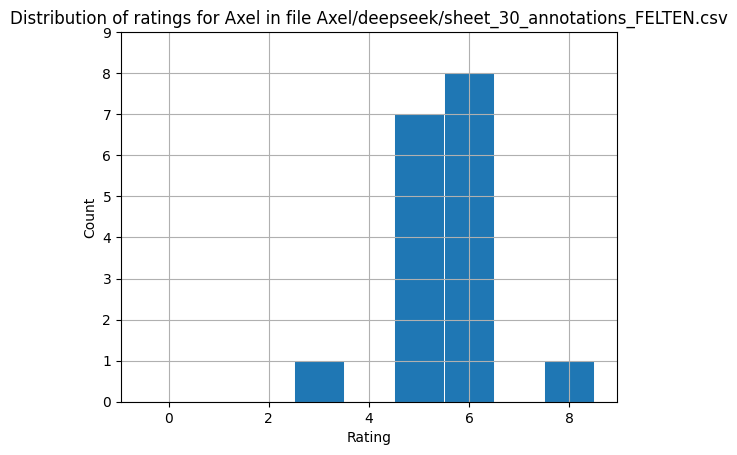

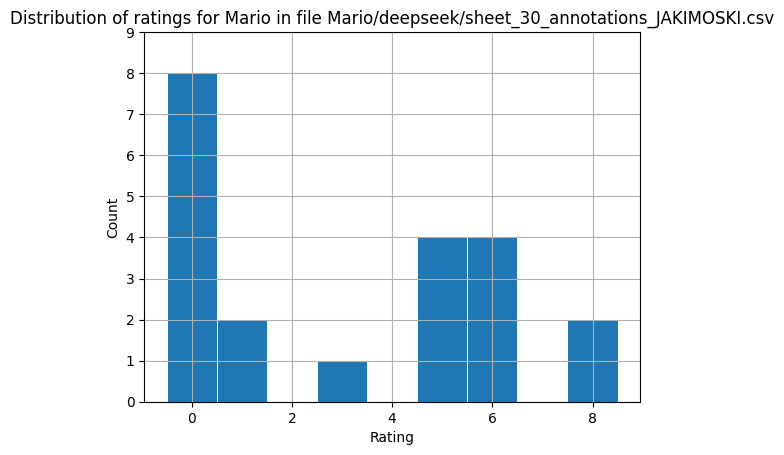

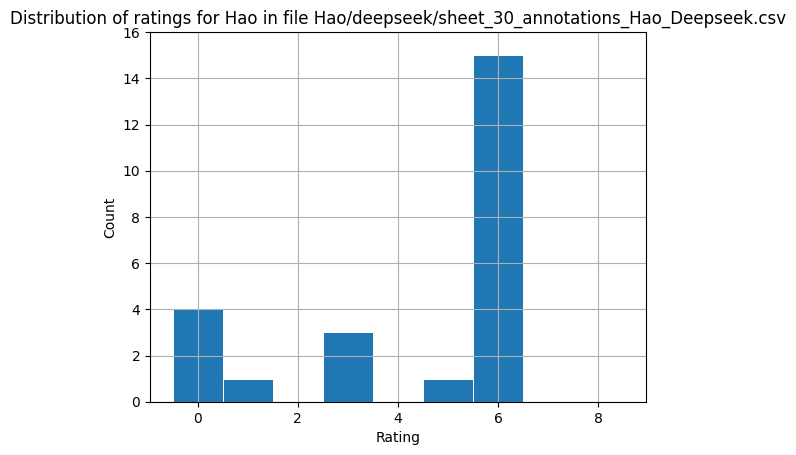

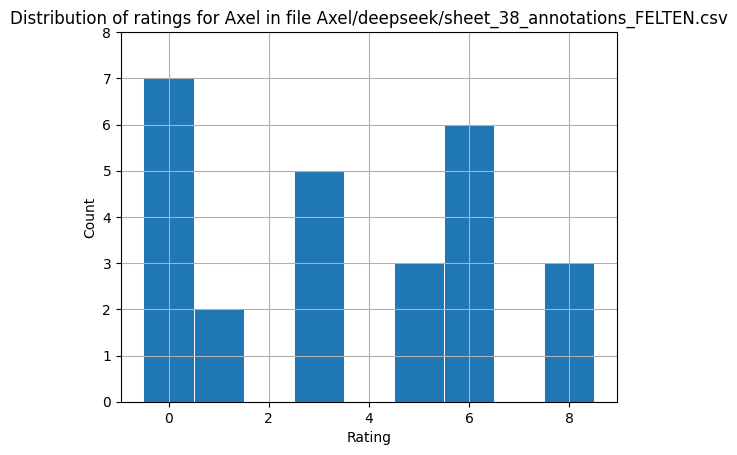

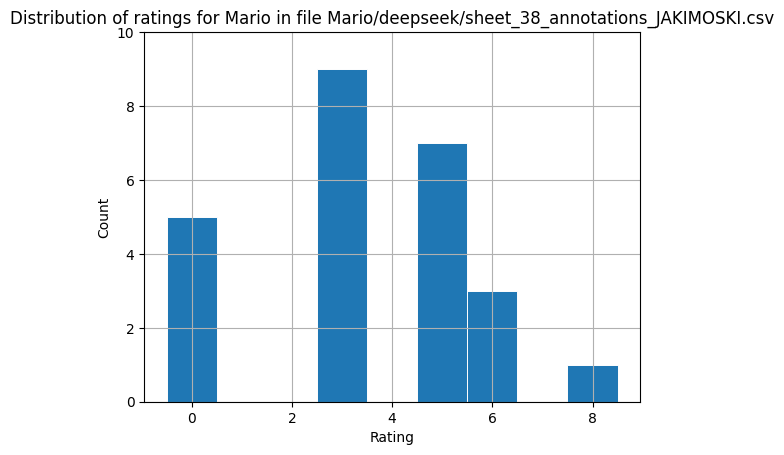

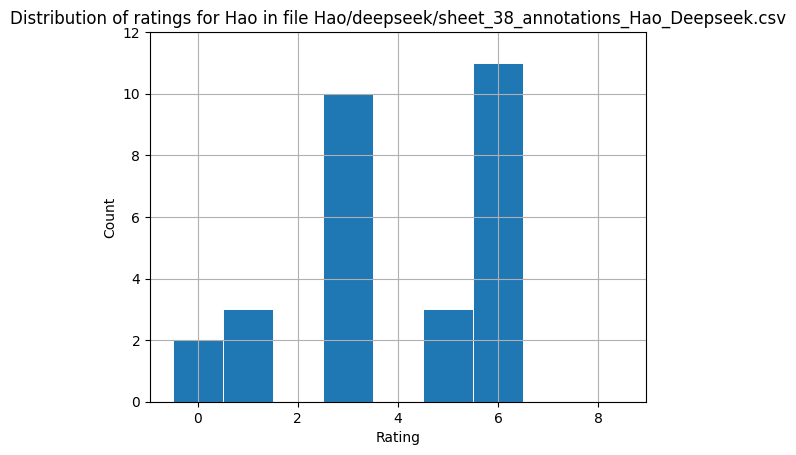

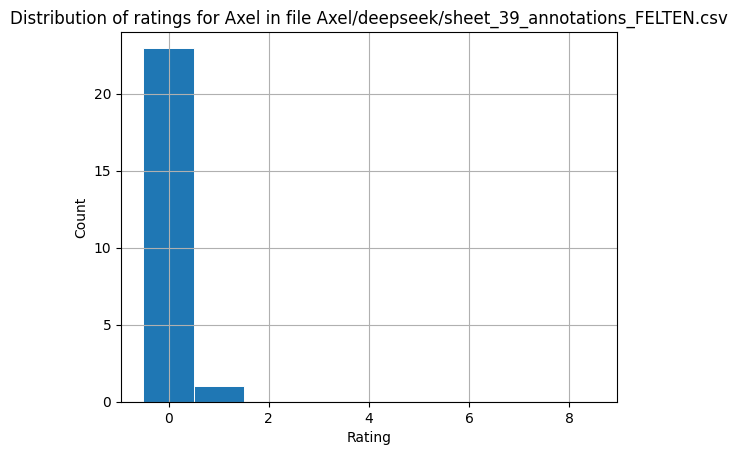

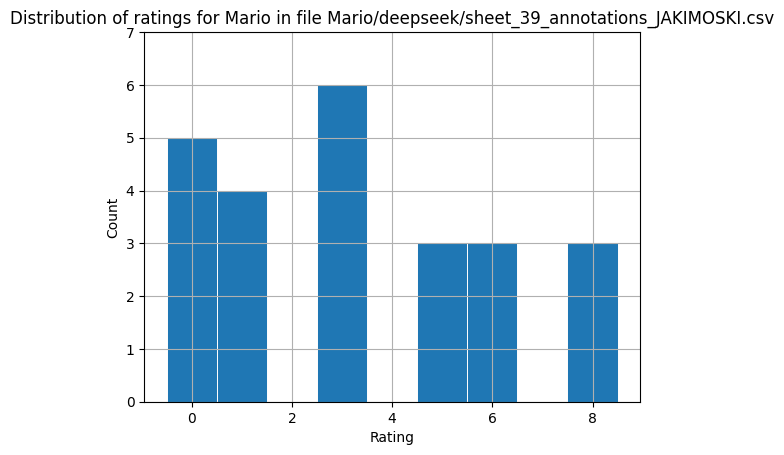

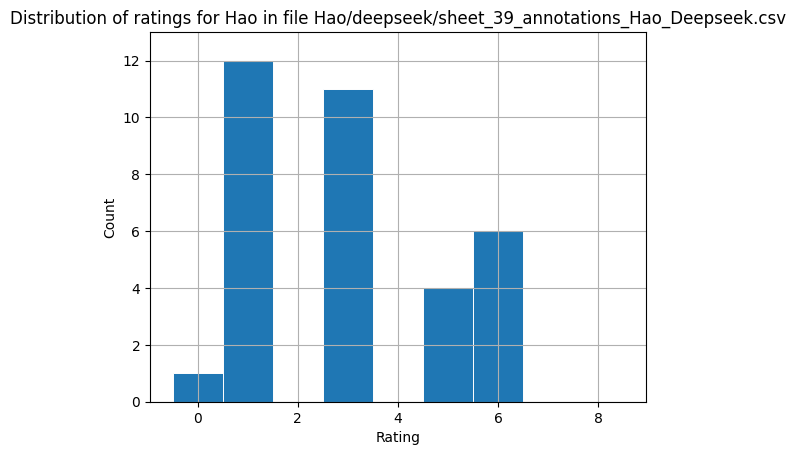

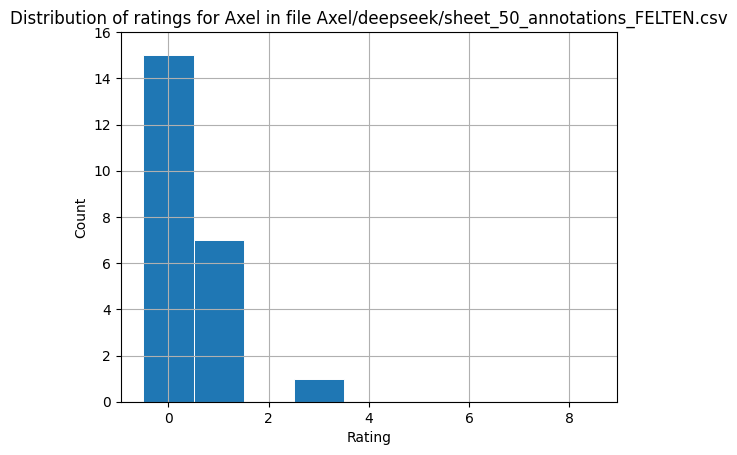

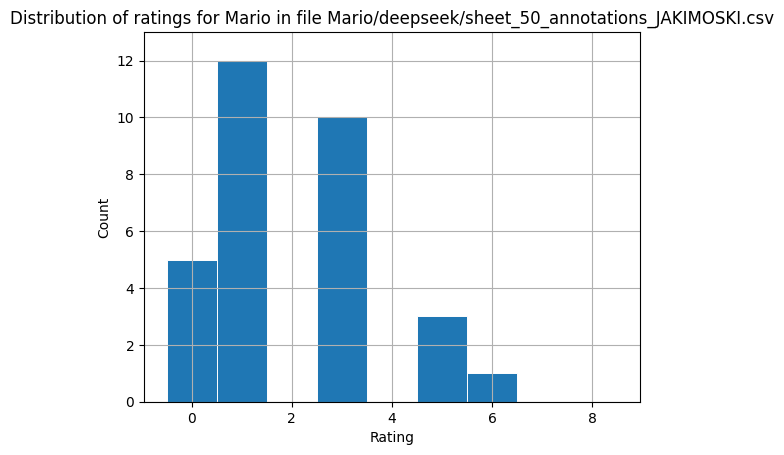

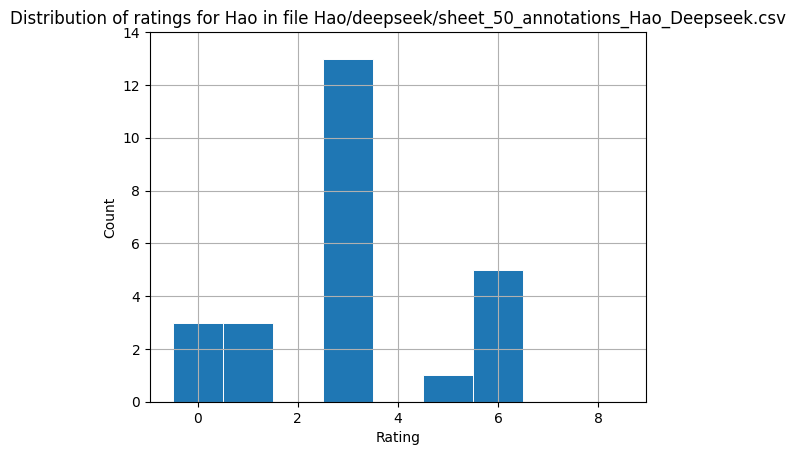

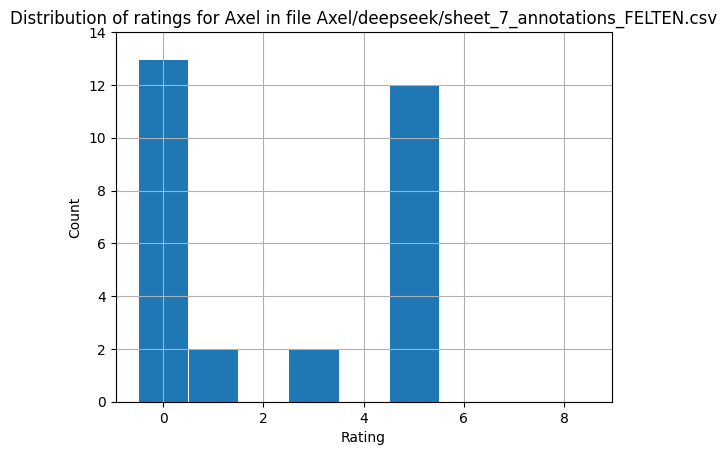

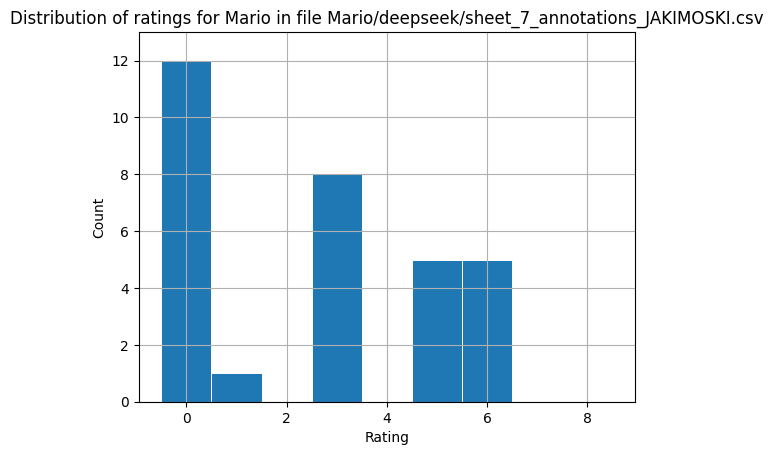

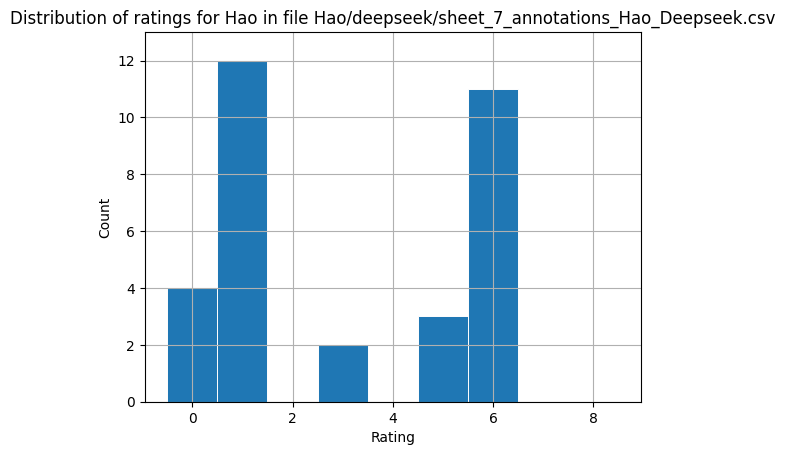

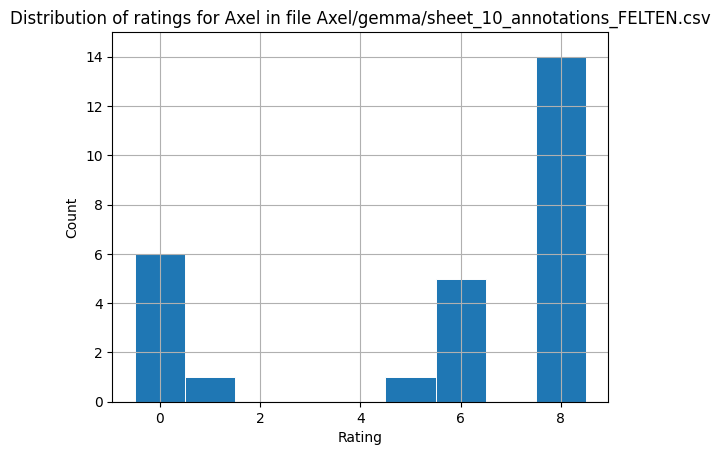

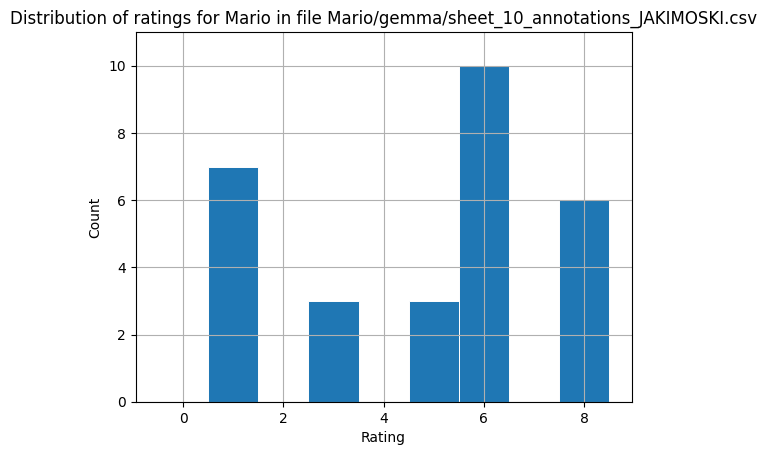

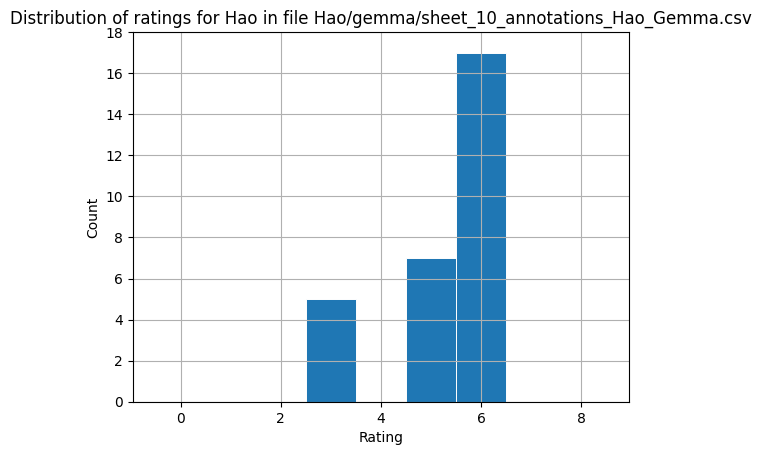

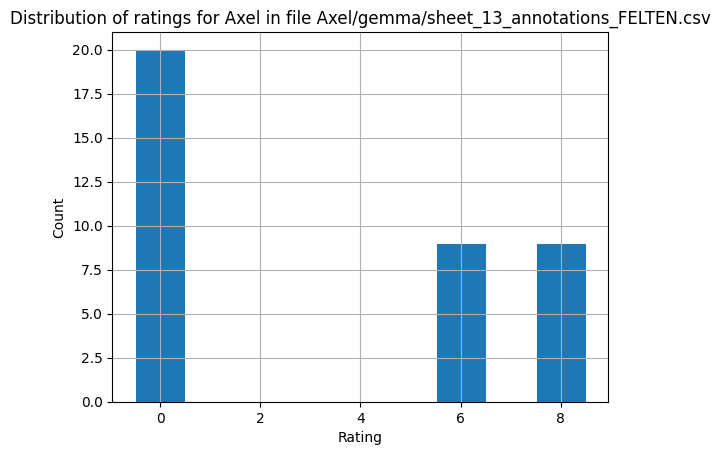

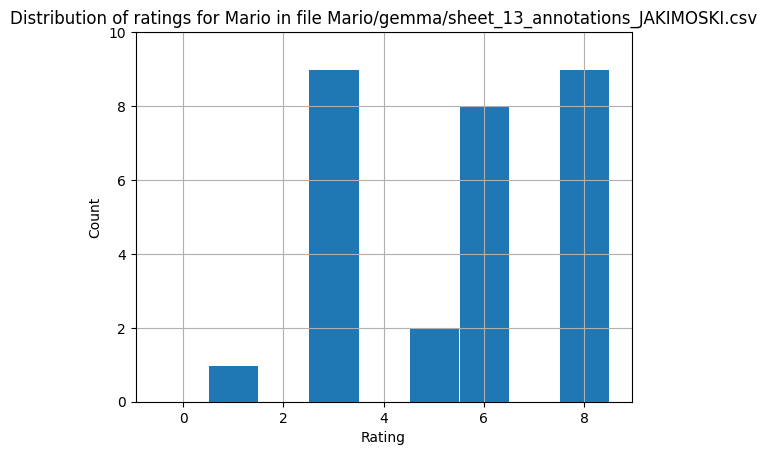

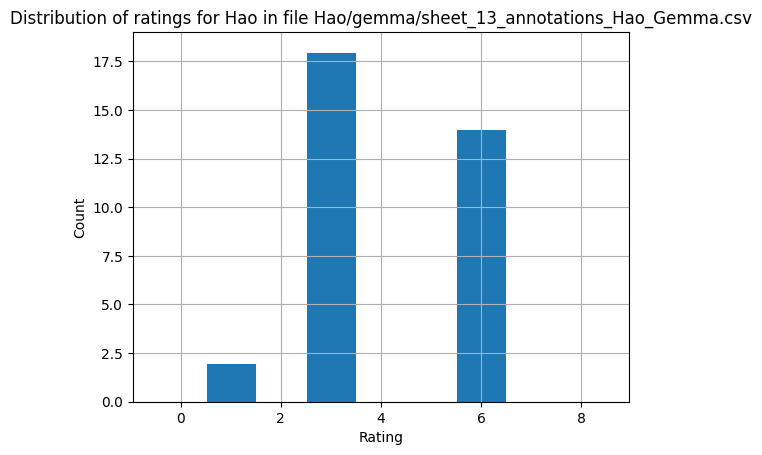

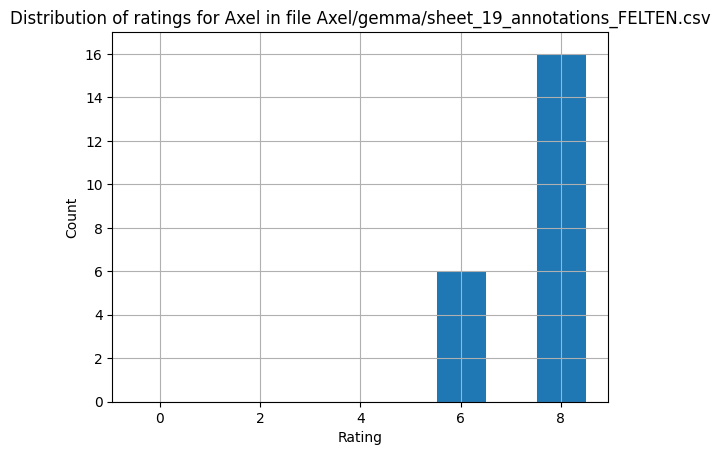

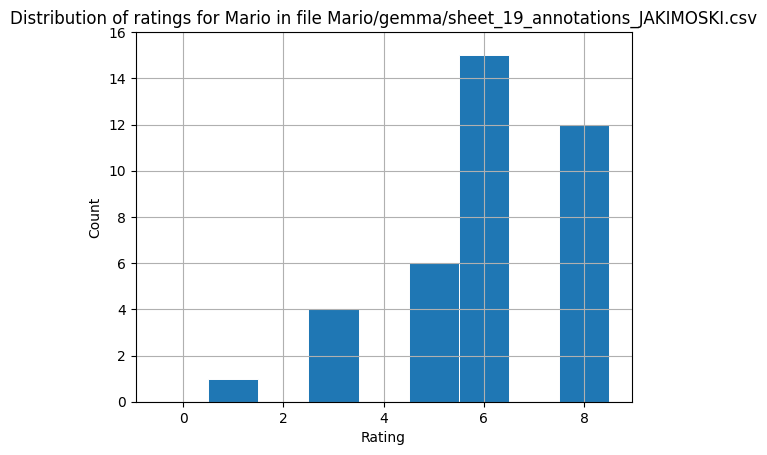

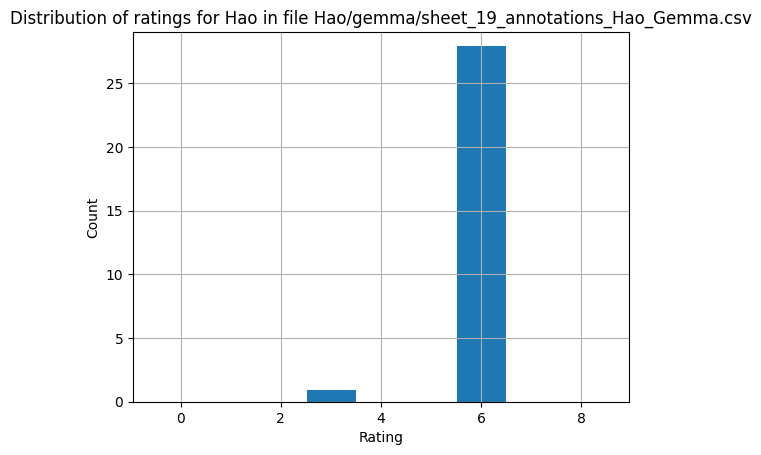

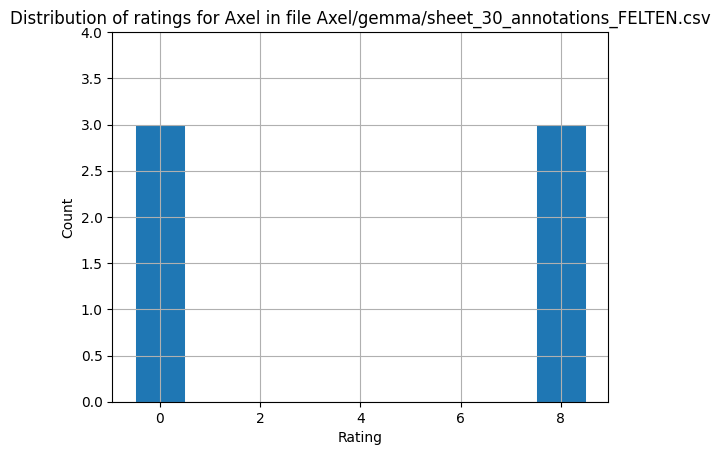

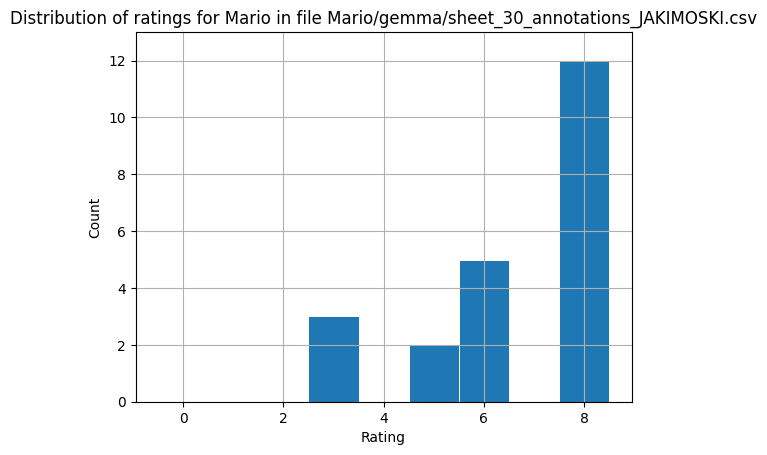

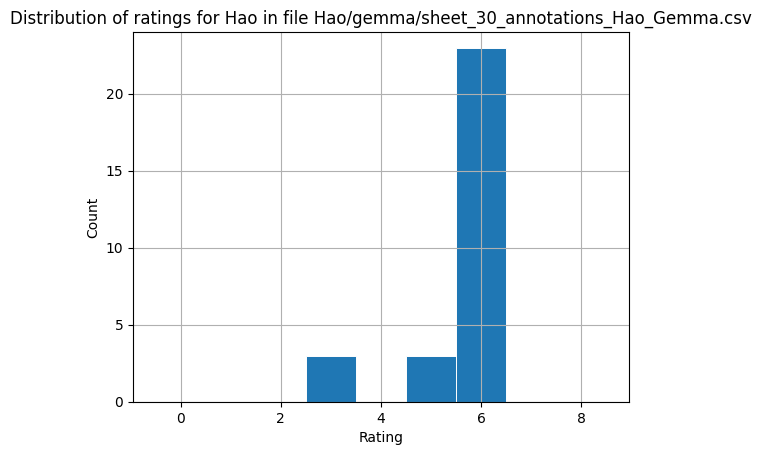

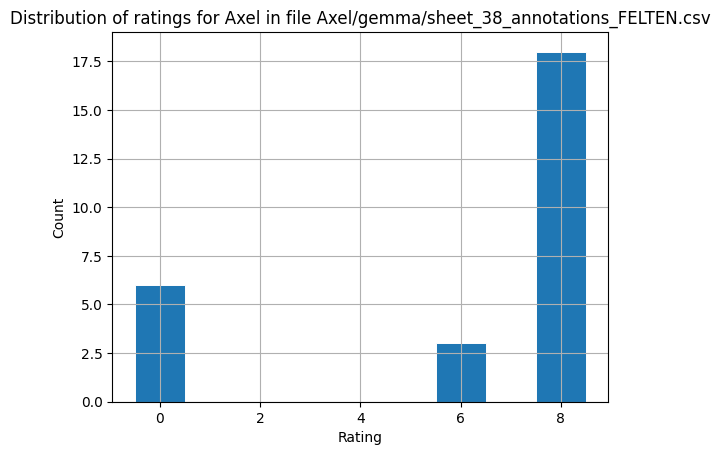

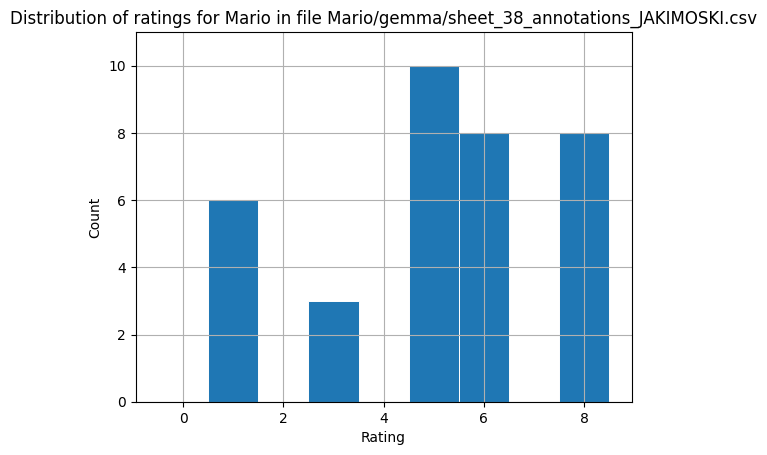

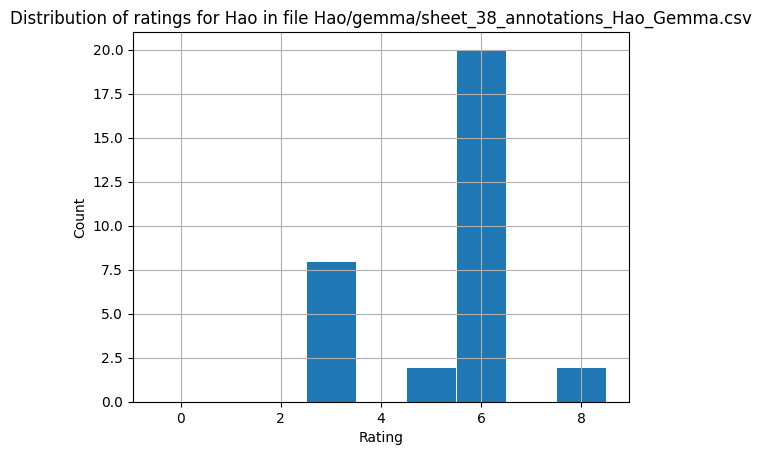

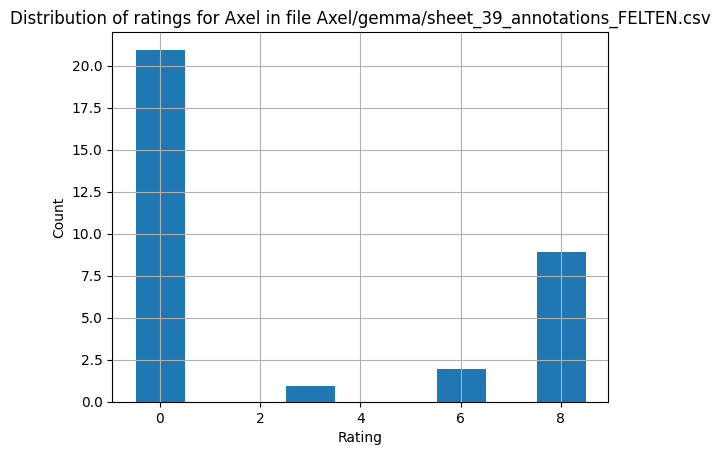

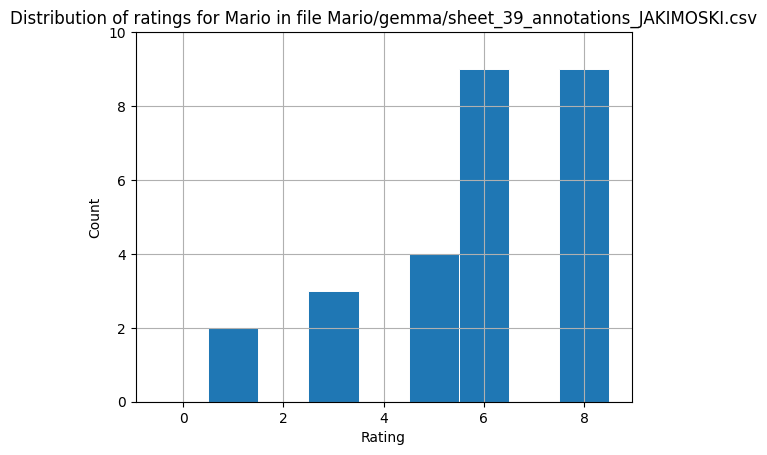

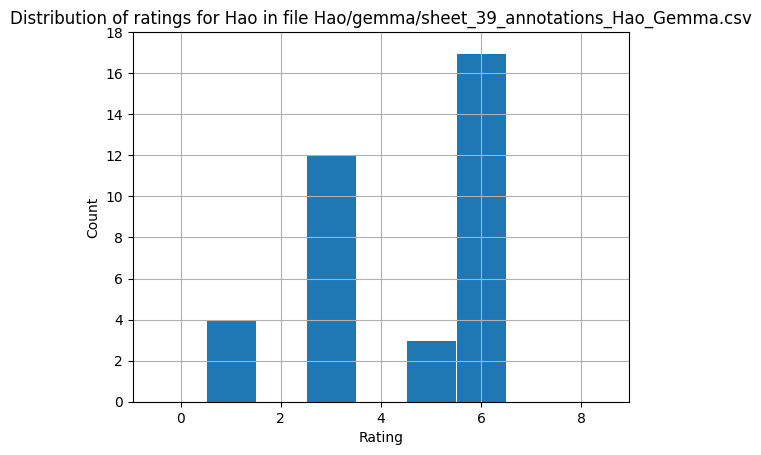

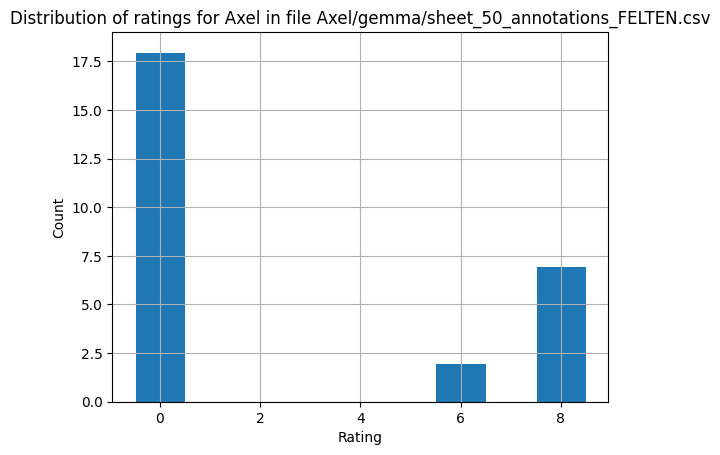

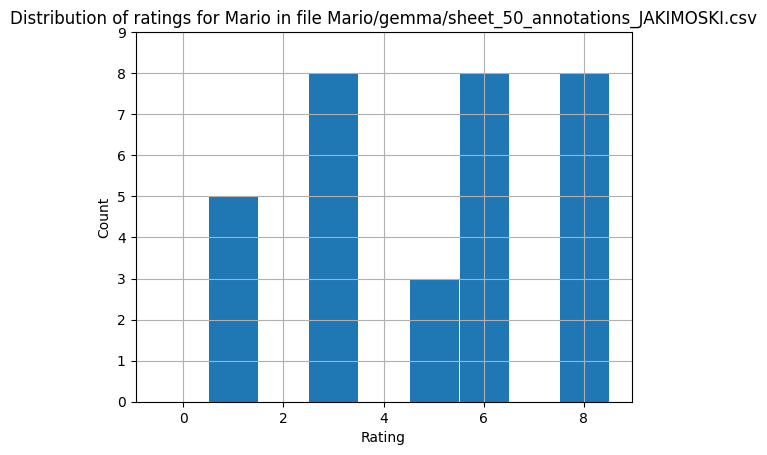

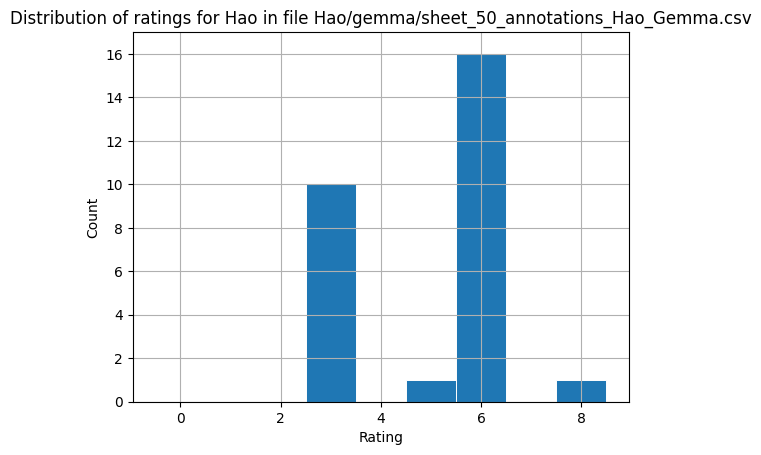

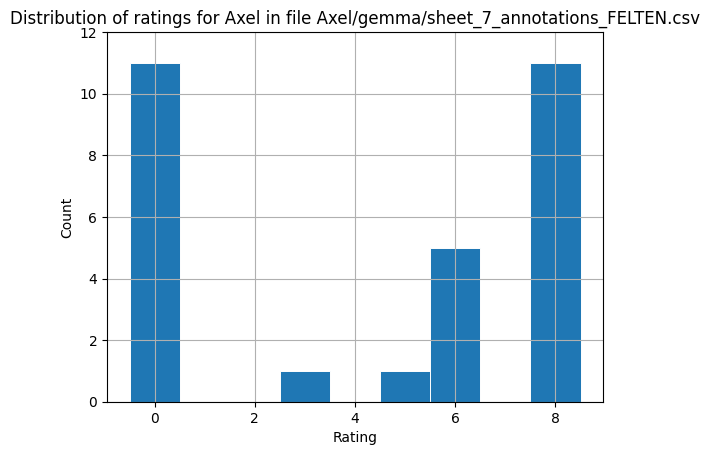

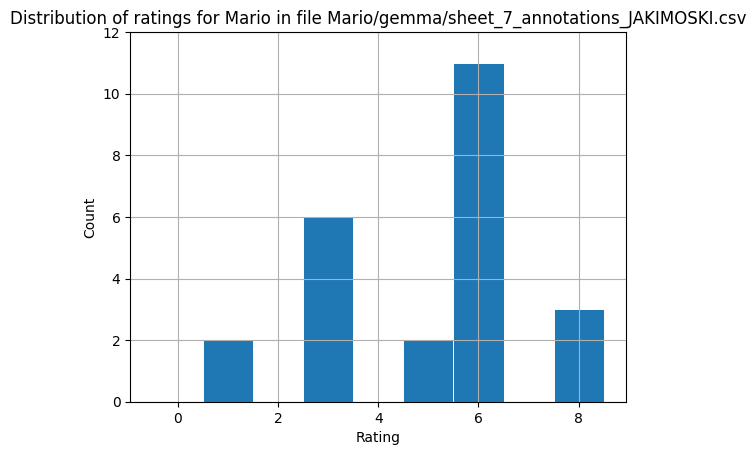

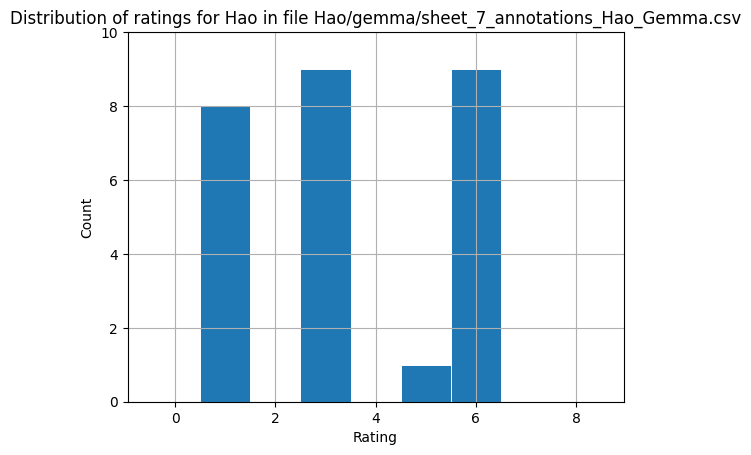

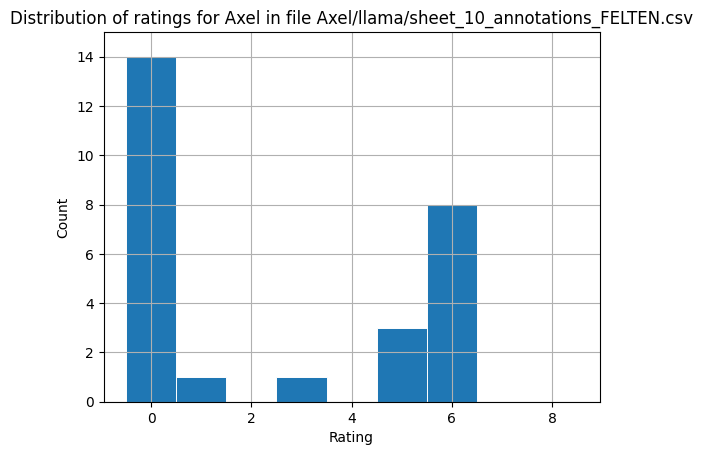

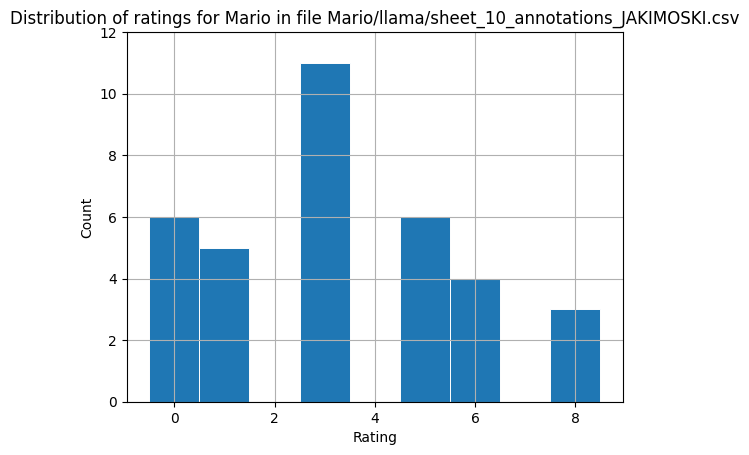

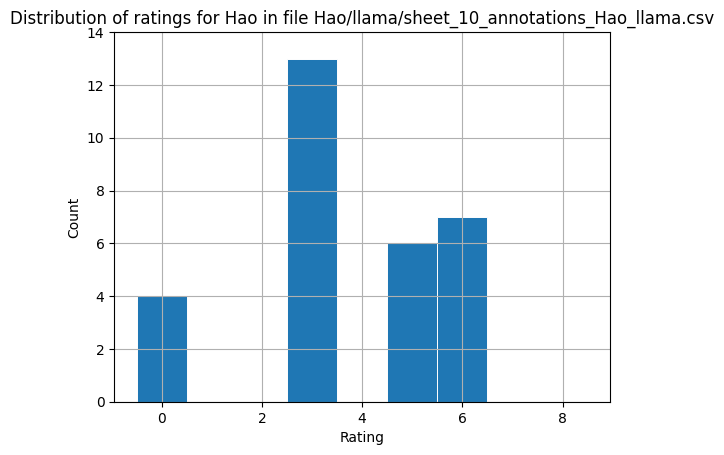

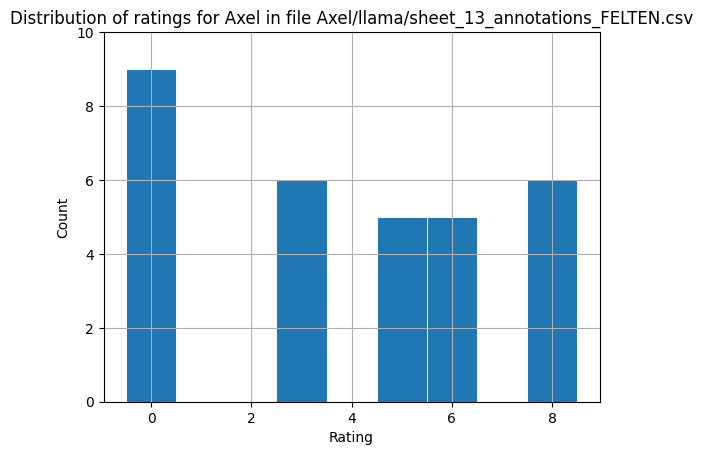

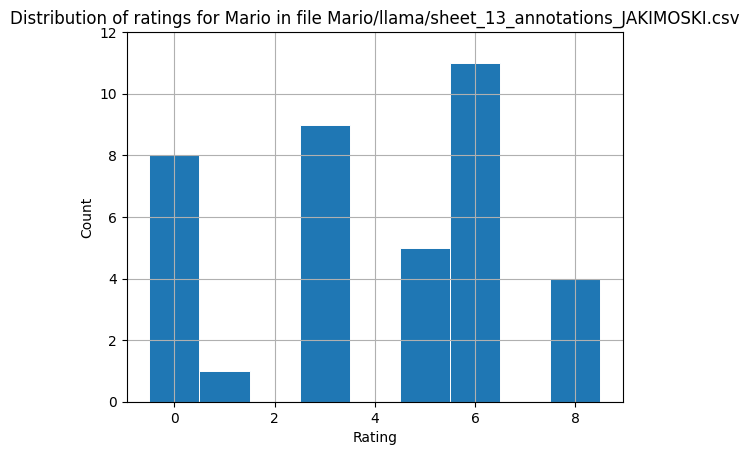

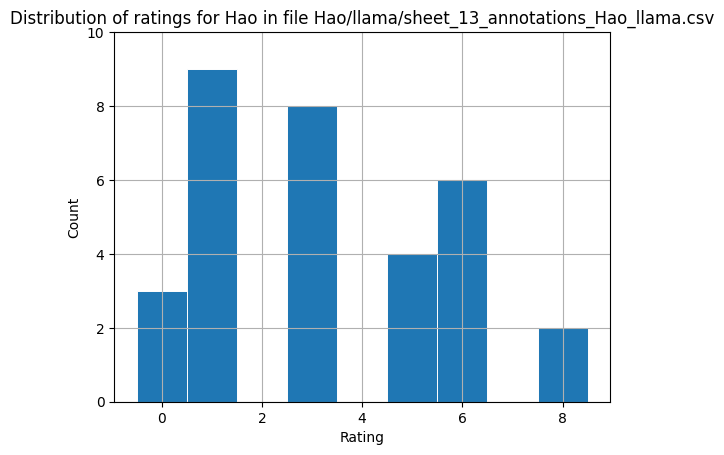

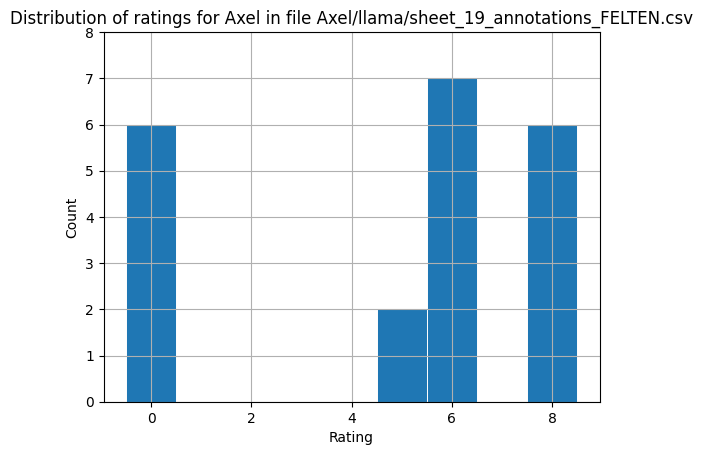

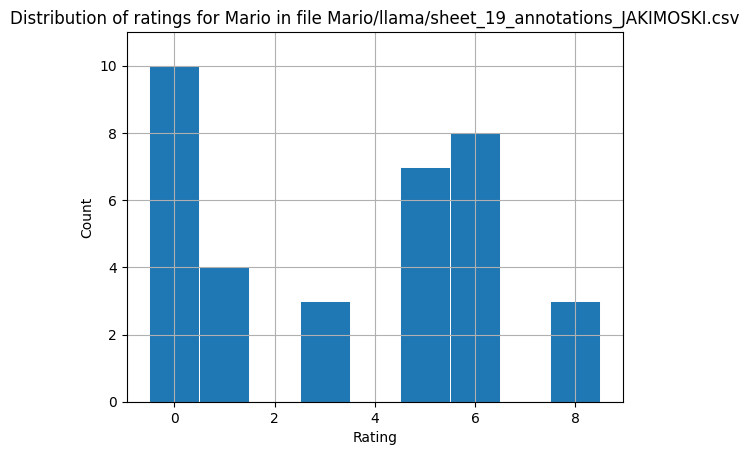

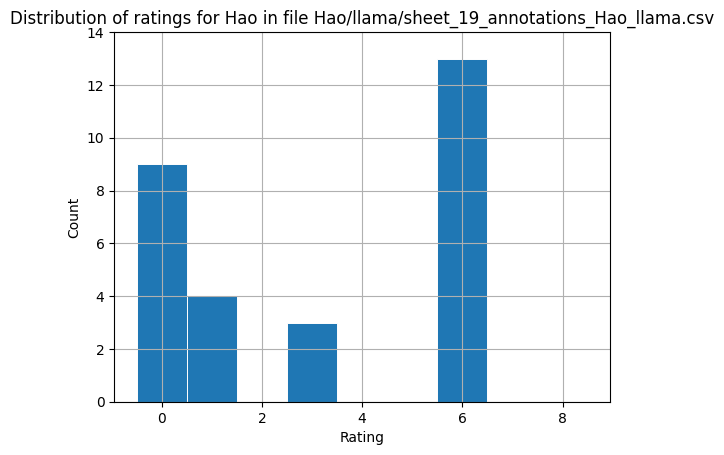

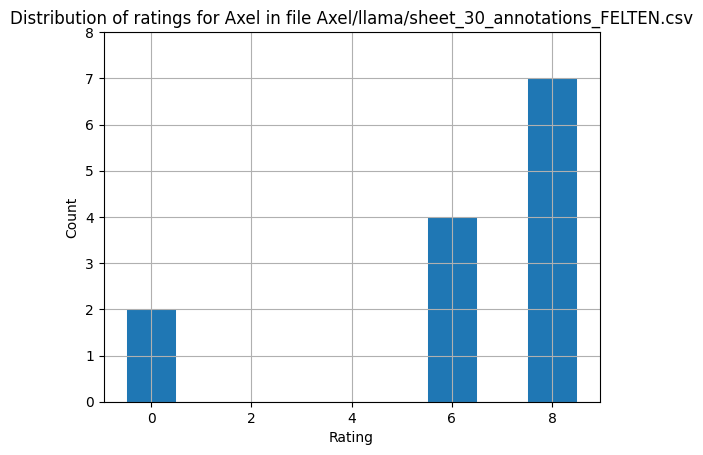

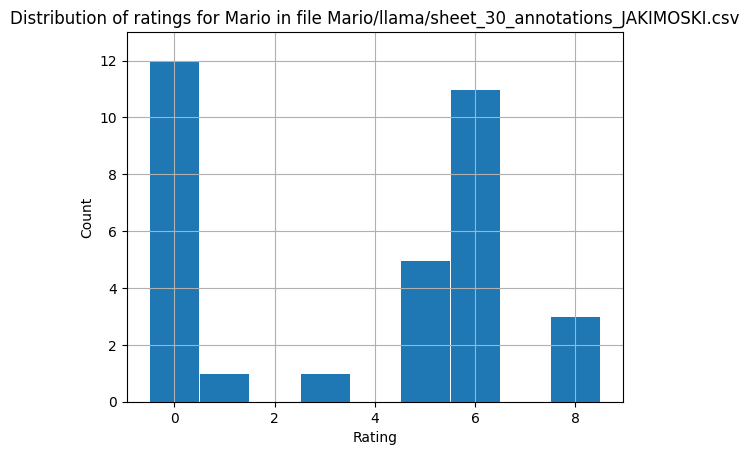

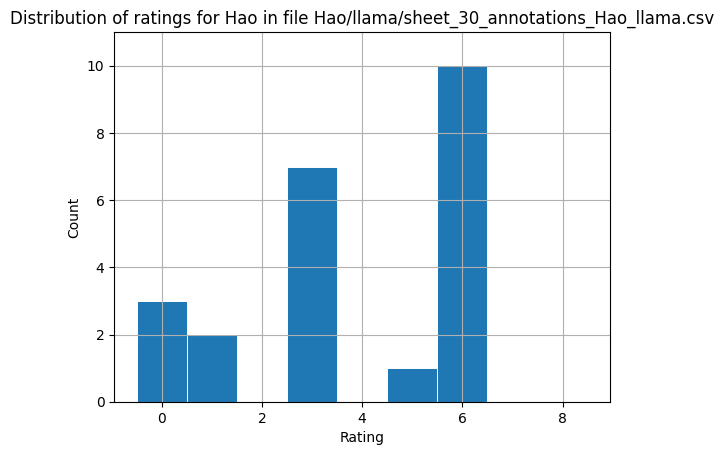

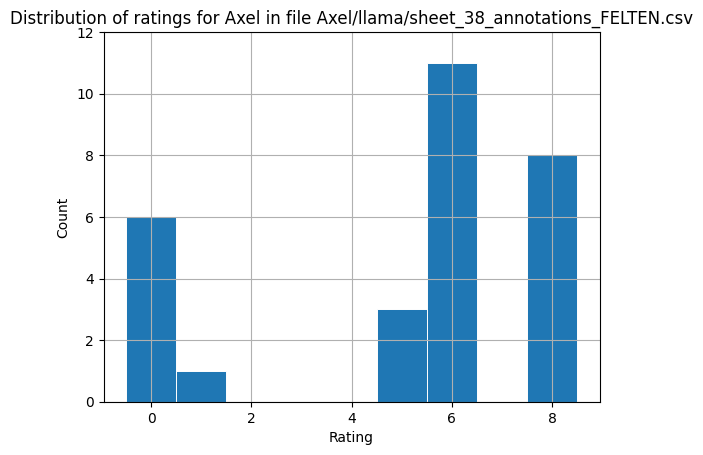

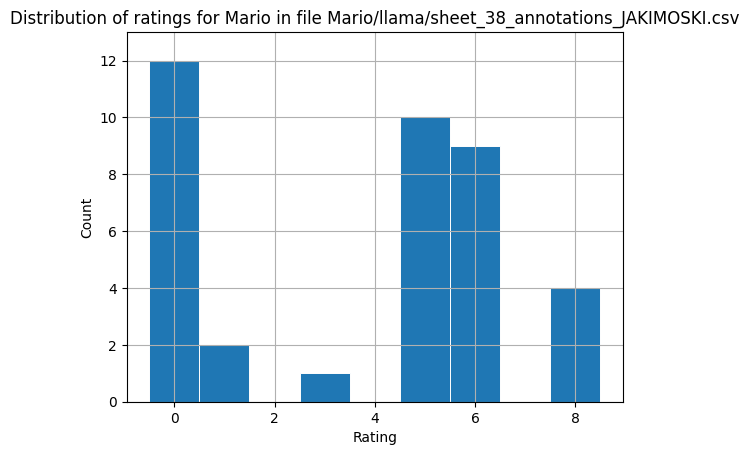

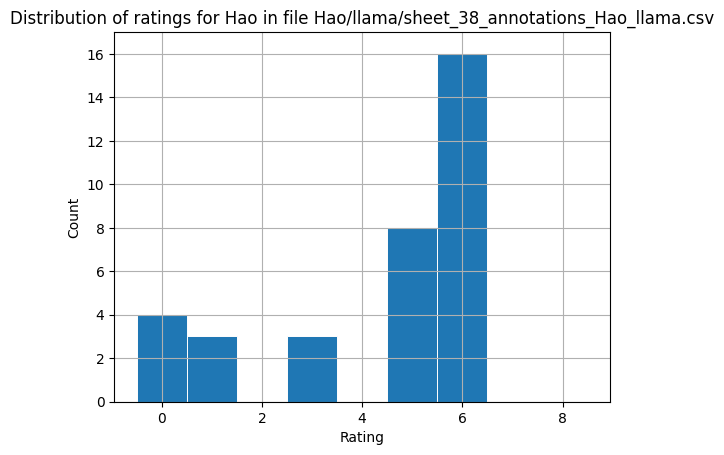

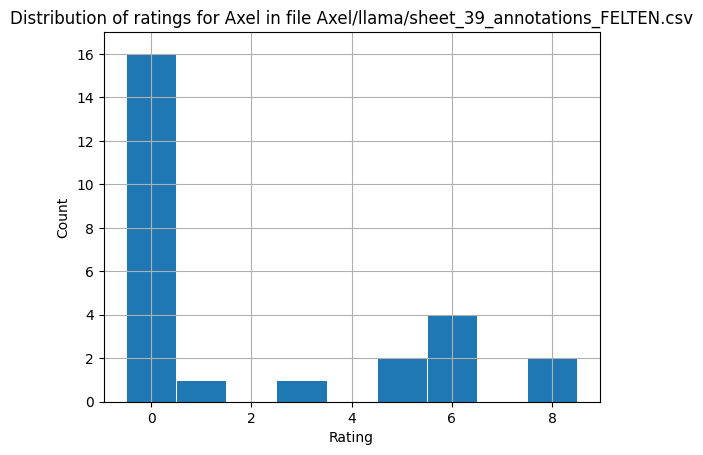

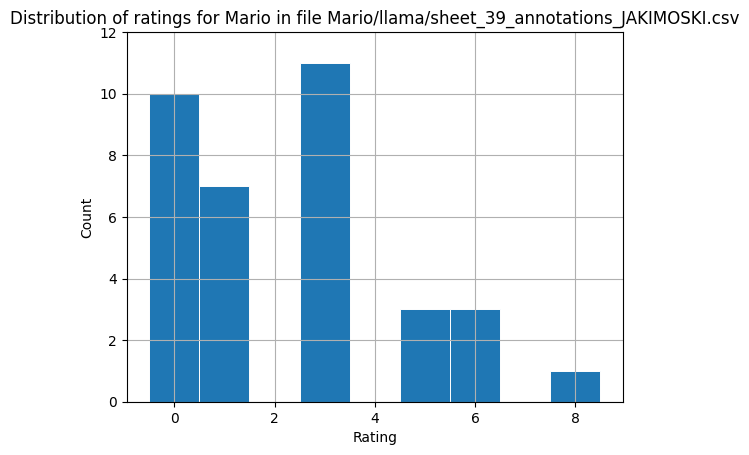

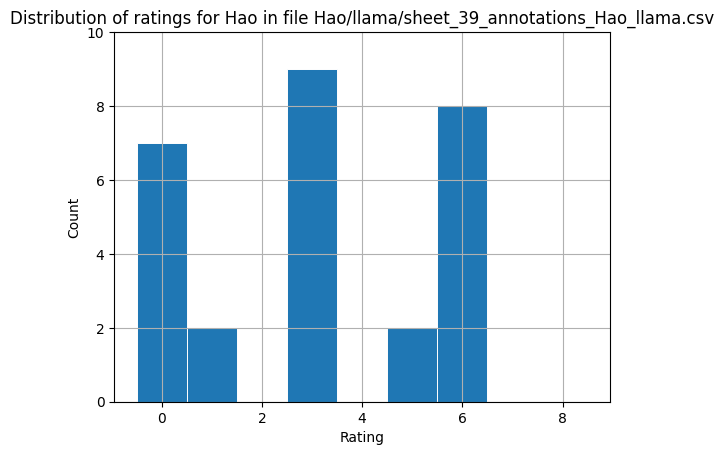

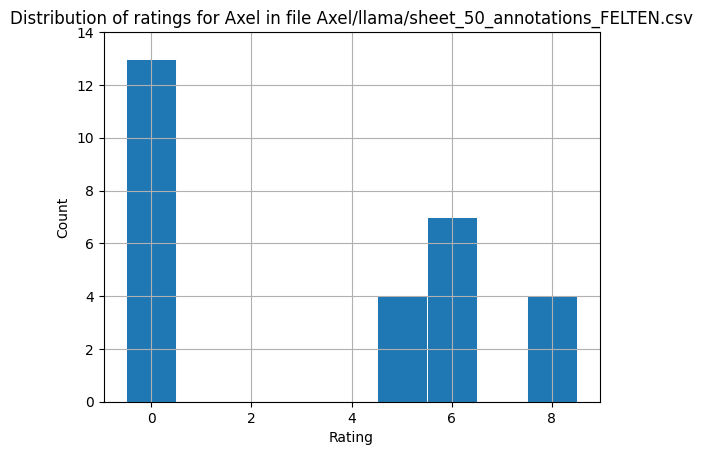

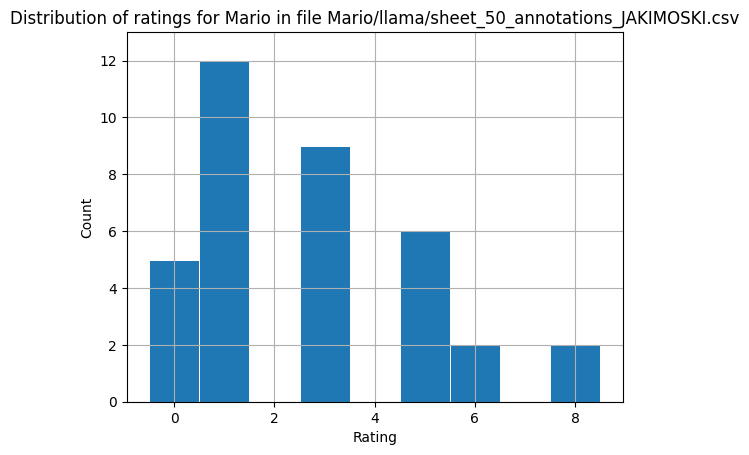

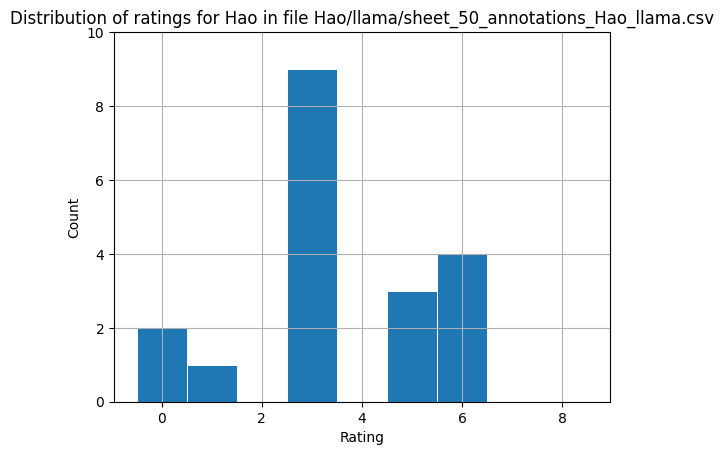

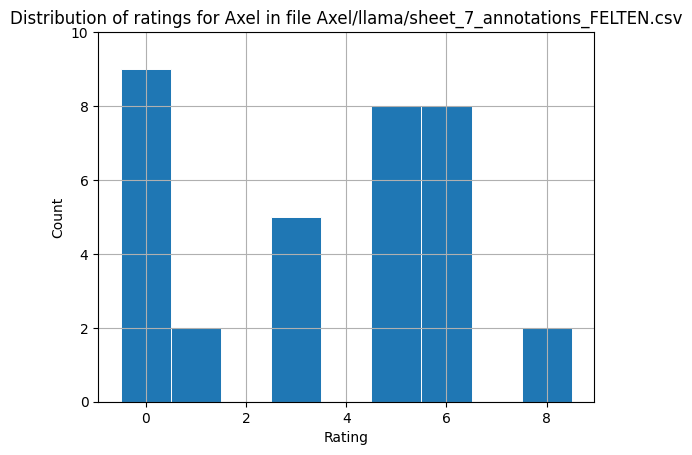

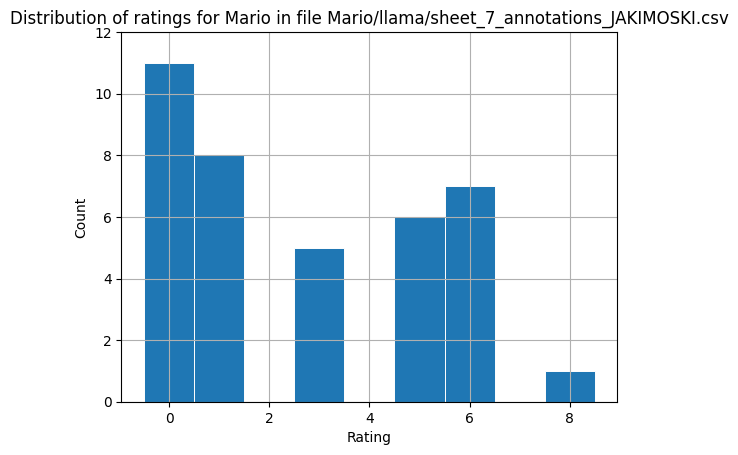

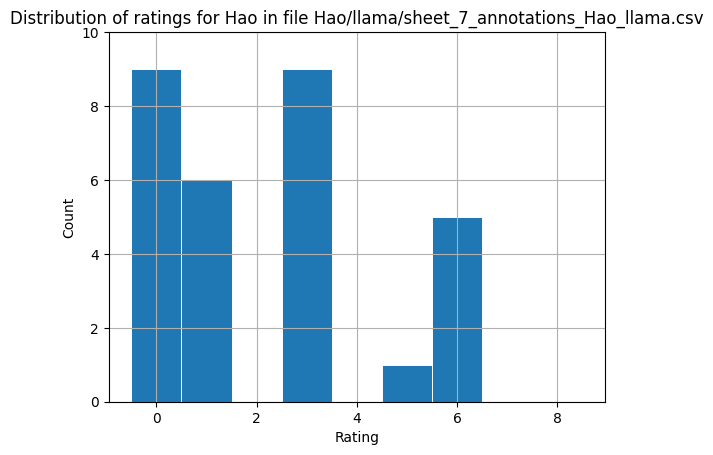

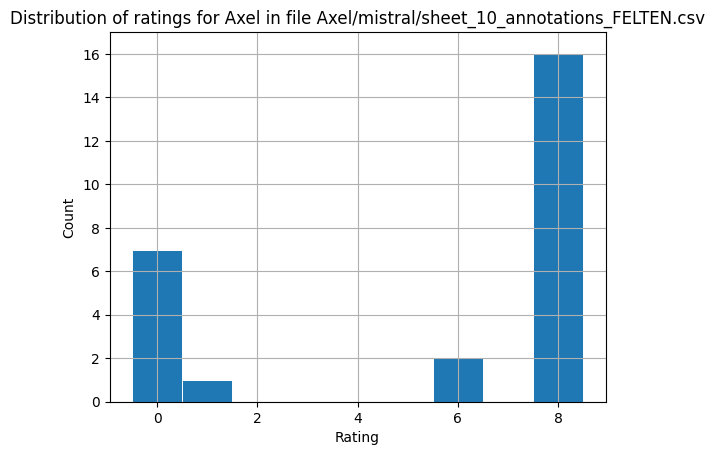

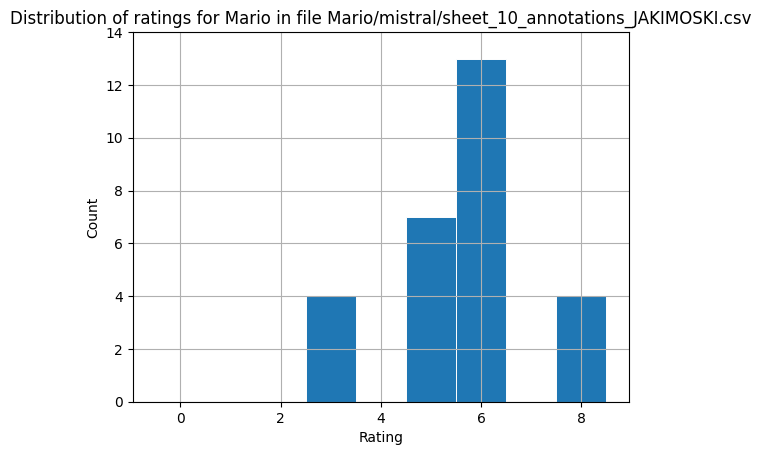

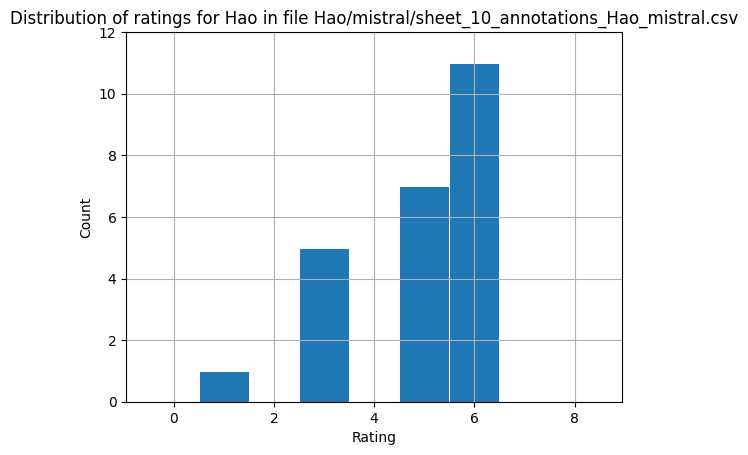

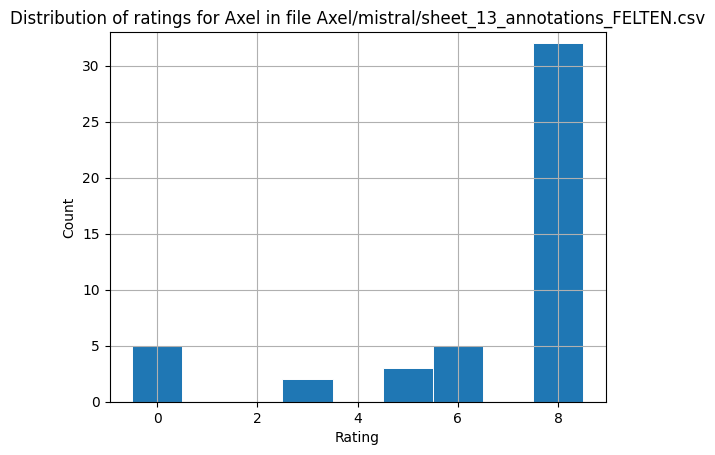

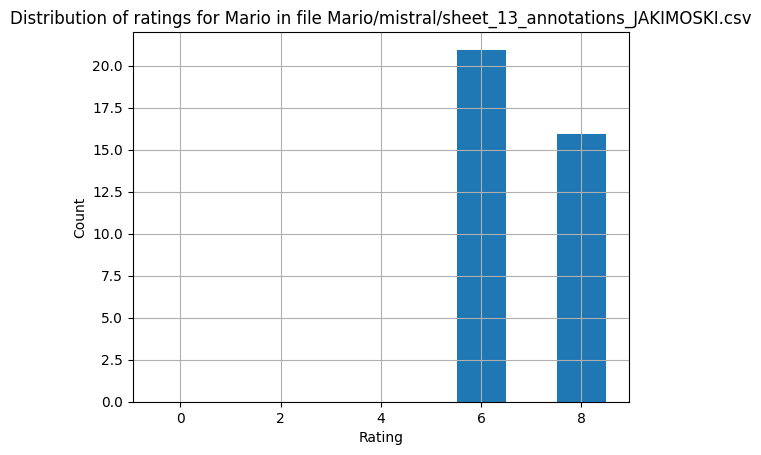

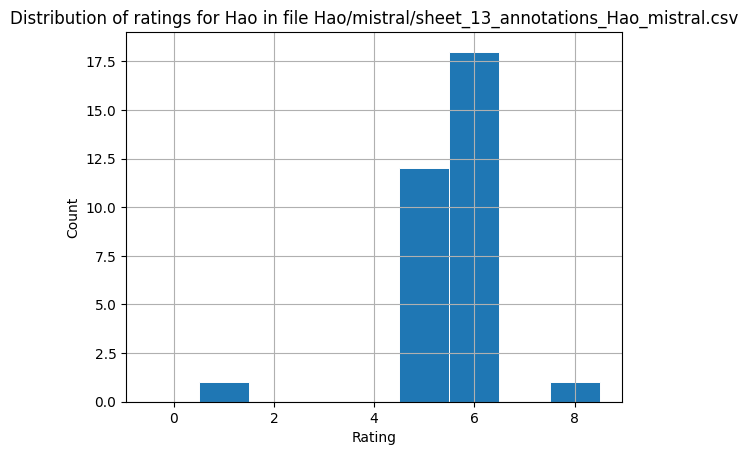

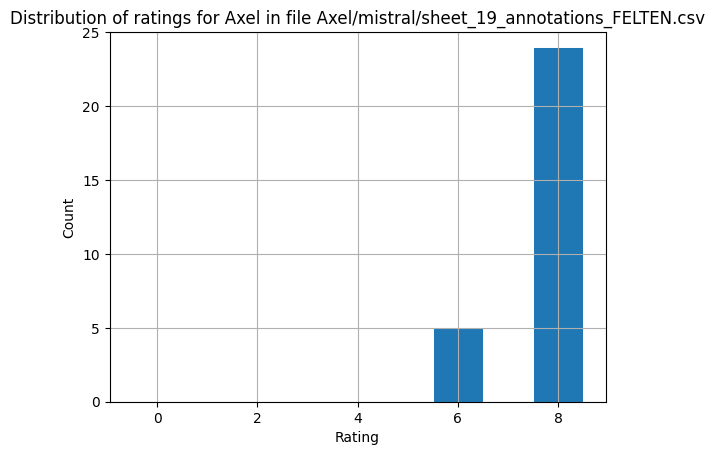

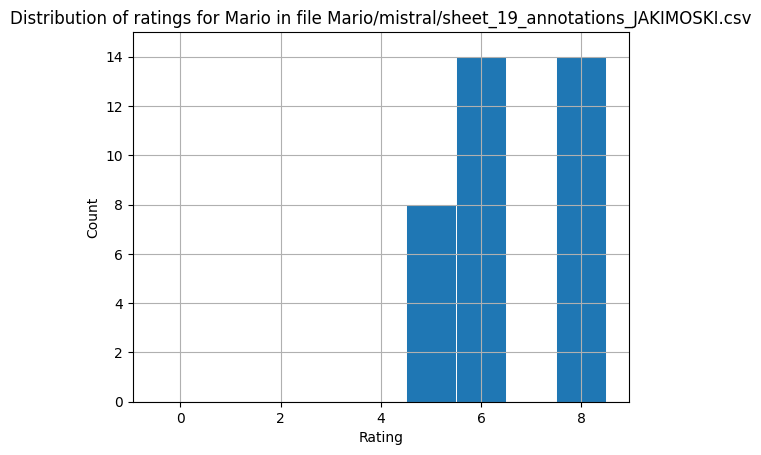

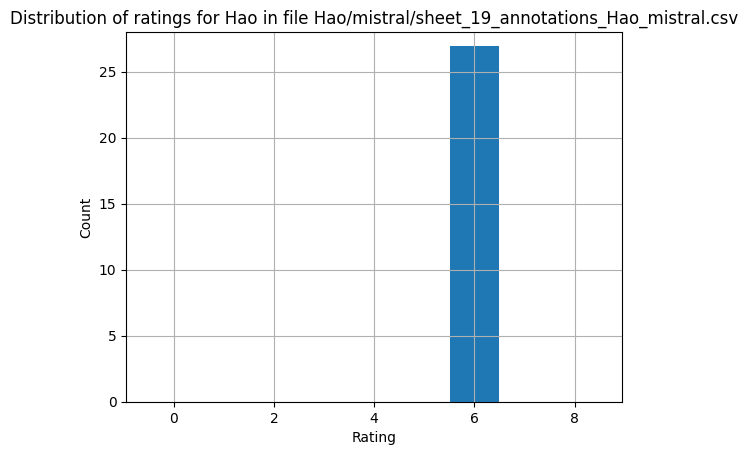

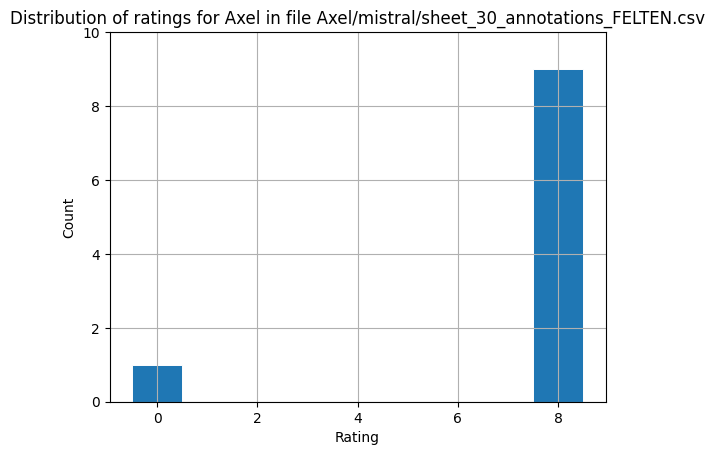

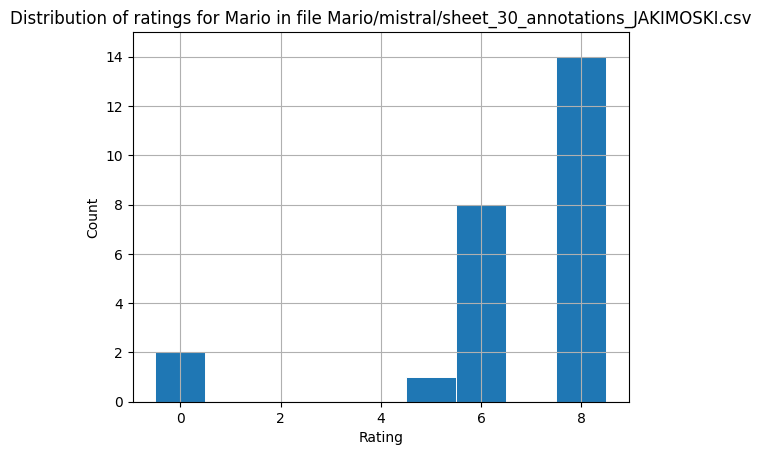

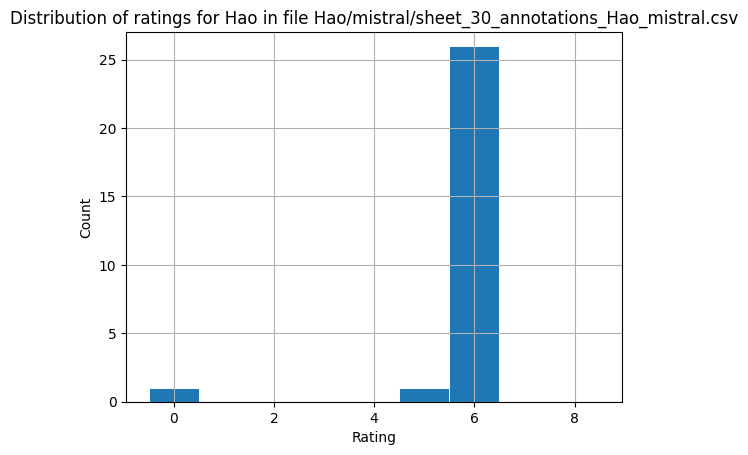

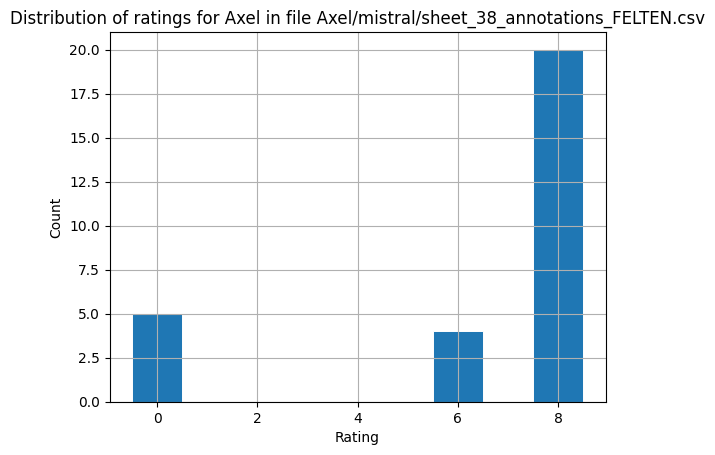

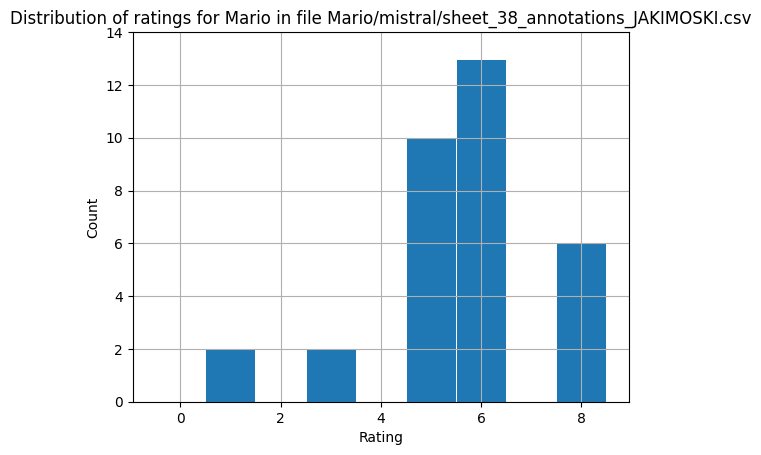

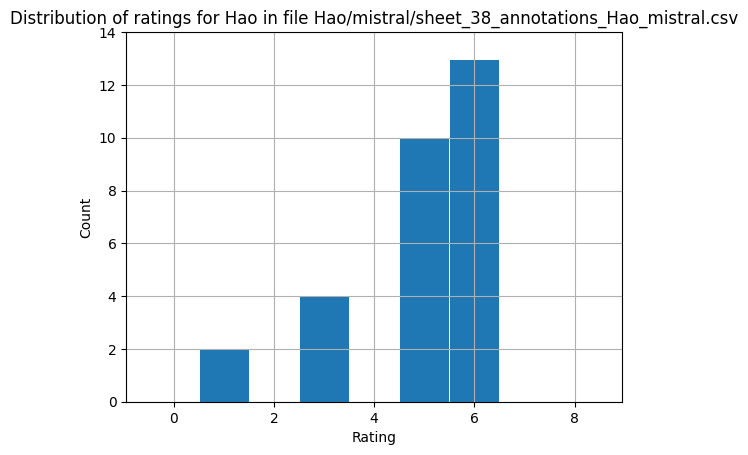

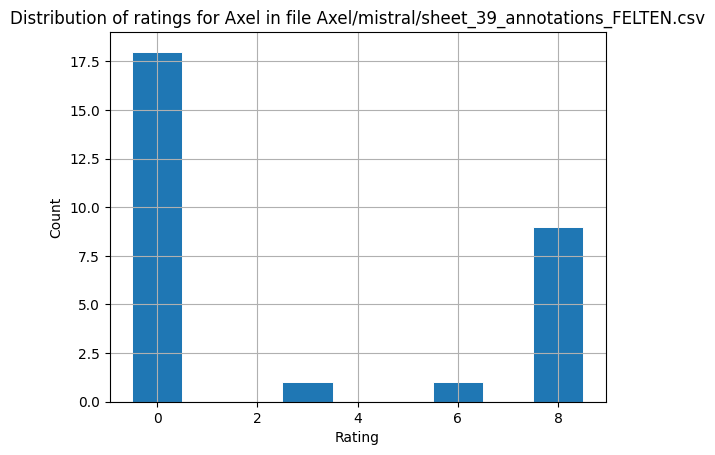

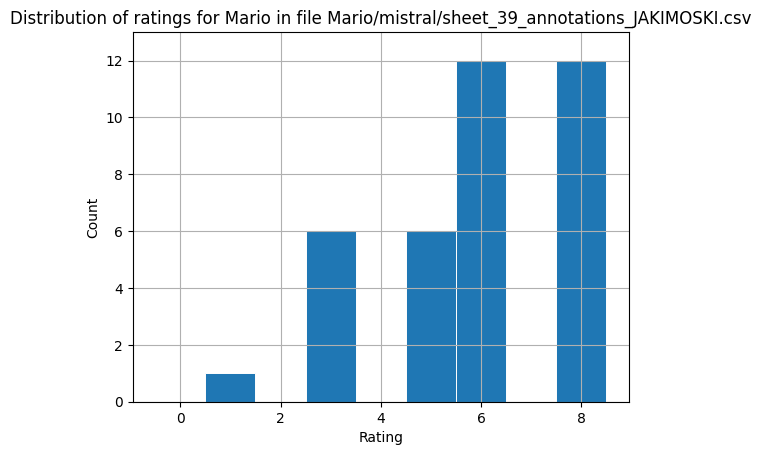

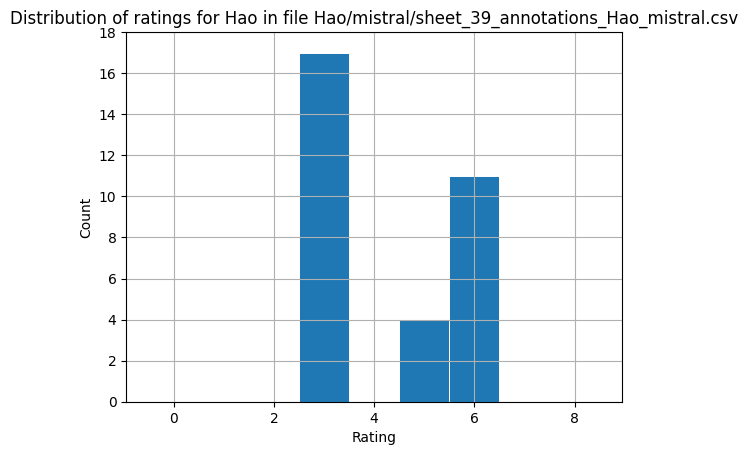

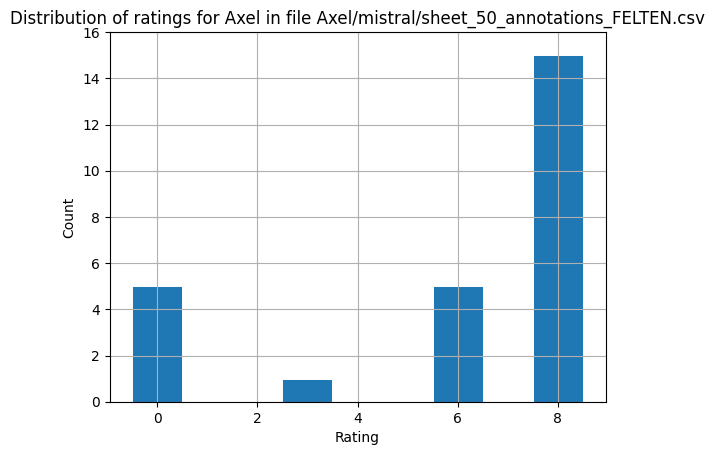

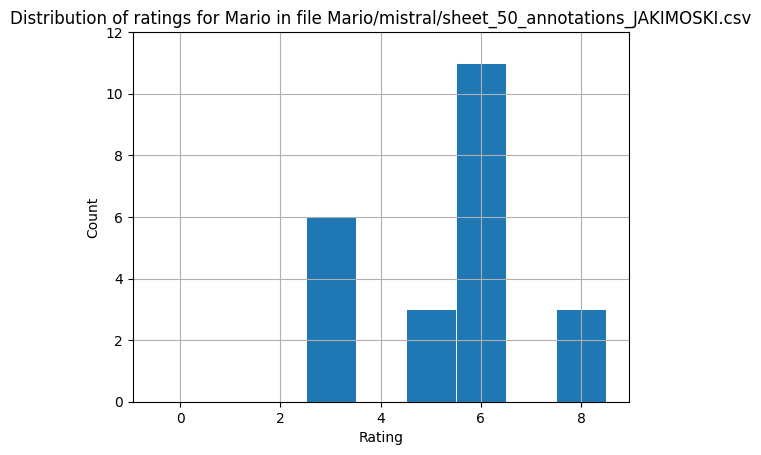

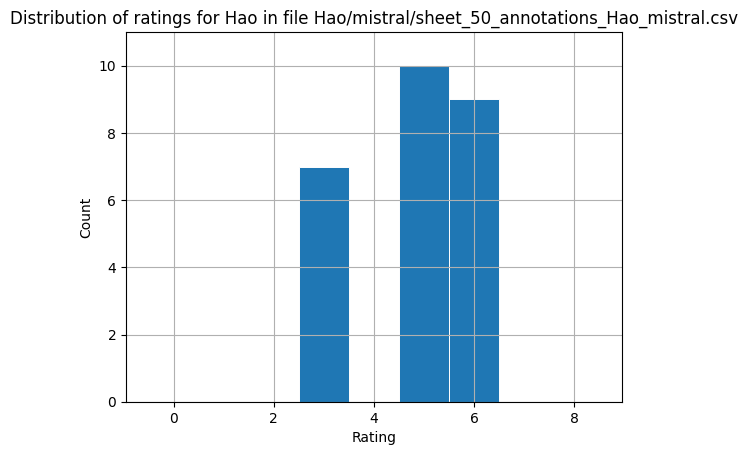

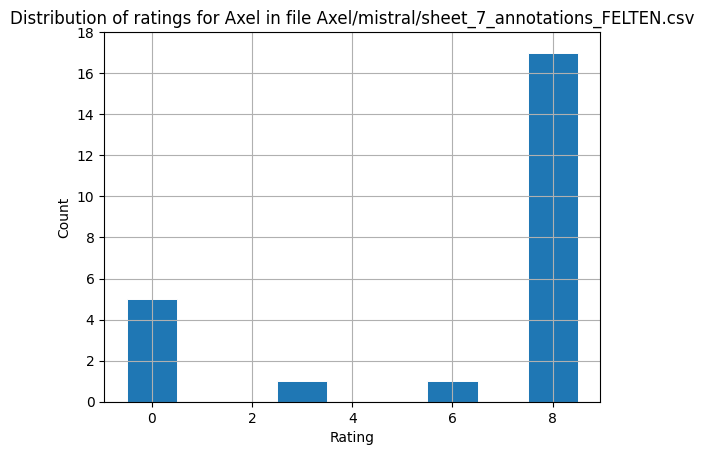

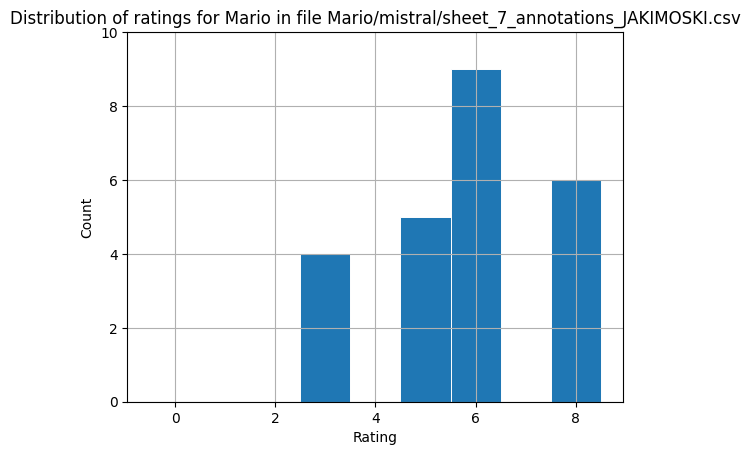

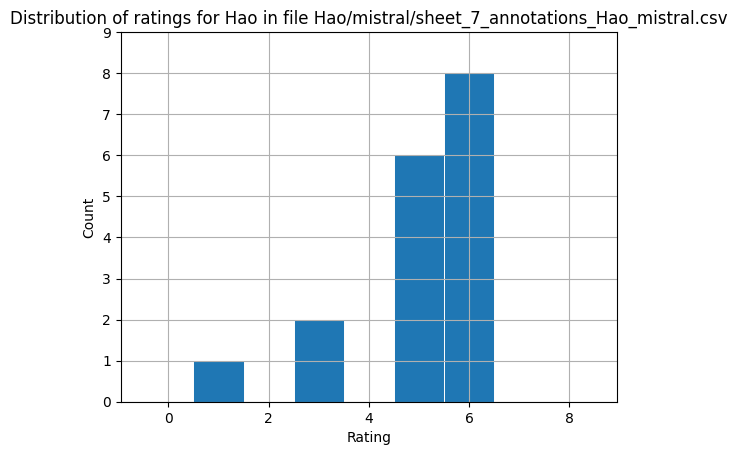

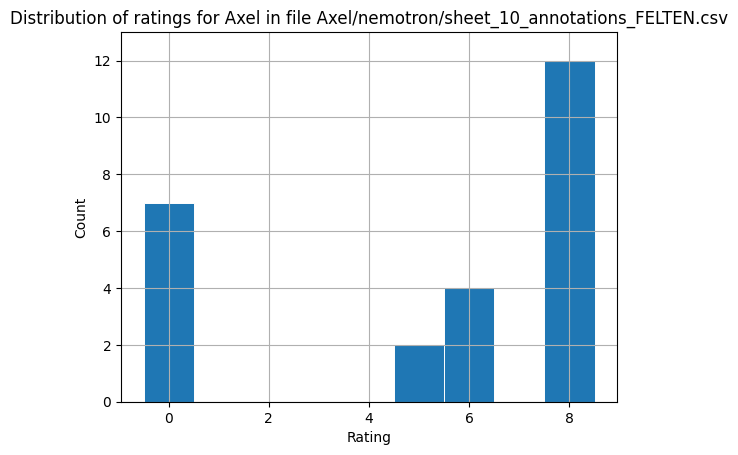

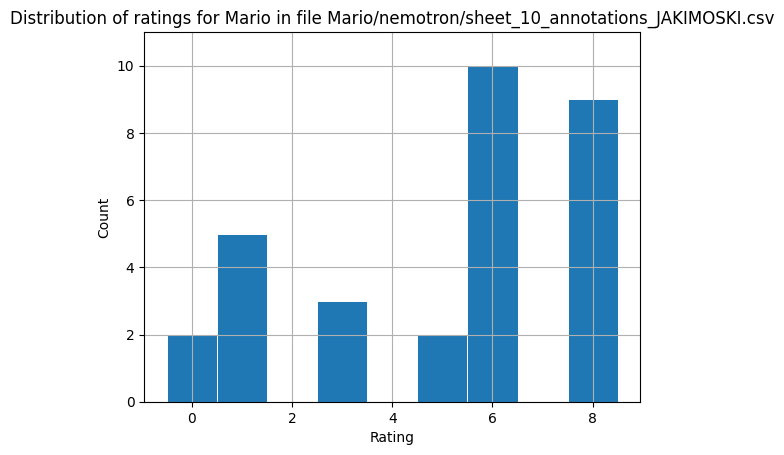

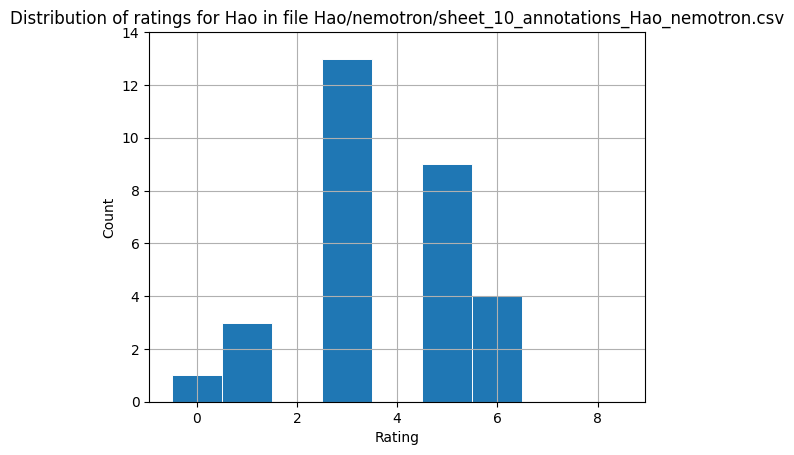

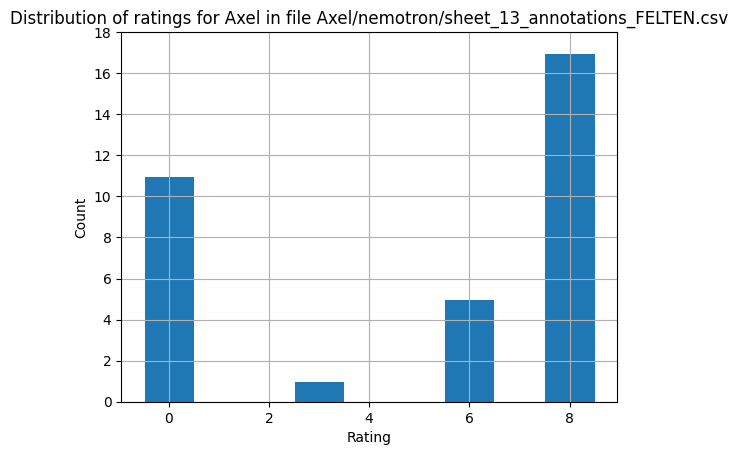

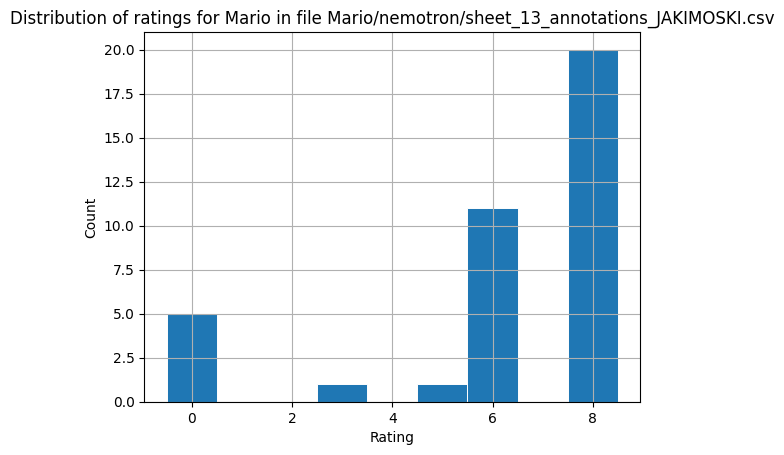

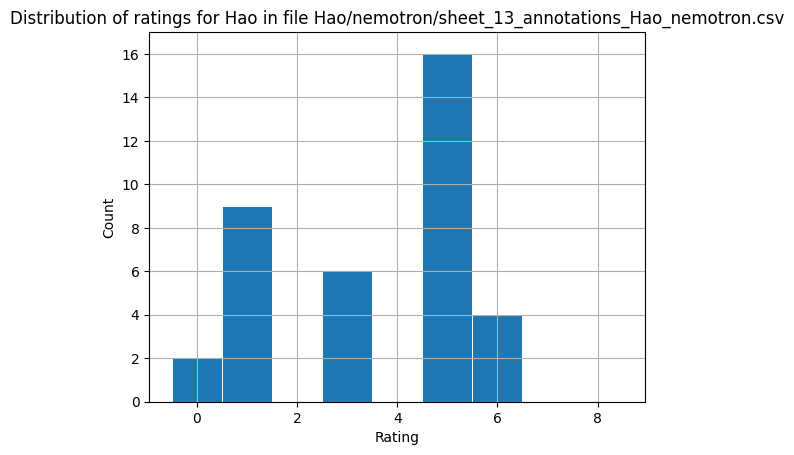

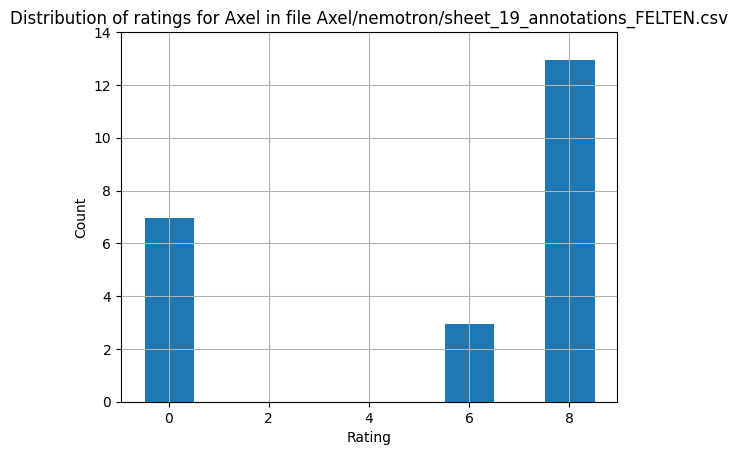

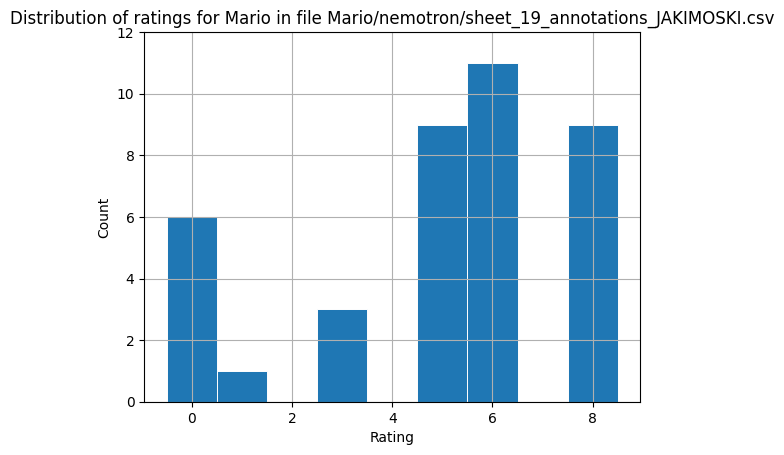

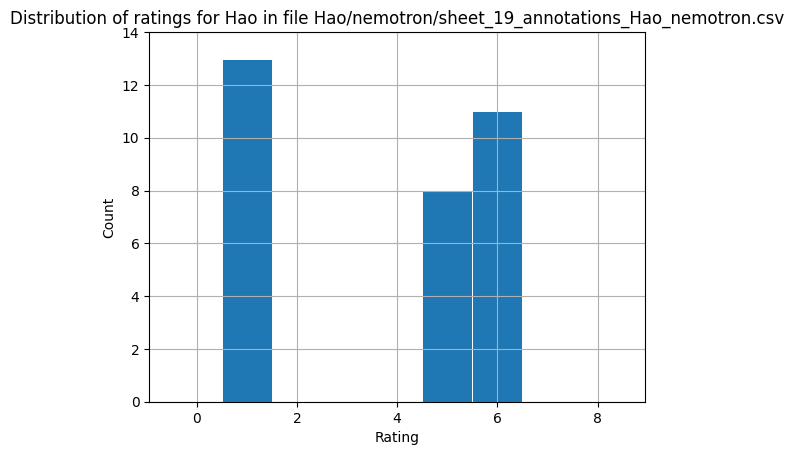

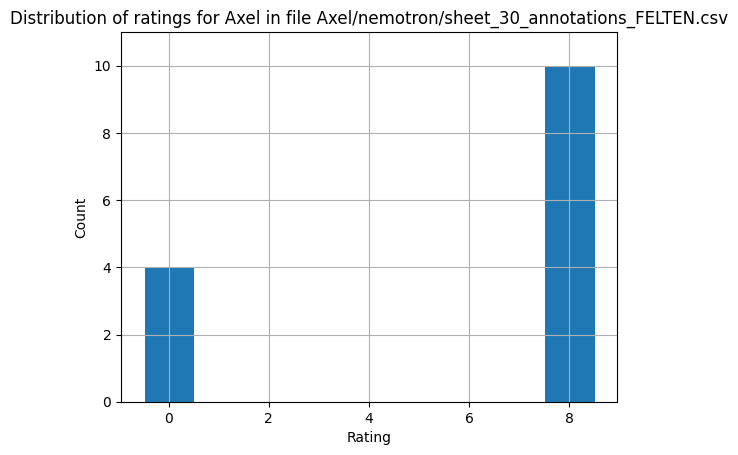

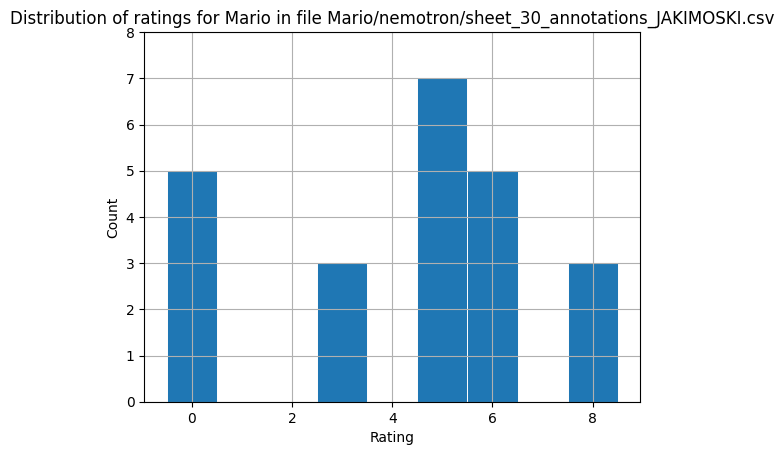

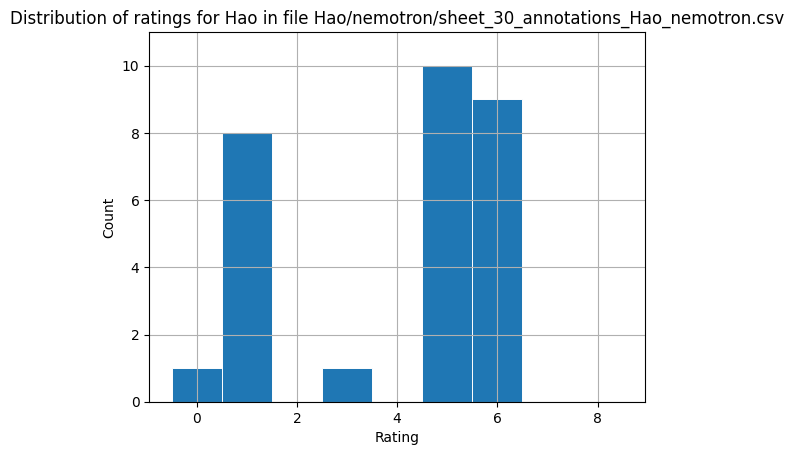

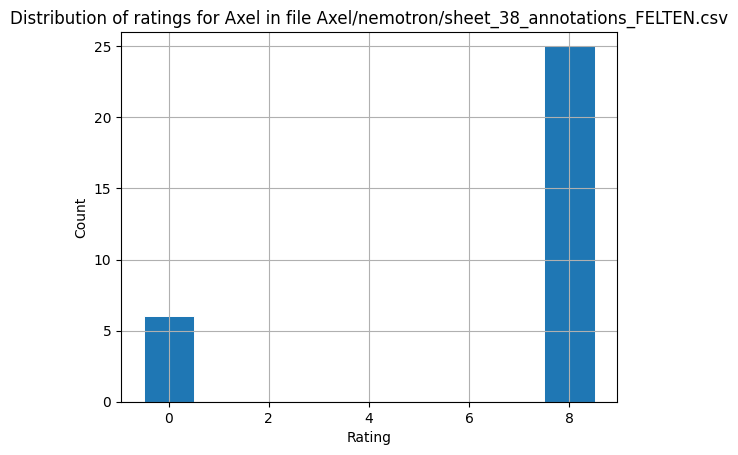

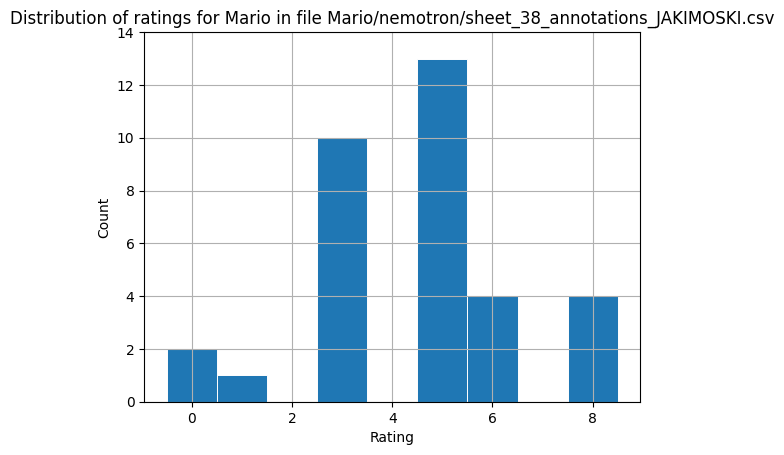

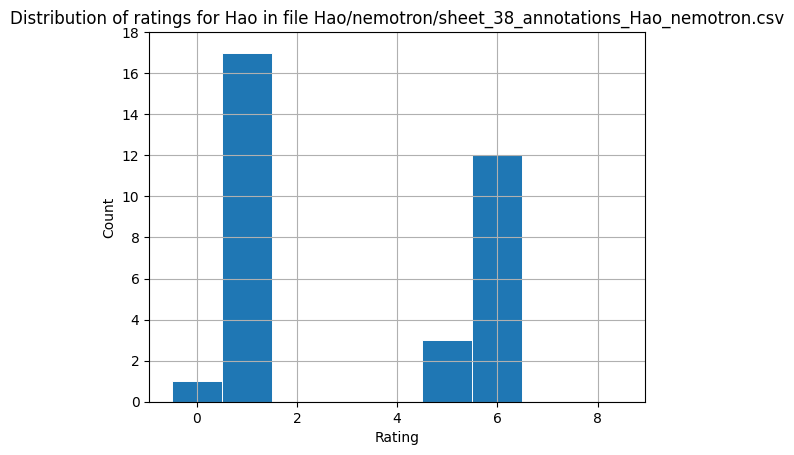

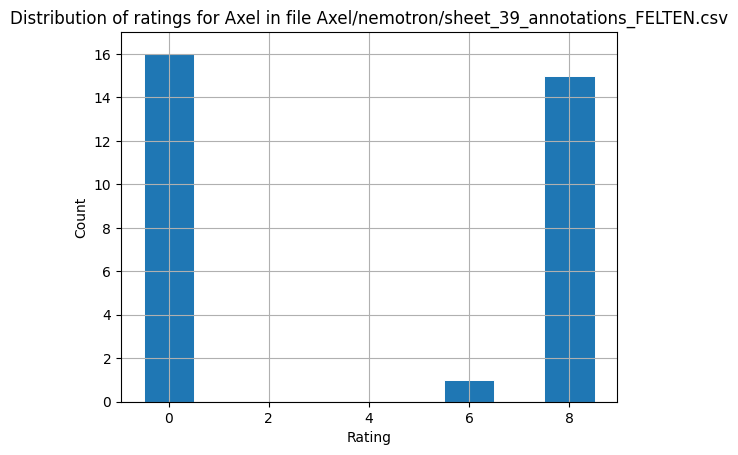

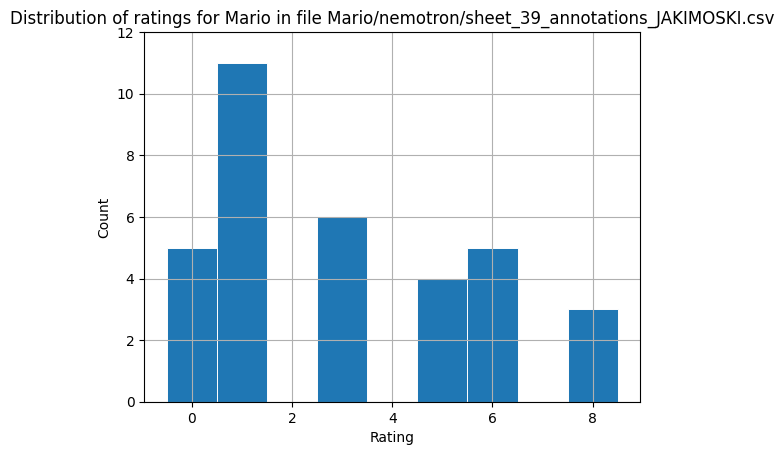

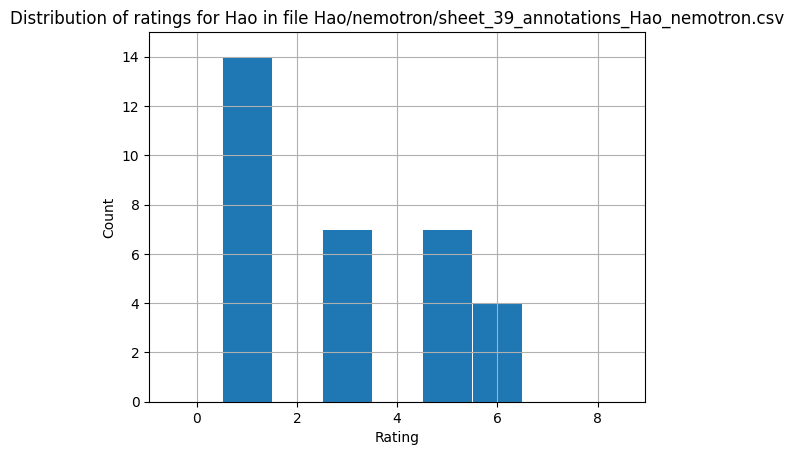

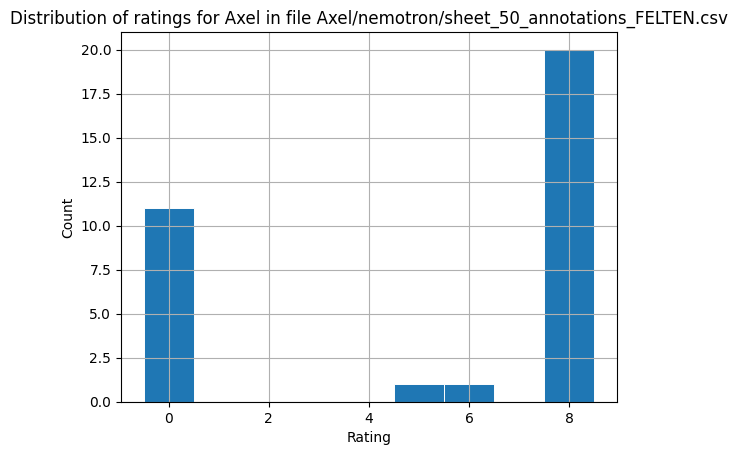

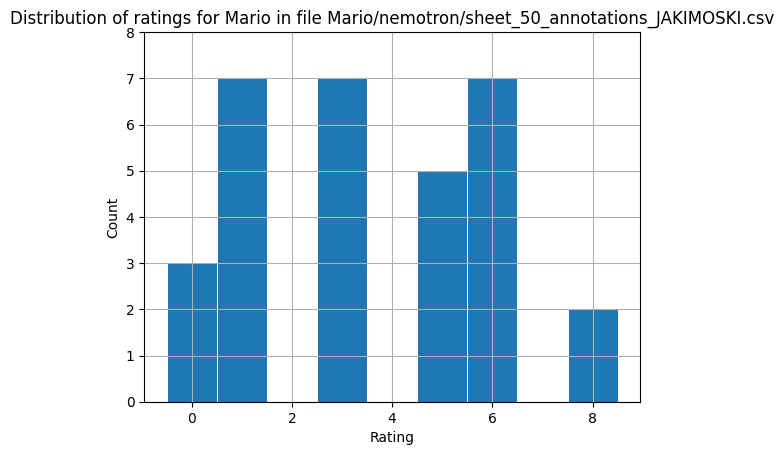

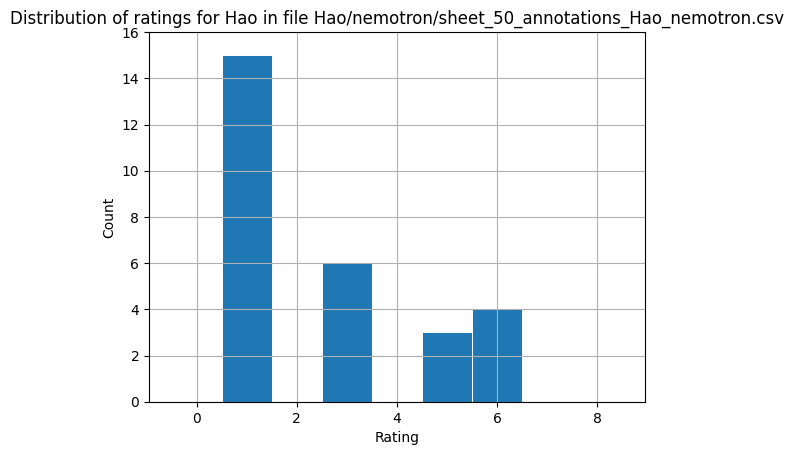

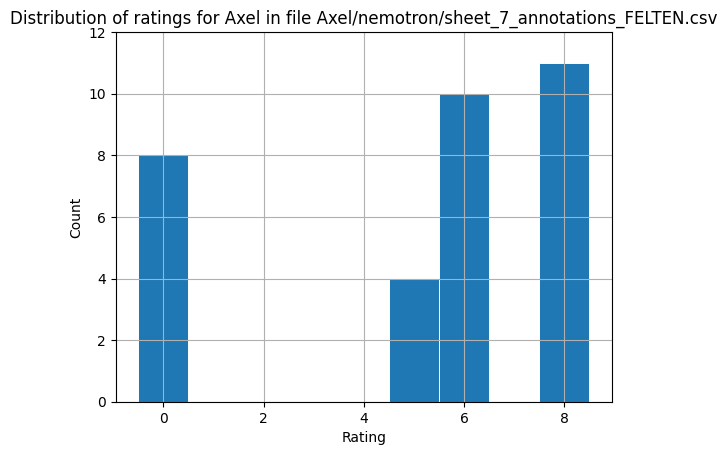

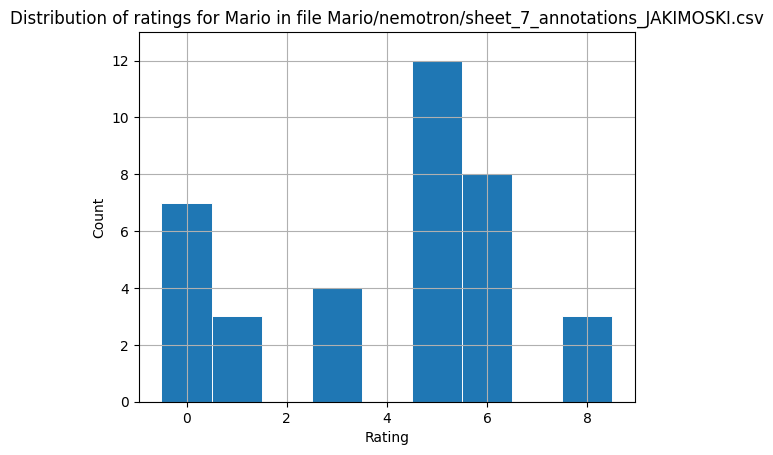

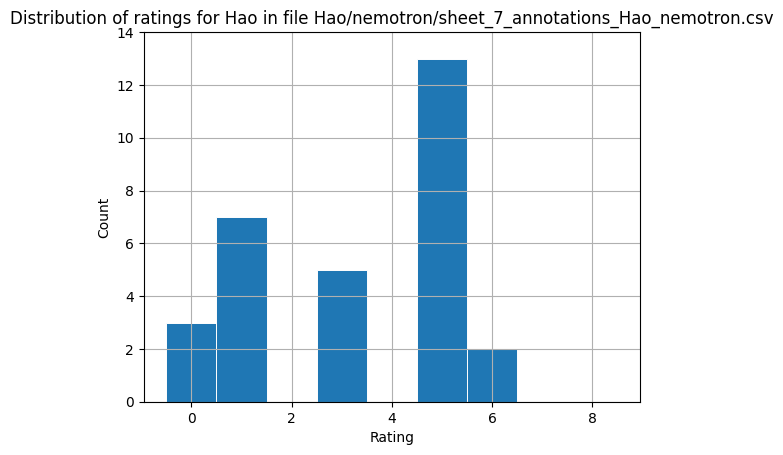

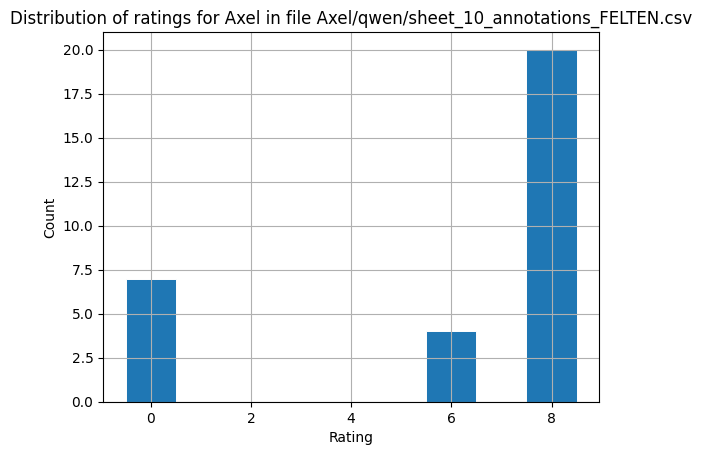

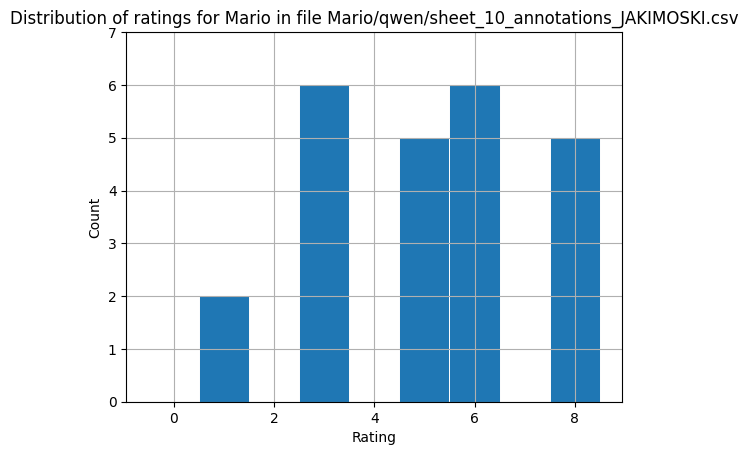

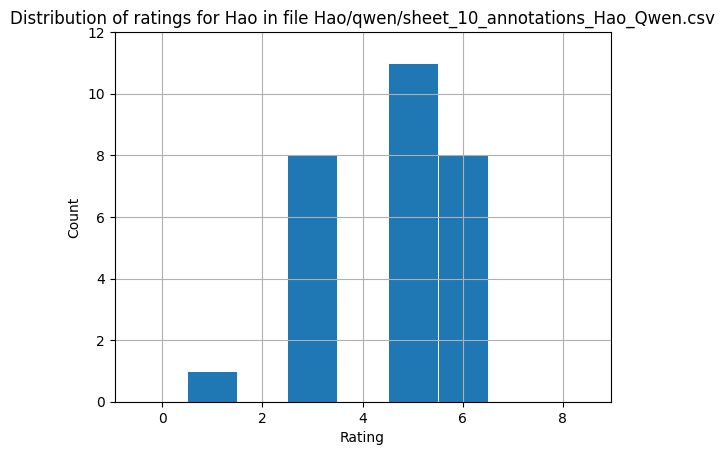

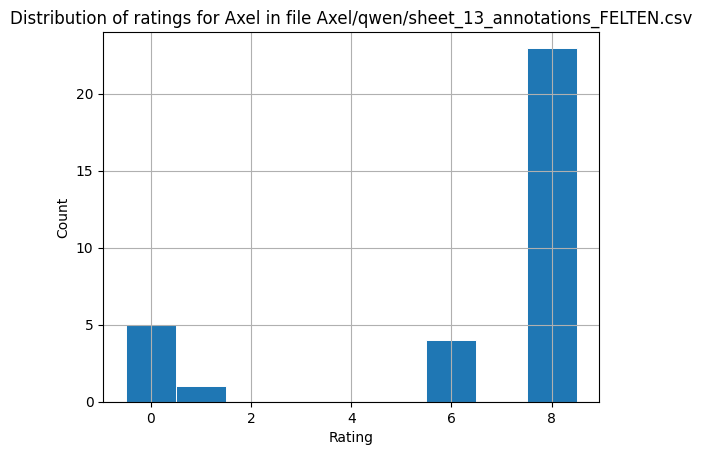

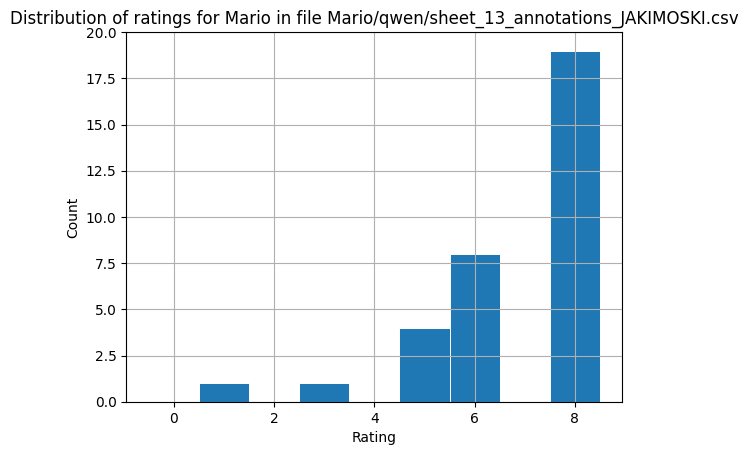

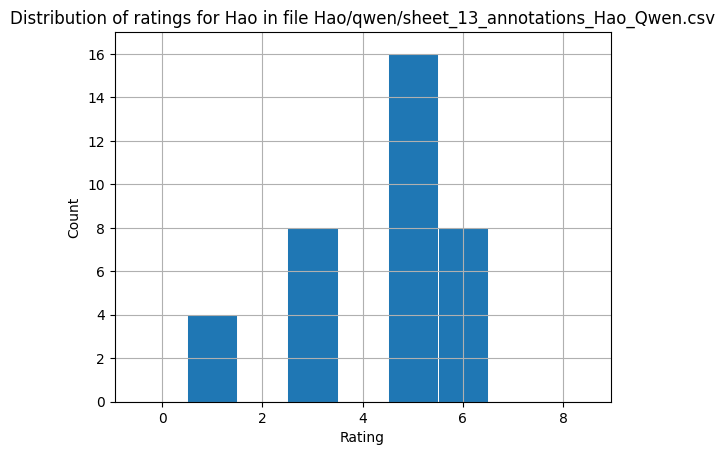

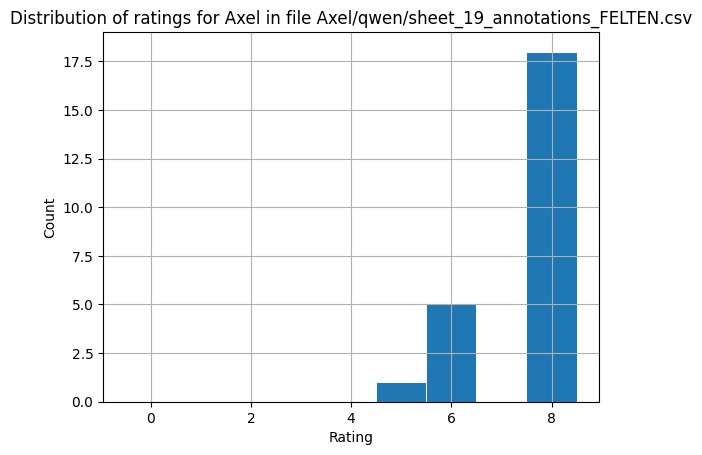

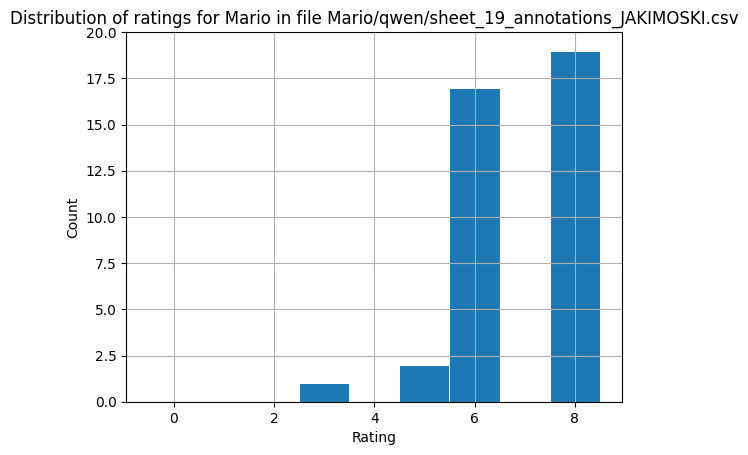

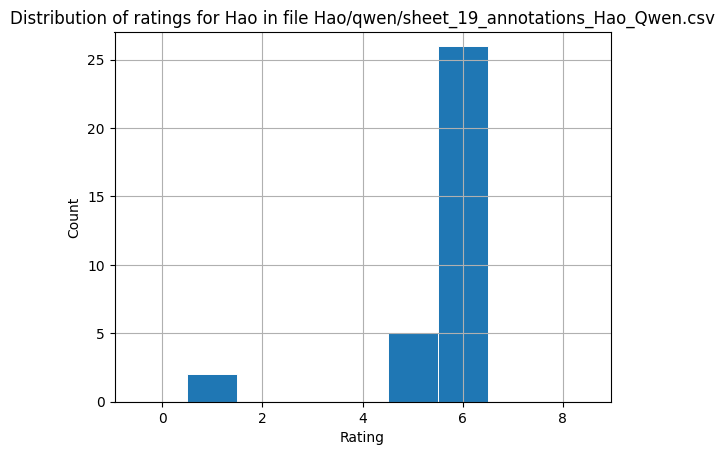

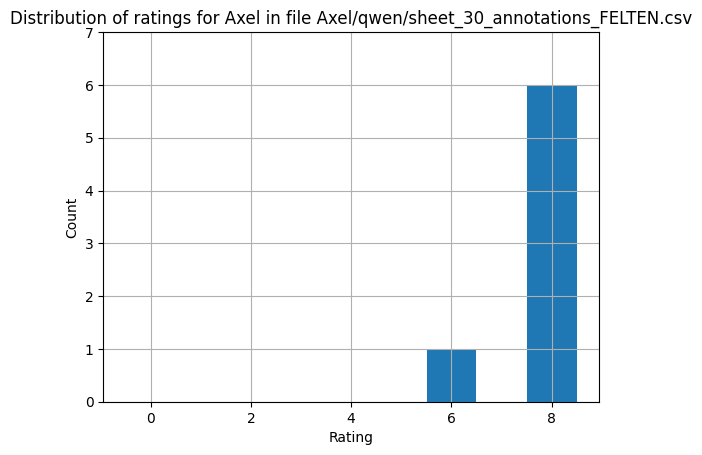

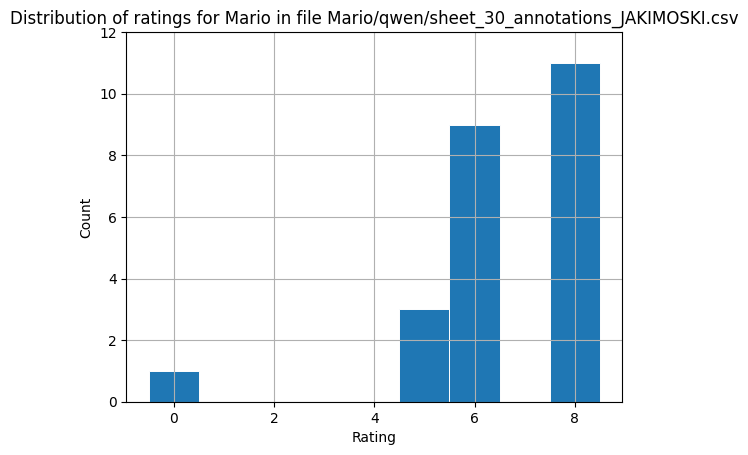

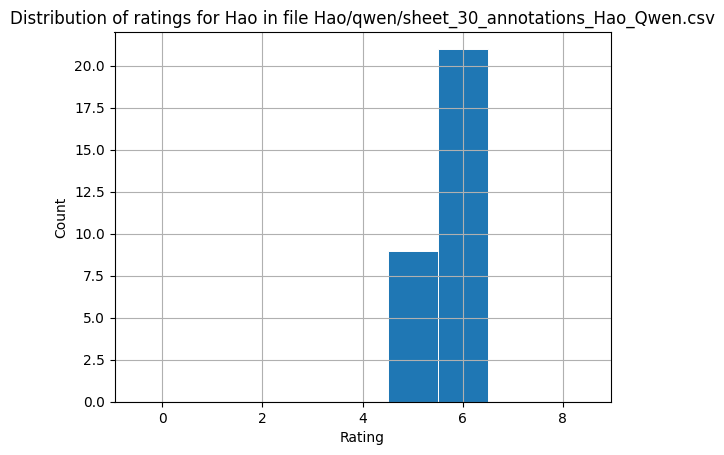

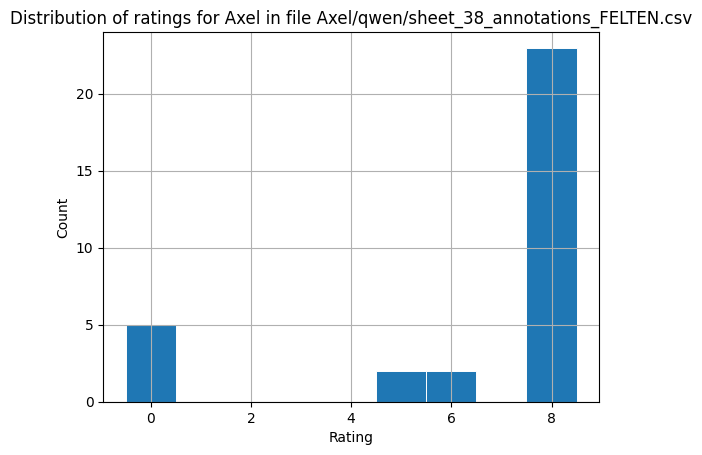

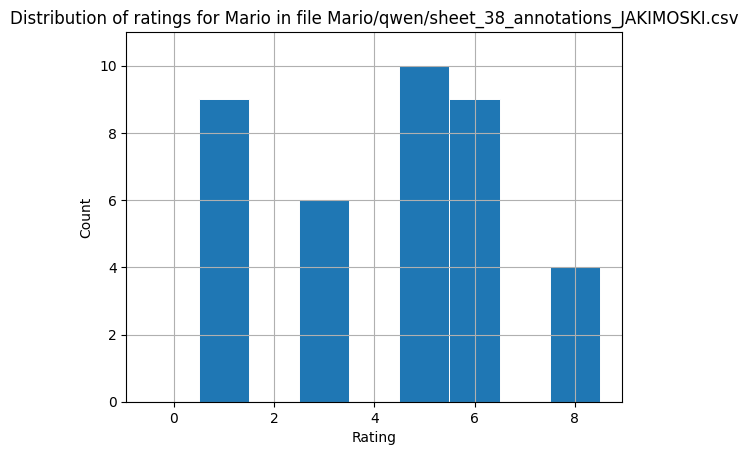

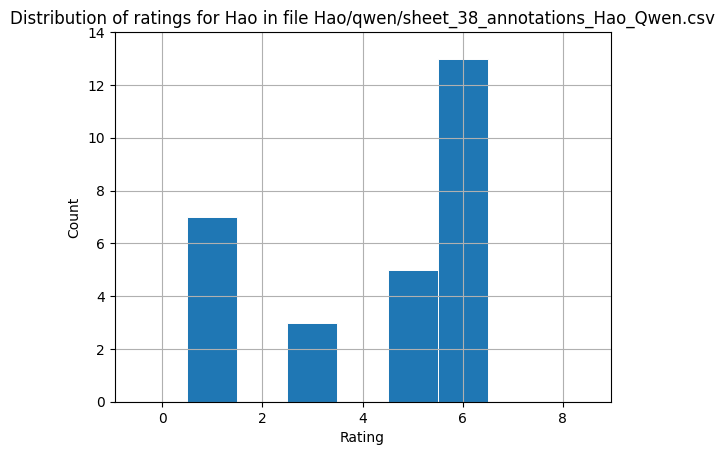

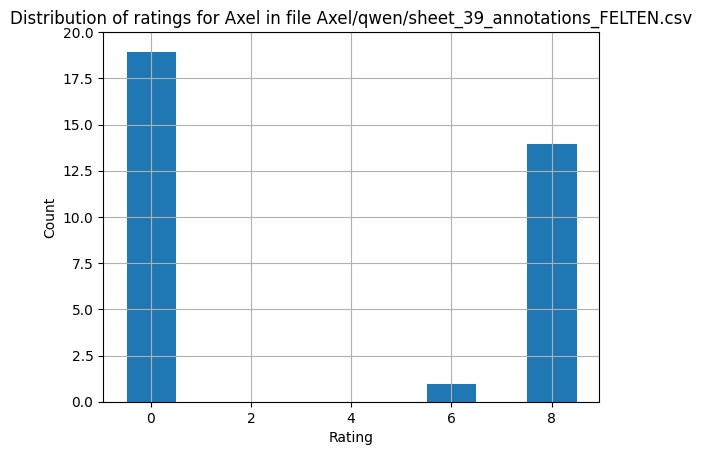

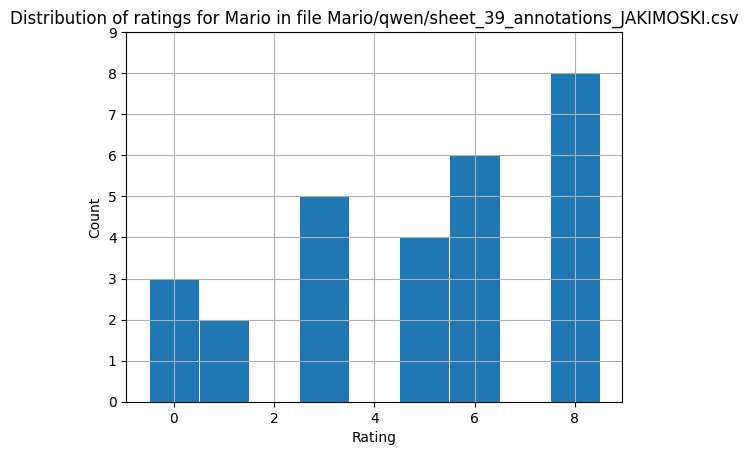

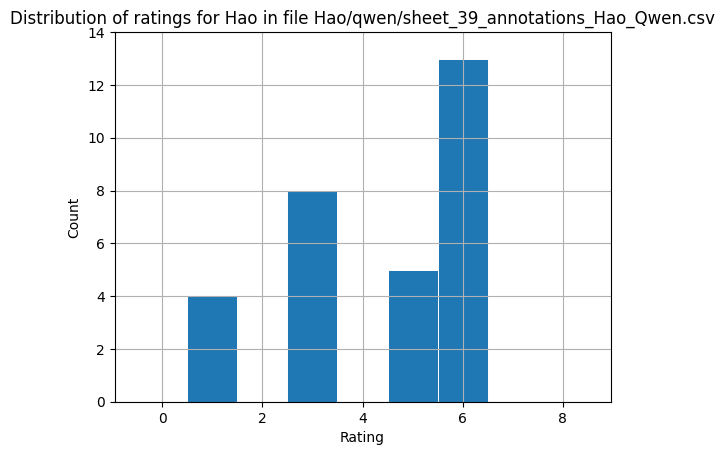

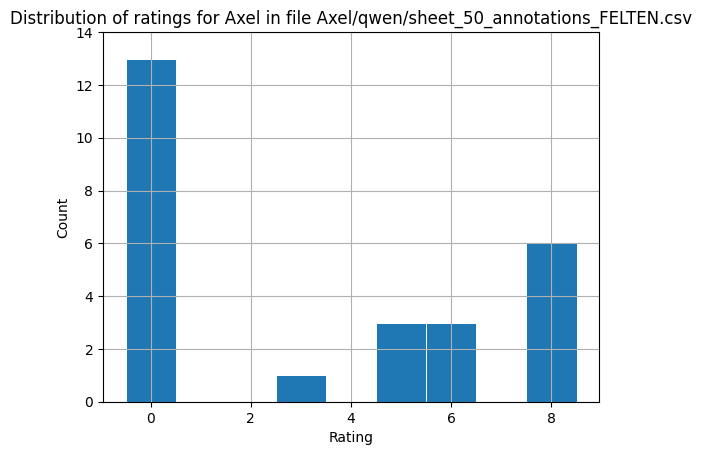

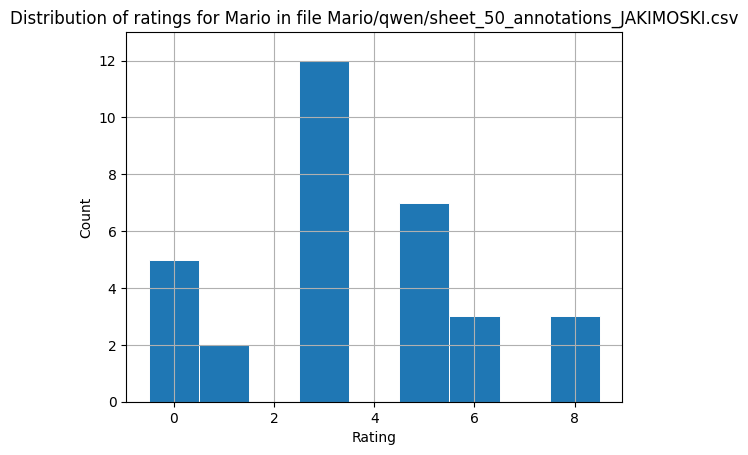

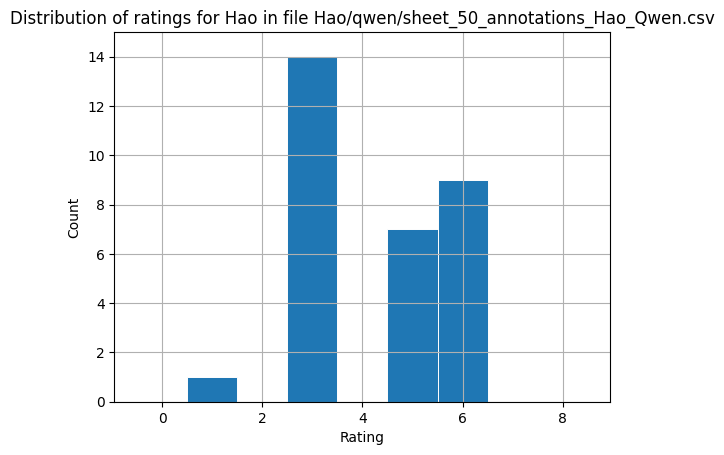

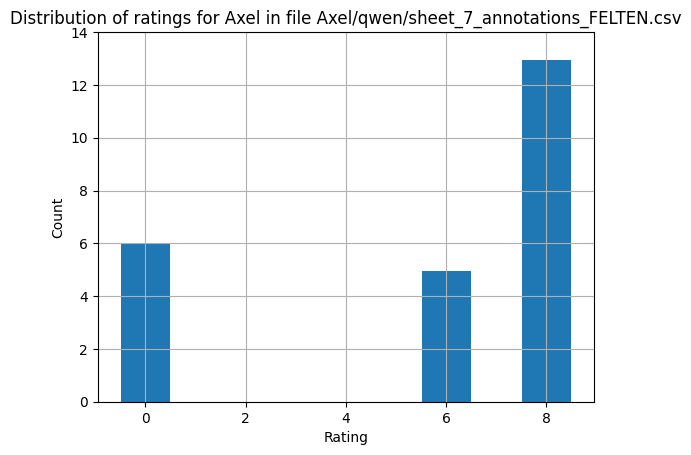

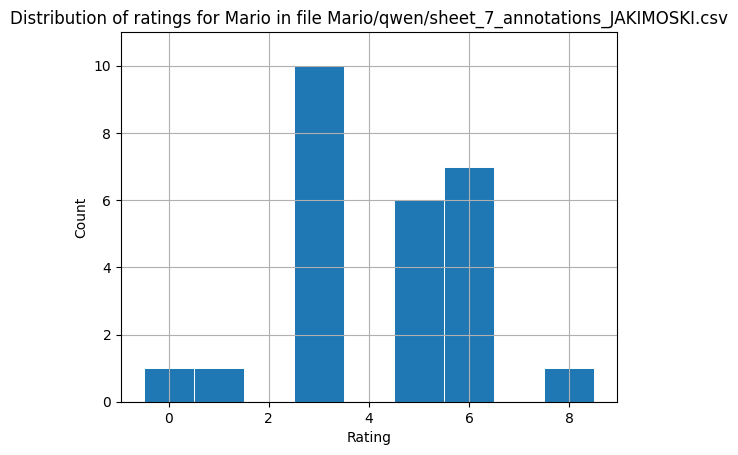

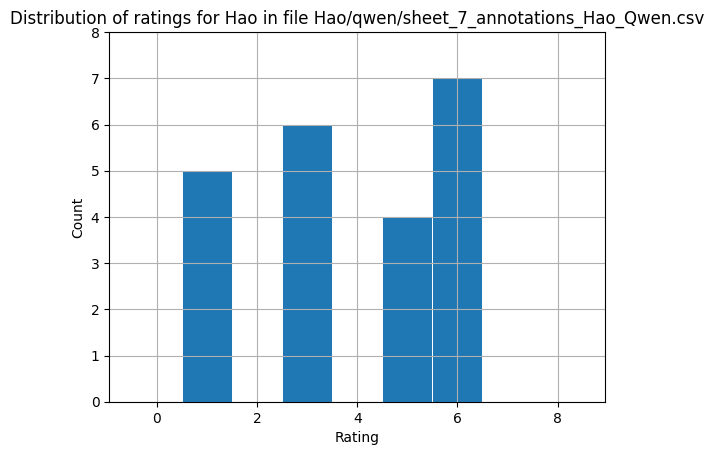

In [124]:
for file_a, file_m, file_h, in zip(file_path_axel, file_path_mario, file_path_hao):
    annotator_a, count_a = count_annotations(file_a, "Axel")
    del count_a[2]
    del count_a[4]
    del count_a[7]
    bar_plot_function(list(count_a.keys()), list(count_a.values()), "Rating", "Count", f"Distribution of ratings for {annotator_a} in file {file_a}")

    annotator_m, count_m = count_annotations(file_m, "Mario")
    del count_m[2]
    del count_m[4]
    del count_m[7]
    bar_plot_function(list(count_m.keys()), list(count_m.values()), "Rating", "Count", f"Distribution of ratings for {annotator_m} in file {file_m}")
    
    annotator_h, count_h = count_annotations(file_h, "Hao")
    del count_h[2]
    del count_h[4]
    del count_h[7]
    bar_plot_function(list(count_h.keys()), list(count_h.values()), "Rating", "Count", f"Distribution of ratings for {annotator_h} in file {file_h}")